In [ ]:
from google.colab import files
uploaded = files.upload()

Saving paddy_price_production.csv to paddy_price_production.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from joblib import Parallel, delayed
import warnings
import time
warnings.filterwarnings('ignore')

# ============ CONFIGURATION ============
MAX_EXECUTION_TIME = 300  # 5 minutes max per model type
MAX_ITERATIONS = 500  # Max parameter combinations to try
EARLY_STOPPING_PATIENCE = 50  # Stop if no improvement for N iterations
CONVERGENCE_THRESHOLD = 0.001  # Improvement must be > 0.1% to count

def smape(actual, forecast):
    denom = np.abs(actual) + np.abs(forecast)
    mask = denom == 0
    smape_val = 100 * np.mean(
        np.where(mask, 0, 2 * np.abs(forecast - actual) / denom)
    )
    return smape_val

def guarded_mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    safe = ~np.isclose(y_true, 0)
    if not np.any(safe):
        return np.nan
    return np.mean(np.abs((y_true[safe] - y_pred[safe]) / y_true[safe])) * 100

def evaluate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = guarded_mape(y_true, y_pred)
    sm = smape(y_true, y_pred)
    return rmse, mae, mape, sm

def weighted_cv_metrics(metrics_list, weight_recent=False):
    n = len(metrics_list)
    weights = np.ones(n)
    if weight_recent and n > 1:
        weights[-1] *= 2
    weights /= weights.sum()
    arr = np.array(metrics_list)
    mean = np.average(arr, axis=0, weights=weights)
    std = np.sqrt(np.average((arr - mean) ** 2, axis=0, weights=weights))
    return mean, std

def ts_crossval(model_func, y, exog, param_tup, splits, metric='rmse', weight_recent=False):
    metrics = []
    for train_idx, test_idx in splits:
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        exog_tr = exog.iloc[train_idx] if exog is not None else None
        exog_te = exog.iloc[test_idx] if exog is not None else None
        try:
            preds = model_func(y_train, exog_tr, param_tup, len(y_test), exog_te)
            rmse, mae, mape, sm = evaluate_metrics(y_test, preds)
            metrics.append((rmse, mae, mape, sm))
        except Exception as e:
            continue
    if not metrics:
        return np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf
    mean, std = weighted_cv_metrics(metrics, weight_recent=weight_recent)
    return (*mean, *std)

def make_splits(y, n_splits=3, test_size=12):
    n_total = len(y)
    split_points = np.linspace(n_total - test_size * n_splits, n_total - test_size, n_splits, dtype=int)
    splits = []
    for start in split_points:
        train_idx = np.arange(0, start)
        test_idx = np.arange(start, start + test_size)
        if len(train_idx) < 12 or (start + test_size) > n_total:
            continue
        splits.append((train_idx, test_idx))
    return splits

def model_arima(y_train, exog_tr, order, steps, exog_te):
    model = ARIMA(y_train, order=order)
    fit = model.fit()
    return fit.forecast(steps=steps)

def model_sarima(y_train, exog_tr, param_tup, steps, exog_te):
    order = param_tup[:3]
    seasonal = param_tup[3:] + (12,)
    model = SARIMAX(y_train, order=order, seasonal_order=seasonal)
    fit = model.fit(disp=False)
    return fit.forecast(steps=steps)

def model_sarimax(y_train, exog_tr, param_tup, steps, exog_te):
    order = param_tup[:3]
    seasonal = param_tup[3:] + (12,)
    model = SARIMAX(y_train, order=order, seasonal_order=seasonal, exog=exog_tr)
    fit = model.fit(disp=False)
    return fit.forecast(steps=steps, exog=exog_te)

# ============ SMART GRID SEARCH WITH EARLY STOPPING ============

def grid_search_with_timeout(model_func, series, exog, param_grid, splits,
                             model_name='Model', max_time=MAX_EXECUTION_TIME,
                             max_iters=MAX_ITERATIONS, patience=EARLY_STOPPING_PATIENCE,
                             threshold=CONVERGENCE_THRESHOLD, n_jobs=-1):
    """
    Grid search with:
    - Timeout (max execution time)
    - Max iterations limit
    - Early stopping (no improvement for N iterations)
    - Progress tracking
    """
    start_time = time.time()
    search_results = []
    best_rmse = np.inf
    patience_counter = 0
    iters_run = 0

    # Shuffle params to get better coverage of space quickly
    param_list = list(param_grid)
    np.random.shuffle(param_list)

    print(f"  Starting {model_name} grid search ({len(param_grid)} total params)...")

    def evaluate_param(param_tup):
        try:
            vals = ts_crossval(model_func, series, exog, param_tup, splits)
            return param_tup, *vals
        except Exception as e:
            return None

    for i, param in enumerate(param_list):
        # ===== TIMEOUT CHECK =====
        elapsed = time.time() - start_time
        if elapsed > max_time:
            print(f"  ⏱ TIMEOUT: {elapsed:.1f}s exceeded limit {max_time}s. Stopping search.")
            print(f"  Evaluated {iters_run}/{len(param_grid)} params.")
            break

        # ===== MAX ITERATIONS CHECK =====
        if iters_run >= max_iters:
            print(f"  ⛔ MAX ITERATIONS: Reached limit of {max_iters} params. Stopping search.")
            break

        # ===== EVALUATE PARAM =====
        res = evaluate_param(param)
        if res is None:
            continue

        param_tup, rmse, mae, mape, sm, rmse_std, mae_std, mape_std, sm_std = res
        search_results.append(res)
        iters_run += 1

        # ===== IMPROVEMENT CHECK & EARLY STOPPING =====
        improvement = (best_rmse - rmse) / (best_rmse + 1e-10)

        if rmse < best_rmse:
            best_rmse = rmse
            improvement_pct = improvement * 100
            print(f"    Iter {iters_run}: Param {param_tup} → RMSE={rmse:.2f} (↓ {improvement_pct:.2f}%)")
            patience_counter = 0  # Reset patience
        else:
            patience_counter += 1

        # ===== PATIENCE CHECK =====
        if patience_counter >= patience:
            print(f"  ⏸ EARLY STOPPING: No improvement for {patience} iterations.")
            print(f"  Best RMSE so far: {best_rmse:.2f}. Evaluated {iters_run} params.")
            break

    if not search_results:
        return None

    # Return best result
    best = sorted(
        search_results,
        key=lambda x: (x[1], x[2], x[4])  # rmse_mean, mae_mean, smape_mean
    )[0]

    elapsed_total = time.time() - start_time
    print(f"  ✓ {model_name} complete: {iters_run} params evaluated in {elapsed_total:.1f}s")
    return best

# ============ PARAM GRID GENERATION =============

def make_param_grid_arima(p_max=10, d_max=2, q_max=10):
    """Generate ARIMA parameter combinations (smartly limited)"""
    from itertools import product
    params = list(product(range(p_max+1), range(d_max+1), range(q_max+1)))
    # Prioritize lower values (more stable) and common patterns
    params_sorted = sorted(params, key=lambda x: x[0] + x[1] + x[2])
    return params_sorted

def make_param_grid_sarima(p_max=3, d_max=1, q_max=3, P_max=2, D_max=1, Q_max=2):
    """Generate SARIMA parameter combinations (smartly limited)"""
    from itertools import product
    params = list(product(range(p_max+1), range(d_max+1), range(q_max+1),
                          range(P_max+1), range(D_max+1), range(Q_max+1)))
    # Prioritize simpler models first
    params_sorted = sorted(params, key=lambda x: sum(x))
    return params_sorted

def make_param_grid_sarimax(p_max=2, d_max=1, q_max=2, P_max=1, D_max=1, Q_max=1):
    """Generate SARIMAX parameter combinations (more restricted)"""
    from itertools import product
    params = list(product(range(p_max+1), range(d_max+1), range(q_max+1),
                          range(P_max+1), range(D_max+1), range(Q_max+1)))
    params_sorted = sorted(params, key=lambda x: sum(x))
    return params_sorted

# ============ MAIN EXECUTION ============

df = pd.read_csv('/content/paddy_price_production.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%Y')
df = df.sort_values('Date').reset_index(drop=True)

states = df['State'].unique()
results = []

for state in states:
    state_df = df[df['State'] == state].copy()
    state_df.set_index('Date', inplace=True)
    price_series = state_df['Prices'].dropna()
    price_series.index.freq = 'MS'
    production_series = state_df['Production'].dropna()
    production_series.index.freq = 'MS' if len(production_series) > 0 else None

    print(f"\n{'='*80}")
    print(f"Searching best models for {state}")
    print(f"{'='*80}")

    if len(price_series) < 36:
        print(f"Skipping {state}: insufficient data")
        continue

    splits = make_splits(price_series, n_splits=3, test_size=12)

    # ARIMA: Large grid with early stopping
    param_grid_arima = make_param_grid_arima(p_max=10, d_max=2, q_max=10)
    best_arima = grid_search_with_timeout(
        model_arima, price_series, None, param_grid_arima, splits,
        model_name='ARIMA',
        max_time=300,  # 5 min
        max_iters=500,
        patience=50
    )

    # SARIMA: Medium grid with early stopping
    param_grid_sarima = make_param_grid_sarima(p_max=3, d_max=1, q_max=3, P_max=2, D_max=1, Q_max=2)
    best_sarima = grid_search_with_timeout(
        model_sarima, price_series, None, param_grid_sarima, splits,
        model_name='SARIMA',
        max_time=300,
        max_iters=500,
        patience=40
    )

    # SARIMAX: Smaller grid (slower per evaluation)
    best_sarimax = None
    if len(production_series) == len(price_series) and not production_series.isnull().any():
        param_grid_sarimax = make_param_grid_sarimax(p_max=2, d_max=1, q_max=2, P_max=1, D_max=1, Q_max=1)
        best_sarimax = grid_search_with_timeout(
            model_sarimax, price_series, production_series, param_grid_sarimax, splits,
            model_name='SARIMAX',
            max_time=180,  # 3 min (slower per eval)
            max_iters=200,
            patience=30
        )
    else:
        print("  SARIMAX: Skipped (no complete production data)")

    # Store results
    for name, best in zip(['ARIMA', 'SARIMA', 'SARIMAX'], [best_arima, best_sarima, best_sarimax]):
        if best is not None:
            params, rmse, mae, mape, sm, rmse_std, mae_std, mape_std, sm_std = best
            results.append({
                'State': state,
                'Model_Type': name,
                'Best_Params': params,
                'RMSE_mean': rmse,
                'RMSE_std': rmse_std,
                'MAE_mean': mae,
                'MAE_std': mae_std,
                'sMAPE_mean': sm,
                'sMAPE_std': sm_std
            })

results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("SUMMARY - Best ARIMA, SARIMA, and SARIMAX for each state:")
print("="*80)
with pd.option_context('display.precision', 3):
    print(results_df.to_string(index=False))



Searching best models for Punjab
  Starting ARIMA grid search (363 total params)...
    Iter 1: Param (1, 0, 7) → RMSE=640.35 (↓ nan%)
    Iter 3: Param (0, 1, 5) → RMSE=600.34 (↓ 6.25%)
    Iter 14: Param (4, 1, 6) → RMSE=592.00 (↓ 1.39%)
    Iter 40: Param (5, 2, 5) → RMSE=587.59 (↓ 0.75%)
    Iter 46: Param (5, 2, 10) → RMSE=566.07 (↓ 3.66%)
    Iter 83: Param (1, 2, 5) → RMSE=531.39 (↓ 6.13%)
  ⏱ TIMEOUT: 302.4s exceeded limit 300s. Stopping search.
  Evaluated 126/363 params.
  ✓ ARIMA complete: 126 params evaluated in 302.4s
  Starting SARIMA grid search (576 total params)...
    Iter 1: Param (2, 0, 1, 1, 0, 0) → RMSE=1016.31 (↓ nan%)
    Iter 2: Param (2, 0, 3, 2, 1, 0) → RMSE=631.38 (↓ 37.88%)
    Iter 3: Param (0, 0, 0, 1, 0, 0) → RMSE=627.74 (↓ 0.58%)
    Iter 8: Param (1, 1, 3, 0, 0, 0) → RMSE=619.72 (↓ 1.28%)
    Iter 9: Param (3, 1, 3, 1, 0, 2) → RMSE=571.46 (↓ 7.79%)
    Iter 14: Param (2, 1, 1, 1, 0, 1) → RMSE=546.33 (↓ 4.40%)
  ⏸ EARLY STOPPING: No improvement for 40 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from joblib import Parallel, delayed
import warnings
import time
import pickle
warnings.filterwarnings('ignore')

# ============ CONFIGURATION ============
MAX_EXECUTION_TIME = 500
MAX_ITERATIONS = 800
EARLY_STOPPING_PATIENCE = 80
CONVERGENCE_THRESHOLD = 0.001

BASELINE_PARAMS = {
    'Punjab': {
        'ARIMA': (5, 0, 10),
        'SARIMA': (2, 1, 1, 1, 0, 1),
        'SARIMAX': (0, 0, 1, 1, 0, 0)
    },
    'Utar Pradesh': {
        'ARIMA': (7, 2, 9),
        'SARIMA': (1, 1, 2, 0, 1, 0),
        'SARIMAX': None
    },
    'Delhi': {
        'ARIMA': (10, 2, 10),
        'SARIMA': (0, 1, 1, 1, 0, 1),
        'SARIMAX': (2, 1, 2, 1, 0, 0)
    },
    'West Bengal': {
        'ARIMA': (0, 0, 9),
        'SARIMA': (1, 0, 2, 2, 1, 1),
        'SARIMAX': (2, 0, 2, 1, 1, 0)
    },
    'Tamil Nadu': {
        'ARIMA': (10, 1, 0),
        'SARIMA': (3, 0, 3, 0, 1, 0),
        'SARIMAX': (1, 0, 1, 0, 1, 0)
    }
}

BASELINE_RMSE = {
    'Punjab': {'ARIMA': 535.247, 'SARIMA': 546.328, 'SARIMAX': 66.525},
    'Utar Pradesh': {'ARIMA': 89.740, 'SARIMA': 130.587},
    'Delhi': {'ARIMA': 36.051, 'SARIMA': 48.594, 'SARIMAX': 48.350},
    'West Bengal': {'ARIMA': 306.709, 'SARIMA': 332.613, 'SARIMAX': 330.131},
    'Tamil Nadu': {'ARIMA': 253.036, 'SARIMA': 238.961, 'SARIMAX': 253.718}
}

# ============ EVALUATION CACHE ============
class EvaluationCache:
    def __init__(self):
        self.cache = {}

    def get_key(self, state, model_type, param):
        return f"{state}_{model_type}_{param}"

    def add(self, state, model_type, param, result):
        key = self.get_key(state, model_type, param)
        self.cache[key] = result

    def get(self, state, model_type, param):
        key = self.get_key(state, model_type, param)
        return self.cache.get(key, None)

    def has_been_evaluated(self, state, model_type, param):
        key = self.get_key(state, model_type, param)
        return key in self.cache

    def save(self, filename='eval_cache.pkl'):
        with open(filename, 'wb') as f:
            pickle.dump(self.cache, f)

    def load(self, filename='eval_cache.pkl'):
        try:
            with open(filename, 'rb') as f:
                self.cache = pickle.load(f)
            print(f"✓ Loaded cache with {len(self.cache)} entries")
        except FileNotFoundError:
            print(f"  Cache file not found. Starting fresh.")

eval_cache = EvaluationCache()
eval_cache.load()  # Load previous evaluations

def smape(actual, forecast):
    denom = np.abs(actual) + np.abs(forecast)
    mask = denom == 0
    smape_val = 100 * np.mean(
        np.where(mask, 0, 2 * np.abs(forecast - actual) / denom)
    )
    return smape_val

def guarded_mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    safe = ~np.isclose(y_true, 0)
    if not np.any(safe):
        return np.nan
    return np.mean(np.abs((y_true[safe] - y_pred[safe]) / y_true[safe])) * 100

def evaluate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = guarded_mape(y_true, y_pred)
    sm = smape(y_true, y_pred)
    return rmse, mae, mape, sm

def weighted_cv_metrics(metrics_list, weight_recent=False):
    n = len(metrics_list)
    weights = np.ones(n)
    if weight_recent and n > 1:
        weights[-1] *= 2
    weights /= weights.sum()
    arr = np.array(metrics_list)
    mean = np.average(arr, axis=0, weights=weights)
    std = np.sqrt(np.average((arr - mean) ** 2, axis=0, weights=weights))
    return mean, std

def ts_crossval(model_func, y, exog, param_tup, splits):
    metrics = []
    for train_idx, test_idx in splits:
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        exog_tr = exog.iloc[train_idx] if exog is not None else None
        exog_te = exog.iloc[test_idx] if exog is not None else None
        try:
            preds = model_func(y_train, exog_tr, param_tup, len(y_test), exog_te)
            rmse, mae, mape, sm = evaluate_metrics(y_test, preds)
            metrics.append((rmse, mae, mape, sm))
        except Exception as e:
            continue
    if not metrics:
        return np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf
    mean, std = weighted_cv_metrics(metrics, weight_recent=False)
    return (*mean, *std)

def make_splits(y, n_splits=3, test_size=12):
    n_total = len(y)
    split_points = np.linspace(n_total - test_size * n_splits, n_total - test_size, n_splits, dtype=int)
    splits = []
    for start in split_points:
        train_idx = np.arange(0, start)
        test_idx = np.arange(start, start + test_size)
        if len(train_idx) < 12 or (start + test_size) > n_total:
            continue
        splits.append((train_idx, test_idx))
    return splits

def model_arima(y_train, exog_tr, order, steps, exog_te):
    model = ARIMA(y_train, order=order)
    fit = model.fit()
    return fit.forecast(steps=steps)

def model_sarima(y_train, exog_tr, param_tup, steps, exog_te):
    order = param_tup[:3]
    seasonal = param_tup[3:] + (12,)
    model = SARIMAX(y_train, order=order, seasonal_order=seasonal)
    fit = model.fit(disp=False)
    return fit.forecast(steps=steps)

def model_sarimax(y_train, exog_tr, param_tup, steps, exog_te):
    order = param_tup[:3]
    seasonal = param_tup[3:] + (12,)
    model = SARIMAX(y_train, order=order, seasonal_order=seasonal, exog=exog_tr)
    fit = model.fit(disp=False)
    return fit.forecast(steps=steps, exog=exog_te)

# ============ SMART PARAM FILTERING ============

def generate_param_neighbors(baseline_param, max_offset=2):
    """Generate parameter combinations around baseline"""
    neighbors = []
    if len(baseline_param) == 3:  # ARIMA
        p, d, q = baseline_param
        for dp in range(-max_offset, max_offset+1):
            for dq in range(-max_offset, max_offset+1):
                if p + dp >= 0 and q + dq >= 0:
                    neighbors.append((p + dp, d, q + dq))
    elif len(baseline_param) == 6:  # SARIMA/SARIMAX
        p, d, q, P, D, Q = baseline_param
        for dp in range(-max_offset, max_offset+1):
            for dq in range(-max_offset, max_offset+1):
                for dP in range(-1, 2):
                    for dQ in range(-1, 2):
                        if p + dp >= 0 and q + dq >= 0 and P + dP >= 0 and Q + dQ >= 0:
                            neighbors.append((p + dp, d, q + dq, P + dP, D, Q + dQ))
    return list(set(neighbors))

def filter_unevaluated_params(param_grid, state, model_type, baseline_rmse):
    """
    Filter params to only include:
    1. Not yet evaluated
    2. Promising (close to baseline in param space)
    3. Exclude params clearly worse than baseline (heuristic: high p+d+q values)
    """
    filtered = []
    for param in param_grid:
        # Skip if already evaluated
        if eval_cache.has_been_evaluated(state, model_type, param):
            continue

        # Skip if sum of params is too high (heuristic: complex models)
        param_complexity = sum(param)
        baseline_complexity = sum(BASELINE_PARAMS[state].get(model_type, (0,0,0)))

        # Allow params up to baseline complexity + 3
        if param_complexity > baseline_complexity + 5:
            continue

        filtered.append(param)

    return filtered

# ============ GRID SEARCH WITH CACHING ============

def grid_search_with_cache(model_func, series, exog, param_grid, splits,
                           state='', model_name='Model', baseline_rmse=np.inf,
                           max_time=500, max_iters=800, patience=80):
    start_time = time.time()
    search_results = []
    best_rmse = baseline_rmse
    best_param_found = None
    patience_counter = 0
    iters_run = 0
    visited_count = 0
    skipped_count = 0

    param_list = list(param_grid)
    np.random.shuffle(param_list)

    print(f"  Starting {model_name} grid search...")
    print(f"    Total params to explore: {len(param_list)}")
    print(f"    Baseline RMSE: {baseline_rmse:.2f}")

    for i, param in enumerate(param_list):
        elapsed = time.time() - start_time

        # ===== TIMEOUT CHECK =====
        if elapsed > max_time:
            print(f"  ⏱ TIMEOUT: {elapsed:.1f}s exceeded. Stopping.")
            print(f"    Evaluated: {iters_run} | Visited (cached): {visited_count} | Skipped: {skipped_count}")
            break

        # ===== MAX ITERATIONS CHECK =====
        if iters_run >= max_iters:
            print(f"  ⛔ MAX ITERATIONS: Reached {max_iters} evals. Stopping.")
            break

        # ===== CHECK CACHE =====
        cached_result = eval_cache.get(state, model_name, param)
        if cached_result is not None:
            visited_count += 1
            rmse, mae, mape, sm, rmse_std, mae_std, mape_std, sm_std = cached_result
            search_results.append((param, rmse, mae, mape, sm, rmse_std, mae_std, mape_std, sm_std))

            # Update best if better
            if rmse < best_rmse:
                best_rmse = rmse
                best_param_found = param
                improvement_pct = (baseline_rmse - rmse) / baseline_rmse * 100
                print(f"    Cached Iter {iters_run+1}: Param {param} → RMSE={rmse:.2f} ({improvement_pct:+.2f}% vs baseline) [FROM CACHE]")
                patience_counter = 0
            else:
                patience_counter += 1

            iters_run += 1
            continue

        # ===== NEW EVALUATION =====
        try:
            vals = ts_crossval(model_func, series, exog, param, splits)
            if vals[0] == np.inf:
                skipped_count += 1
                continue

            rmse, mae, mape, sm, rmse_std, mae_std, mape_std, sm_std = vals
            search_results.append((param, rmse, mae, mape, sm, rmse_std, mae_std, mape_std, sm_std))

            # Store in cache
            eval_cache.add(state, model_name, param, vals)
            iters_run += 1

            improvement = (best_rmse - rmse) / (best_rmse + 1e-10)

            if rmse < best_rmse:
                best_rmse = rmse
                best_param_found = param
                improvement_pct = (baseline_rmse - rmse) / baseline_rmse * 100
                vs_prev_pct = improvement * 100
                print(f"    Iter {iters_run}: Param {param} → RMSE={rmse:.2f} ({improvement_pct:+.2f}% vs baseline | ↓{vs_prev_pct:.2f}% vs prev)")
                patience_counter = 0
            else:
                patience_counter += 1

        except Exception as e:
            skipped_count += 1
            continue

        # ===== PATIENCE CHECK =====
        if patience_counter >= patience:
            print(f"  ⏸ EARLY STOPPING: No improvement for {patience} iterations.")
            print(f"    Best RMSE: {best_rmse:.2f}. Evaluated: {iters_run} | Visited (cached): {visited_count} | Skipped: {skipped_count}")
            break

    if not search_results:
        return None

    best = sorted(search_results, key=lambda x: (x[1], x[2], x[4]))[0]
    elapsed_total = time.time() - start_time
    final_improvement = (baseline_rmse - best[1]) / baseline_rmse * 100
    print(f"  ✓ {model_name} complete: {elapsed_total:.1f}s | Final RMSE: {best[1]:.2f} ({final_improvement:+.2f}% vs baseline) | Evals: {iters_run} | Cached: {visited_count}")
    return best

def make_full_param_grid(p_max, d_max, q_max, P_max=None, D_max=None, Q_max=None):
    from itertools import product
    if P_max is None:  # ARIMA
        params = list(product(range(p_max+1), range(d_max+1), range(q_max+1)))
    else:  # SARIMA
        params = list(product(range(p_max+1), range(d_max+1), range(q_max+1),
                              range(P_max+1), range(D_max+1), range(Q_max+1)))
    params_sorted = sorted(params, key=lambda x: sum(x))
    return params_sorted

# ============ MAIN EXECUTION ============

df = pd.read_csv('/content/paddy_price_production.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%Y')
df = df.sort_values('Date').reset_index(drop=True)

states = df['State'].unique()
results = []

for state in states:
    state_df = df[df['State'] == state].copy()
    state_df.set_index('Date', inplace=True)
    price_series = state_df['Prices'].dropna()
    price_series.index.freq = 'MS'
    production_series = state_df['Production'].dropna()
    production_series.index.freq = 'MS' if len(production_series) > 0 else None

    print(f"\n{'='*100}")
    print(f"Refining models for {state} (with cache-aware exploration)")
    print(f"{'='*100}")

    if len(price_series) < 36:
        print(f"Skipping {state}: insufficient data")
        continue

    splits = make_splits(price_series, n_splits=3, test_size=12)
    baseline = BASELINE_PARAMS.get(state, {})
    baseline_rmse_dict = BASELINE_RMSE.get(state, {})

    # ===== ARIMA =====
    print(f"\n  ARIMA MODEL:")
    arima_baseline_param = baseline.get('ARIMA')
    arima_baseline_rmse = baseline_rmse_dict.get('ARIMA', np.inf)

    param_grid_arima = make_full_param_grid(p_max=12, d_max=2, q_max=12)
    if arima_baseline_param:
        neighbors_arima = generate_param_neighbors(arima_baseline_param, max_offset=3)
        param_grid_arima = list(set(param_grid_arima) | set(neighbors_arima))

    # Filter to only unevaluated params
    param_grid_arima_filtered = filter_unevaluated_params(param_grid_arima, state, 'ARIMA', arima_baseline_rmse)
    print(f"    Total params in grid: {len(param_grid_arima)} | Unevaluated: {len(param_grid_arima_filtered)}")

    if len(param_grid_arima_filtered) > 0:
        best_arima = grid_search_with_cache(
            model_arima, price_series, None, param_grid_arima_filtered, splits,
            state=state, model_name='ARIMA', baseline_rmse=arima_baseline_rmse,
            max_time=500, max_iters=800, patience=80
        )
    else:
        print(f"    No unevaluated params. Skipping.")
        best_arima = None

    # ===== SARIMA =====
    print(f"\n  SARIMA MODEL:")
    sarima_baseline_param = baseline.get('SARIMA')
    sarima_baseline_rmse = baseline_rmse_dict.get('SARIMA', np.inf)

    param_grid_sarima = make_full_param_grid(p_max=4, d_max=1, q_max=4, P_max=2, D_max=1, Q_max=2)
    if sarima_baseline_param:
        neighbors_sarima = generate_param_neighbors(sarima_baseline_param, max_offset=2)
        param_grid_sarima = list(set(param_grid_sarima) | set(neighbors_sarima))

    param_grid_sarima_filtered = filter_unevaluated_params(param_grid_sarima, state, 'SARIMA', sarima_baseline_rmse)
    print(f"    Total params in grid: {len(param_grid_sarima)} | Unevaluated: {len(param_grid_sarima_filtered)}")

    if len(param_grid_sarima_filtered) > 0:
        best_sarima = grid_search_with_cache(
            model_sarima, price_series, None, param_grid_sarima_filtered, splits,
            state=state, model_name='SARIMA', baseline_rmse=sarima_baseline_rmse,
            max_time=500, max_iters=800, patience=80
        )
    else:
        print(f"    No unevaluated params. Skipping.")
        best_sarima = None

    # ===== SARIMAX =====
    best_sarimax = None
    if len(production_series) == len(price_series) and not production_series.isnull().any():
        print(f"\n  SARIMAX MODEL:")
        sarimax_baseline_param = baseline.get('SARIMAX')
        sarimax_baseline_rmse = baseline_rmse_dict.get('SARIMAX', np.inf)

        param_grid_sarimax = make_full_param_grid(p_max=3, d_max=1, q_max=3, P_max=1, D_max=1, Q_max=1)
        if sarimax_baseline_param:
            neighbors_sarimax = generate_param_neighbors(sarimax_baseline_param, max_offset=2)
            param_grid_sarimax = list(set(param_grid_sarimax) | set(neighbors_sarimax))

        param_grid_sarimax_filtered = filter_unevaluated_params(param_grid_sarimax, state, 'SARIMAX', sarimax_baseline_rmse)
        print(f"    Total params in grid: {len(param_grid_sarimax)} | Unevaluated: {len(param_grid_sarimax_filtered)}")

        if len(param_grid_sarimax_filtered) > 0:
            best_sarimax = grid_search_with_cache(
                model_sarimax, price_series, production_series, param_grid_sarimax_filtered, splits,
                state=state, model_name='SARIMAX', baseline_rmse=sarimax_baseline_rmse,
                max_time=400, max_iters=600, patience=60
            )
        else:
            print(f"    No unevaluated params. Skipping.")
    else:
        print(f"  SARIMAX: Skipped (no production data)")

    # Store results
    for name, best in zip(['ARIMA', 'SARIMA', 'SARIMAX'], [best_arima, best_sarima, best_sarimax]):
        if best is not None:
            params, rmse, mae, mape, sm, rmse_std, mae_std, mape_std, sm_std = best
            baseline_rmse = baseline_rmse_dict.get(name, np.inf)
            improvement = (baseline_rmse - rmse) / baseline_rmse * 100 if baseline_rmse != np.inf else 0
            results.append({
                'State': state,
                'Model_Type': name,
                'Best_Params': params,
                'RMSE_mean': rmse,
                'RMSE_std': rmse_std,
                'MAE_mean': mae,
                'MAE_std': mae_std,
                'sMAPE_mean': sm,
                'sMAPE_std': sm_std,
                'Improvement_vs_Baseline_%': improvement
            })

# Save cache for next run
eval_cache.save()

results_df = pd.DataFrame(results)
print("\n" + "="*100)
print("FINAL RESULTS - Cache-Aware Exploration:")
print("="*100)
with pd.option_context('display.precision', 3):
    print(results_df.to_string(index=False))

print("\n" + "="*100)
print("IMPROVEMENT ANALYSIS:")
print("="*100)
for state in states:
    state_results = results_df[results_df['State'] == state]
    if len(state_results) > 0:
        print(f"\n{state}:")
        for _, row in state_results.iterrows():
            imp = row['Improvement_vs_Baseline_%']
            status = "✓ BETTER" if imp > 0.5 else "≈ SAME" if abs(imp) <= 0.5 else "✗ WORSE"
            print(f"  {row['Model_Type']:8s}: {status:10s} ({imp:+.2f}%) | RMSE={row['RMSE_mean']:.2f}")


  Cache file not found. Starting fresh.

Refining models for Punjab (with cache-aware exploration)

  ARIMA MODEL:
    Total params in grid: 514 | Unevaluated: 467
  Starting ARIMA grid search...
    Total params to explore: 467
    Baseline RMSE: 535.25
  ⏸ EARLY STOPPING: No improvement for 80 iterations.
    Best RMSE: 535.25. Evaluated: 80 | Visited (cached): 0 | Skipped: 0
  ✓ ARIMA complete: 216.6s | Final RMSE: 558.32 (-4.31% vs baseline) | Evals: 80 | Cached: 0

  SARIMA MODEL:
    Total params in grid: 900 | Unevaluated: 874
  Starting SARIMA grid search...
    Total params to explore: 874
    Baseline RMSE: 546.33
    Iter 16: Param (2, 0, 4, 2, 1, 2) → RMSE=524.97 (+3.91% vs baseline | ↓3.91% vs prev)
  ⏸ EARLY STOPPING: No improvement for 80 iterations.
    Best RMSE: 524.97. Evaluated: 96 | Visited (cached): 0 | Skipped: 0
  ✓ SARIMA complete: 323.5s | Final RMSE: 524.97 (+3.91% vs baseline) | Evals: 96 | Cached: 0

  SARIMAX MODEL:
    Total params in grid: 280 | Unevalua

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from joblib import Parallel, delayed
import warnings
import time
import pickle
import sys
from io import StringIO
warnings.filterwarnings('ignore')

# ============ CONFIGURATION (INCREASED LIMITS) ============
MAX_EXECUTION_TIME = 900  # Increased from 500s to 900s (15 min)
MAX_ITERATIONS = 1500  # Increased from 800 to 1500
EARLY_STOPPING_PATIENCE = 150  # Increased from 80 to 150
CONVERGENCE_THRESHOLD = 0.001

# Baseline results from previous run
BASELINE_PARAMS = {
    'Punjab': {
        'ARIMA': (5, 0, 10),
        'SARIMA': (2, 1, 1, 1, 0, 1),
        'SARIMAX': (0, 0, 1, 1, 0, 0)
    },
    'Utar Pradesh': {
        'ARIMA': (7, 2, 9),
        'SARIMA': (1, 1, 2, 0, 1, 0),
        'SARIMAX': None
    },
    'Delhi': {
        'ARIMA': (10, 2, 10),
        'SARIMA': (0, 1, 1, 1, 0, 1),
        'SARIMAX': (2, 1, 2, 1, 0, 0)
    },
    'West Bengal': {
        'ARIMA': (0, 0, 9),
        'SARIMA': (1, 0, 2, 2, 1, 1),
        'SARIMAX': (2, 0, 2, 1, 1, 0)
    },
    'Tamil Nadu': {
        'ARIMA': (10, 1, 0),
        'SARIMA': (3, 0, 3, 0, 1, 0),
        'SARIMAX': (1, 0, 1, 0, 1, 0)
    }
}

BASELINE_RMSE = {
    'Punjab': {'ARIMA': 535.247, 'SARIMA': 546.328, 'SARIMAX': 66.525},
    'Utar Pradesh': {'ARIMA': 89.740, 'SARIMA': 130.587},
    'Delhi': {'ARIMA': 36.051, 'SARIMA': 48.594, 'SARIMAX': 48.350},
    'West Bengal': {'ARIMA': 306.709, 'SARIMA': 332.613, 'SARIMAX': 330.131},
    'Tamil Nadu': {'ARIMA': 253.036, 'SARIMA': 238.961, 'SARIMAX': 253.718}
}

# ============ COLAB LOG CAPTURE ============
class ColabLogCapture:
    """Capture print logs in Colab and save to file"""
    def __init__(self, filename='execution_logs.txt'):
        self.filename = filename
        self.logs = []
        self.original_stdout = sys.stdout
        self.original_print = print

    def write(self, msg):
        self.logs.append(msg)
        self.original_stdout.write(msg)

    def flush(self):
        self.original_stdout.flush()

    def save(self):
        with open(self.filename, 'w') as f:
            f.writelines(self.logs)
        print(f"\n✓ Logs saved to {self.filename}")

    def start_capture(self):
        sys.stdout = self

    def stop_capture(self):
        sys.stdout = self.original_stdout

log_capture = ColabLogCapture('paddy_logs.txt')
log_capture.start_capture()

# ============ EVALUATION CACHE ============
class EvaluationCache:
    def __init__(self, filename='eval_cache_v2.pkl'):
        self.cache = {}
        self.filename = filename

    def get_key(self, state, model_type, param):
        return f"{state}_{model_type}_{param}"

    def add(self, state, model_type, param, result):
        key = self.get_key(state, model_type, param)
        self.cache[key] = result

    def get(self, state, model_type, param):
        key = self.get_key(state, model_type, param)
        return self.cache.get(key, None)

    def has_been_evaluated(self, state, model_type, param):
        key = self.get_key(state, model_type, param)
        return key in self.cache

    def save(self):
        with open(self.filename, 'wb') as f:
            pickle.dump(self.cache, f)
        print(f"✓ Cache saved with {len(self.cache)} entries to {self.filename}")

    def load(self):
        try:
            with open(self.filename, 'rb') as f:
                self.cache = pickle.load(f)
            print(f"✓ Loaded cache with {len(self.cache)} entries from {self.filename}")
            return True
        except FileNotFoundError:
            print(f"  Cache file not found. Starting fresh.")
            return False

eval_cache = EvaluationCache()
eval_cache.load()

def smape(actual, forecast):
    denom = np.abs(actual) + np.abs(forecast)
    mask = denom == 0
    smape_val = 100 * np.mean(
        np.where(mask, 0, 2 * np.abs(forecast - actual) / denom)
    )
    return smape_val

def guarded_mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    safe = ~np.isclose(y_true, 0)
    if not np.any(safe):
        return np.nan
    return np.mean(np.abs((y_true[safe] - y_pred[safe]) / y_true[safe])) * 100

def evaluate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = guarded_mape(y_true, y_pred)
    sm = smape(y_true, y_pred)
    return rmse, mae, mape, sm

def weighted_cv_metrics(metrics_list, weight_recent=False):
    n = len(metrics_list)
    weights = np.ones(n)
    if weight_recent and n > 1:
        weights[-1] *= 2
    weights /= weights.sum()
    arr = np.array(metrics_list)
    mean = np.average(arr, axis=0, weights=weights)
    std = np.sqrt(np.average((arr - mean) ** 2, axis=0, weights=weights))
    return mean, std

def ts_crossval(model_func, y, exog, param_tup, splits):
    metrics = []
    for train_idx, test_idx in splits:
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        exog_tr = exog.iloc[train_idx] if exog is not None else None
        exog_te = exog.iloc[test_idx] if exog is not None else None
        try:
            preds = model_func(y_train, exog_tr, param_tup, len(y_test), exog_te)
            rmse, mae, mape, sm = evaluate_metrics(y_test, preds)
            metrics.append((rmse, mae, mape, sm))
        except Exception as e:
            continue
    if not metrics:
        return np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf
    mean, std = weighted_cv_metrics(metrics, weight_recent=False)
    return (*mean, *std)

def make_splits(y, n_splits=3, test_size=12):
    n_total = len(y)
    split_points = np.linspace(n_total - test_size * n_splits, n_total - test_size, n_splits, dtype=int)
    splits = []
    for start in split_points:
        train_idx = np.arange(0, start)
        test_idx = np.arange(start, start + test_size)
        if len(train_idx) < 12 or (start + test_size) > n_total:
            continue
        splits.append((train_idx, test_idx))
    return splits

def model_arima(y_train, exog_tr, order, steps, exog_te):
    model = ARIMA(y_train, order=order)
    fit = model.fit()
    return fit.forecast(steps=steps)

def model_sarima(y_train, exog_tr, param_tup, steps, exog_te):
    order = param_tup[:3]
    seasonal = param_tup[3:] + (12,)
    model = SARIMAX(y_train, order=order, seasonal_order=seasonal)
    fit = model.fit(disp=False)
    return fit.forecast(steps=steps)

def model_sarimax(y_train, exog_tr, param_tup, steps, exog_te):
    order = param_tup[:3]
    seasonal = param_tup[3:] + (12,)
    model = SARIMAX(y_train, order=order, seasonal_order=seasonal, exog=exog_tr)
    fit = model.fit(disp=False)
    return fit.forecast(steps=steps, exog=exog_te)

# ============ SMART PARAM FILTERING ============

def generate_param_neighbors(baseline_param, max_offset=3):
    """Generate parameter combinations around baseline"""
    neighbors = []
    if len(baseline_param) == 3:  # ARIMA
        p, d, q = baseline_param
        for dp in range(-max_offset, max_offset+1):
            for dq in range(-max_offset, max_offset+1):
                if p + dp >= 0 and q + dq >= 0:
                    neighbors.append((p + dp, d, q + dq))
    elif len(baseline_param) == 6:  # SARIMA/SARIMAX
        p, d, q, P, D, Q = baseline_param
        for dp in range(-max_offset, max_offset+1):
            for dq in range(-max_offset, max_offset+1):
                for dP in range(-1, 2):
                    for dQ in range(-1, 2):
                        if p + dp >= 0 and q + dq >= 0 and P + dP >= 0 and Q + dQ >= 0:
                            neighbors.append((p + dp, d, q + dq, P + dP, D, Q + dQ))
    return list(set(neighbors))

def filter_unevaluated_params(param_grid, state, model_type, baseline_rmse):
    """Filter only unevaluated params (skip already evaluated)"""
    filtered = []
    for param in param_grid:
        if not eval_cache.has_been_evaluated(state, model_type, param):
            filtered.append(param)
    return filtered

# ============ GRID SEARCH WITH CACHE ============

def grid_search_with_cache(model_func, series, exog, param_grid, splits,
                           state='', model_name='Model', baseline_rmse=np.inf,
                           max_time=900, max_iters=1500, patience=150):
    start_time = time.time()
    search_results = []
    best_rmse = baseline_rmse
    best_param_found = None
    patience_counter = 0
    iters_run = 0
    visited_count = 0
    skipped_count = 0

    param_list = list(param_grid)
    np.random.shuffle(param_list)

    print(f"  Starting {model_name} grid search...")
    print(f"    Total params to explore: {len(param_list)}")
    print(f"    Baseline RMSE: {baseline_rmse:.2f}")

    for i, param in enumerate(param_list):
        elapsed = time.time() - start_time

        if elapsed > max_time:
            print(f"  ⏱ TIMEOUT: {elapsed:.1f}s exceeded. Stopping.")
            print(f"    Evaluated: {iters_run} | Visited (cached): {visited_count} | Skipped: {skipped_count}")
            break

        if iters_run >= max_iters:
            print(f"  ⛔ MAX ITERATIONS: Reached {max_iters} evals. Stopping.")
            break

        # Check cache
        cached_result = eval_cache.get(state, model_name, param)
        if cached_result is not None:
            visited_count += 1
            rmse, mae, mape, sm, rmse_std, mae_std, mape_std, sm_std = cached_result
            search_results.append((param, rmse, mae, mape, sm, rmse_std, mae_std, mape_std, sm_std))

            if rmse < best_rmse:
                best_rmse = rmse
                best_param_found = param
                improvement_pct = (baseline_rmse - rmse) / baseline_rmse * 100
                print(f"    Cached: Param {param} → RMSE={rmse:.2f} ({improvement_pct:+.2f}% vs baseline)")
                patience_counter = 0
            else:
                patience_counter += 1

            iters_run += 1
            continue

        # New evaluation
        try:
            vals = ts_crossval(model_func, series, exog, param, splits)
            if vals[0] == np.inf:
                skipped_count += 1
                continue

            rmse, mae, mape, sm, rmse_std, mae_std, mape_std, sm_std = vals
            search_results.append((param, rmse, mae, mape, sm, rmse_std, mae_std, mape_std, sm_std))

            eval_cache.add(state, model_name, param, vals)
            iters_run += 1

            improvement = (best_rmse - rmse) / (best_rmse + 1e-10)

            if rmse < best_rmse:
                best_rmse = rmse
                best_param_found = param
                improvement_pct = (baseline_rmse - rmse) / baseline_rmse * 100
                vs_prev_pct = improvement * 100
                print(f"    Iter {iters_run}: Param {param} → RMSE={rmse:.2f} ({improvement_pct:+.2f}% vs baseline | ↓{vs_prev_pct:.2f}% vs prev)")
                patience_counter = 0
            else:
                patience_counter += 1

        except Exception as e:
            skipped_count += 1
            continue

        if patience_counter >= patience:
            print(f"  ⏸ EARLY STOPPING: No improvement for {patience} iterations.")
            print(f"    Best RMSE: {best_rmse:.2f}. Evaluated: {iters_run} | Visited (cached): {visited_count} | Skipped: {skipped_count}")
            break

    if not search_results:
        return None

    best = sorted(search_results, key=lambda x: (x[1], x[2], x[4]))[0]
    elapsed_total = time.time() - start_time
    final_improvement = (baseline_rmse - best[1]) / baseline_rmse * 100
    print(f"  ✓ {model_name} complete: {elapsed_total:.1f}s | Final RMSE: {best[1]:.2f} ({final_improvement:+.2f}% vs baseline) | Evals: {iters_run} | Cached: {visited_count}")
    return best

def make_full_param_grid(p_max, d_max, q_max, P_max=None, D_max=None, Q_max=None):
    from itertools import product
    if P_max is None:  # ARIMA
        params = list(product(range(p_max+1), range(d_max+1), range(q_max+1)))
    else:  # SARIMA
        params = list(product(range(p_max+1), range(d_max+1), range(q_max+1),
                              range(P_max+1), range(D_max+1), range(Q_max+1)))
    params_sorted = sorted(params, key=lambda x: sum(x))
    return params_sorted

# ============ MAIN EXECUTION ============

df = pd.read_csv('/content/paddy_price_production.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%Y')
df = df.sort_values('Date').reset_index(drop=True)

states = df['State'].unique()
results = []

for state in states:
    state_df = df[df['State'] == state].copy()
    state_df.set_index('Date', inplace=True)
    price_series = state_df['Prices'].dropna()
    price_series.index.freq = 'MS'
    production_series = state_df['Production'].dropna()
    production_series.index.freq = 'MS' if len(production_series) > 0 else None

    print(f"\n{'='*100}")
    print(f"Searching for OPTIMAL models for {state} (Increased limits, cache-aware)")
    print(f"{'='*100}")

    if len(price_series) < 36:
        print(f"Skipping {state}: insufficient data")
        continue

    splits = make_splits(price_series, n_splits=3, test_size=12)
    baseline = BASELINE_PARAMS.get(state, {})
    baseline_rmse_dict = BASELINE_RMSE.get(state, {})

    # ===== ARIMA (INCREASED GRID) =====
    print(f"\n  ARIMA MODEL:")
    arima_baseline_param = baseline.get('ARIMA')
    arima_baseline_rmse = baseline_rmse_dict.get('ARIMA', np.inf)

    param_grid_arima = make_full_param_grid(p_max=15, d_max=2, q_max=15)  # Increased from 12/12
    if arima_baseline_param:
        neighbors_arima = generate_param_neighbors(arima_baseline_param, max_offset=4)  # Increased from 3
        param_grid_arima = list(set(param_grid_arima) | set(neighbors_arima))

    param_grid_arima_filtered = filter_unevaluated_params(param_grid_arima, state, 'ARIMA', arima_baseline_rmse)
    print(f"    Total params in grid: {len(param_grid_arima)} | Unevaluated: {len(param_grid_arima_filtered)}")

    if len(param_grid_arima_filtered) > 0:
        best_arima = grid_search_with_cache(
            model_arima, price_series, None, param_grid_arima_filtered, splits,
            state=state, model_name='ARIMA', baseline_rmse=arima_baseline_rmse,
            max_time=900, max_iters=1500, patience=150
        )
    else:
        print(f"    No unevaluated params. Skipping.")
        best_arima = None

    # ===== SARIMA (INCREASED GRID) =====
    print(f"\n  SARIMA MODEL:")
    sarima_baseline_param = baseline.get('SARIMA')
    sarima_baseline_rmse = baseline_rmse_dict.get('SARIMA', np.inf)

    param_grid_sarima = make_full_param_grid(p_max=5, d_max=2, q_max=5, P_max=2, D_max=1, Q_max=2)  # Increased from 4/4
    if sarima_baseline_param:
        neighbors_sarima = generate_param_neighbors(sarima_baseline_param, max_offset=3)  # Increased from 2
        param_grid_sarima = list(set(param_grid_sarima) | set(neighbors_sarima))

    param_grid_sarima_filtered = filter_unevaluated_params(param_grid_sarima, state, 'SARIMA', sarima_baseline_rmse)
    print(f"    Total params in grid: {len(param_grid_sarima)} | Unevaluated: {len(param_grid_sarima_filtered)}")

    if len(param_grid_sarima_filtered) > 0:
        best_sarima = grid_search_with_cache(
            model_sarima, price_series, None, param_grid_sarima_filtered, splits,
            state=state, model_name='SARIMA', baseline_rmse=sarima_baseline_rmse,
            max_time=900, max_iters=1500, patience=150
        )
    else:
        print(f"    No unevaluated params. Skipping.")
        best_sarima = None

    # ===== SARIMAX (INCREASED GRID) =====
    best_sarimax = None
    if len(production_series) == len(price_series) and not production_series.isnull().any():
        print(f"\n  SARIMAX MODEL:")
        sarimax_baseline_param = baseline.get('SARIMAX')
        sarimax_baseline_rmse = baseline_rmse_dict.get('SARIMAX', np.inf)

        param_grid_sarimax = make_full_param_grid(p_max=4, d_max=1, q_max=4, P_max=2, D_max=1, Q_max=2)  # Increased from 3/3
        if sarimax_baseline_param:
            neighbors_sarimax = generate_param_neighbors(sarimax_baseline_param, max_offset=3)
            param_grid_sarimax = list(set(param_grid_sarimax) | set(neighbors_sarimax))

        param_grid_sarimax_filtered = filter_unevaluated_params(param_grid_sarimax, state, 'SARIMAX', sarimax_baseline_rmse)
        print(f"    Total params in grid: {len(param_grid_sarimax)} | Unevaluated: {len(param_grid_sarimax_filtered)}")

        if len(param_grid_sarimax_filtered) > 0:
            best_sarimax = grid_search_with_cache(
                model_sarimax, price_series, production_series, param_grid_sarimax_filtered, splits,
                state=state, model_name='SARIMAX', baseline_rmse=sarimax_baseline_rmse,
                max_time=700, max_iters=1200, patience=120
            )
        else:
            print(f"    No unevaluated params. Skipping.")
    else:
        print(f"  SARIMAX: Skipped (no production data)")

    # Store results
    for name, best in zip(['ARIMA', 'SARIMA', 'SARIMAX'], [best_arima, best_sarima, best_sarimax]):
        if best is not None:
            params, rmse, mae, mape, sm, rmse_std, mae_std, mape_std, sm_std = best
            baseline_rmse = baseline_rmse_dict.get(name, np.inf)
            improvement = (baseline_rmse - rmse) / baseline_rmse * 100 if baseline_rmse != np.inf else 0
            results.append({
                'State': state,
                'Model_Type': name,
                'Best_Params': params,
                'RMSE_mean': rmse,
                'RMSE_std': rmse_std,
                'MAE_mean': mae,
                'MAE_std': mae_std,
                'sMAPE_mean': sm,
                'sMAPE_std': sm_std,
                'Improvement_vs_Baseline_%': improvement
            })

# Save cache and logs
eval_cache.save()
log_capture.stop_capture()
log_capture.save()

results_df = pd.DataFrame(results)
print("\n" + "="*100)
print("FINAL OPTIMIZED RESULTS - Increased Search Space:")
print("="*100)
with pd.option_context('display.precision', 3):
    print(results_df.to_string(index=False))

print("\n" + "="*100)
print("IMPROVEMENT ANALYSIS:")
print("="*100)
for state in states:
    state_results = results_df[results_df['State'] == state]
    if len(state_results) > 0:
        print(f"\n{state}:")
        for _, row in state_results.iterrows():
            imp = row['Improvement_vs_Baseline_%']
            status = "✓✓ MUCH BETTER" if imp > 5 else "✓ BETTER" if imp > 0.5 else "≈ SAME" if abs(imp) <= 0.5 else "✗ WORSE"
            print(f"  {row['Model_Type']:8s}: {status:15s} ({imp:+.2f}%) | RMSE={row['RMSE_mean']:.2f}")


  Cache file not found. Starting fresh.

Searching for OPTIMAL models for Punjab (Increased limits, cache-aware)

  ARIMA MODEL:
    Total params in grid: 768 | Unevaluated: 768
  Starting ARIMA grid search...
    Total params to explore: 768
    Baseline RMSE: 535.25
  ⏸ EARLY STOPPING: No improvement for 150 iterations.
    Best RMSE: 535.25. Evaluated: 150 | Visited (cached): 0 | Skipped: 0
  ✓ ARIMA complete: 574.7s | Final RMSE: 547.05 (-2.20% vs baseline) | Evals: 150 | Cached: 0

  SARIMA MODEL:
    Total params in grid: 1944 | Unevaluated: 1944
  Starting SARIMA grid search...
    Total params to explore: 1944
    Baseline RMSE: 546.33
    Iter 46: Param (1, 2, 4, 1, 1, 2) → RMSE=493.81 (+9.61% vs baseline | ↓9.61% vs prev)
  ⏸ EARLY STOPPING: No improvement for 150 iterations.
    Best RMSE: 493.81. Evaluated: 196 | Visited (cached): 0 | Skipped: 0
  ✓ SARIMA complete: 891.5s | Final RMSE: 493.81 (+9.61% vs baseline) | Evals: 196 | Cached: 0

  SARIMAX MODEL:
    Total params 

Ist Iteration




################################################################################
# GENERATING FORECASTS FOR PUNJAB
################################################################################


********************************************************************************
* ARIMA MODEL FOR Punjab
********************************************************************************

Punjab - ARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      2848.82
            2 Aug 2025                      2900.94
            3 Sep 2025                      2869.67
            4 Oct 2025                      2897.14
            5 Nov 2025                      2876.62
            6 Dec 2025                      2891.95
            7 Jan 2026                      2880.50
            8 Feb 2026                      2889.06
            9 Mar 2026                      2882.66
           10 Apr 2026                      2

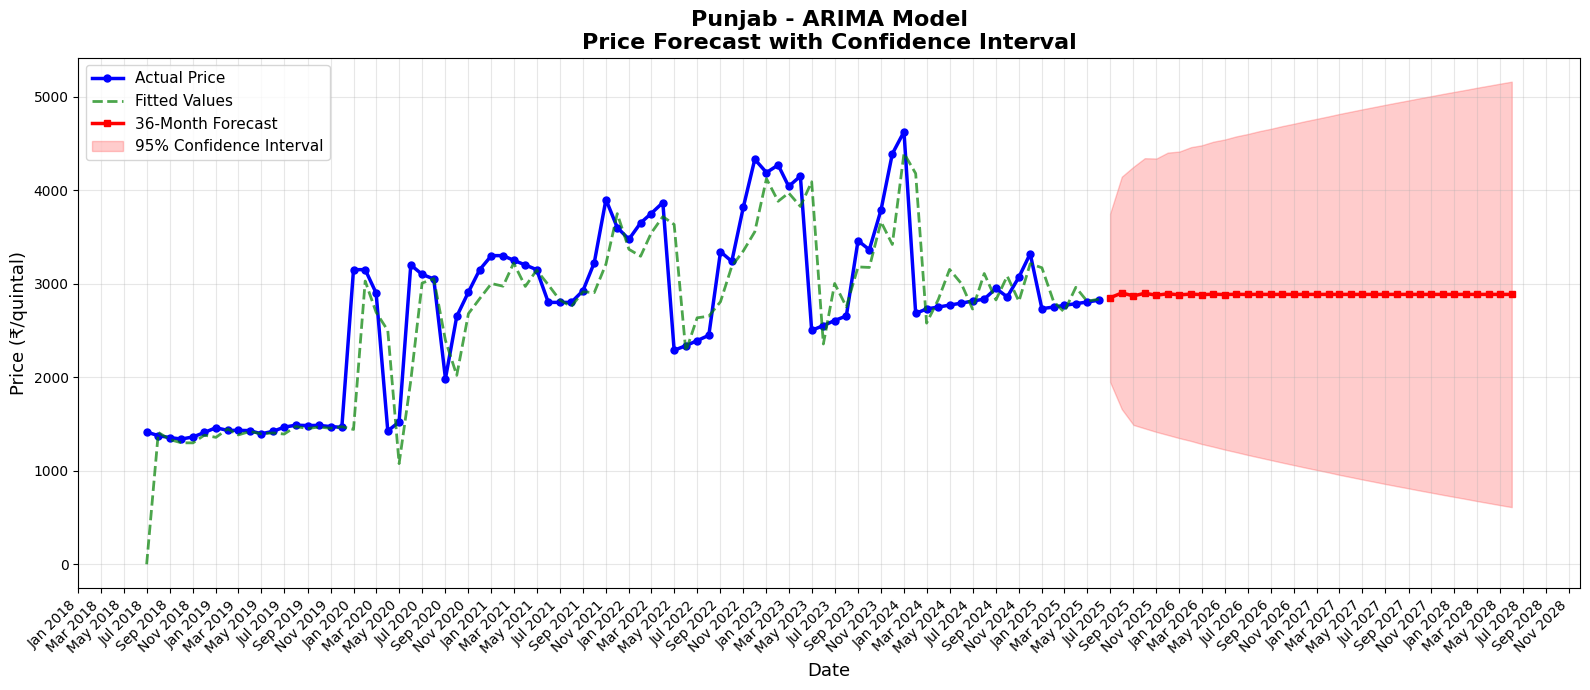


********************************************************************************
* SARIMA MODEL FOR Punjab
********************************************************************************

Punjab - SARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      2830.96
            2 Aug 2025                      2834.50
            3 Sep 2025                      2828.86
            4 Oct 2025                      2808.15
            5 Nov 2025                      2845.10
            6 Dec 2025                      2884.15
            7 Jan 2026                      2716.59
            8 Feb 2026                      2828.57
            9 Mar 2026                      2827.71
           10 Apr 2026                      2832.42
           11 May 2026                      2820.59
           12 Jun 2026                      2824.48
           13 Jul 2026                      2825.85
           14 Aug 2026            

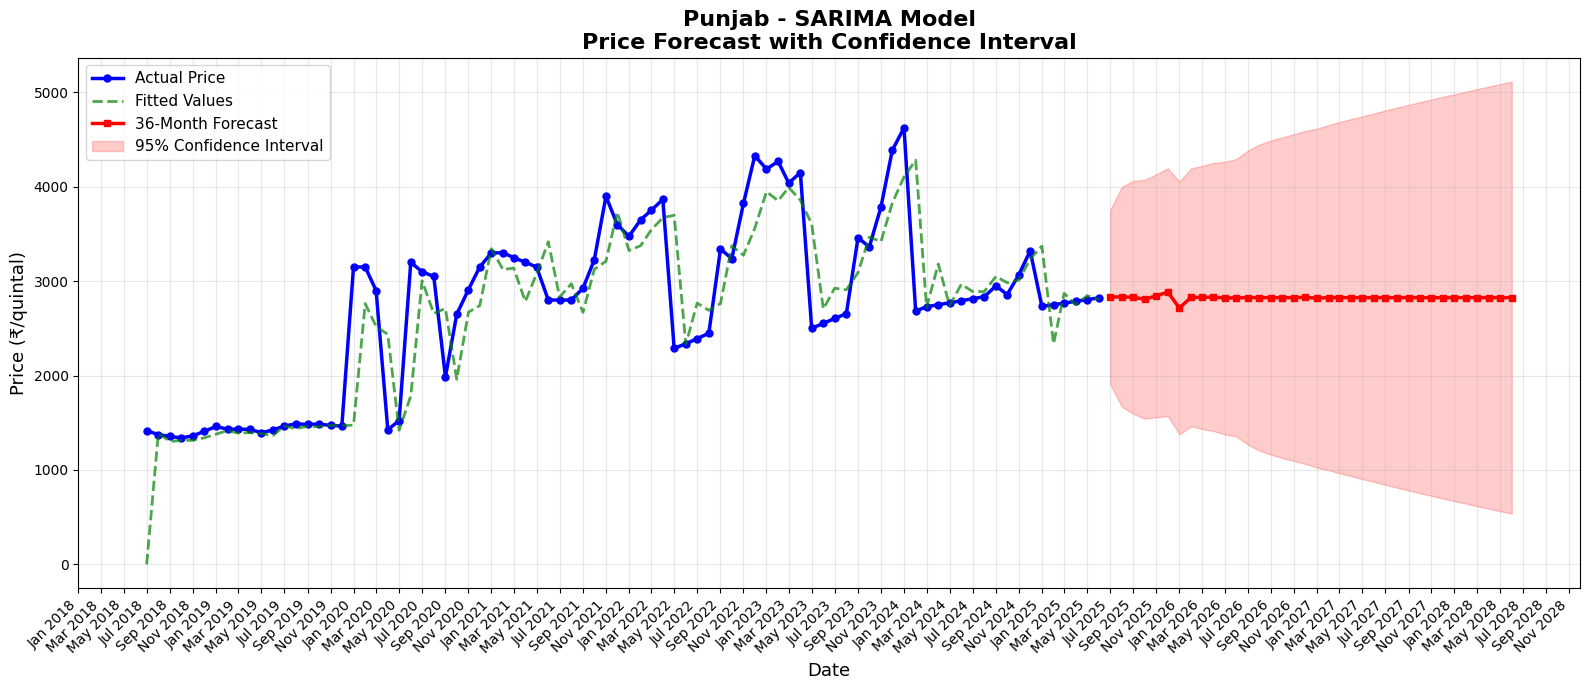


********************************************************************************
* SARIMAX MODEL FOR Punjab
********************************************************************************

Punjab - SARIMAX Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      2757.05
            2 Aug 2025                      2762.92
            3 Sep 2025                      2761.76
            4 Oct 2025                      2766.00
            5 Nov 2025                      2774.61
            6 Dec 2025                      2772.25
            7 Jan 2026                      2763.95
            8 Feb 2026                      2766.19
            9 Mar 2026                      2767.67
           10 Apr 2026                      2768.88
           11 May 2026                      2770.36
           12 Jun 2026                      2772.36
           13 Jul 2026                      2754.65
           14 Aug 2026          

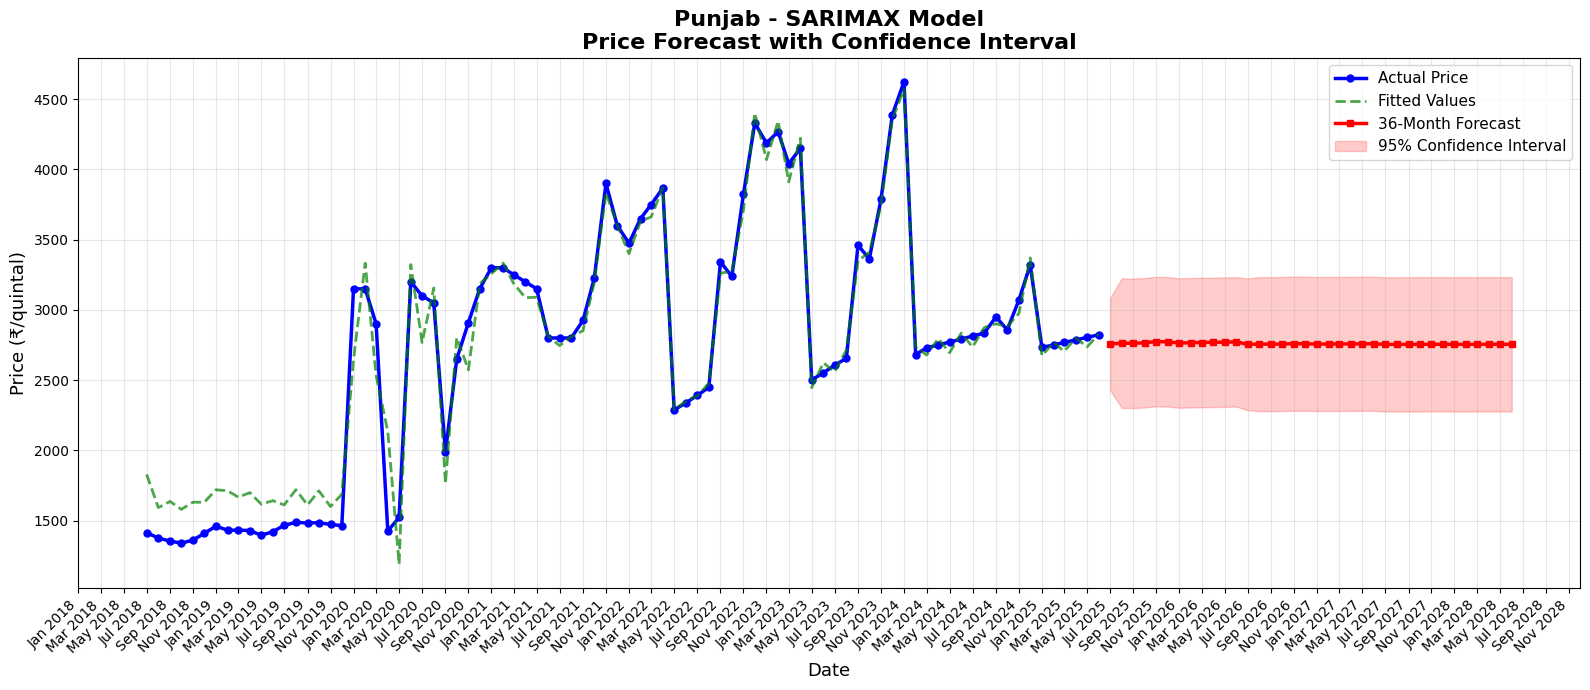



################################################################################
# GENERATING FORECASTS FOR UTAR PRADESH
################################################################################


********************************************************************************
* ARIMA MODEL FOR Utar Pradesh
********************************************************************************

Utar Pradesh - ARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jan 2025                      2269.13
            2 Feb 2025                      2263.54
            3 Mar 2025                      2265.12
            4 Apr 2025                      2272.88
            5 May 2025                      2284.35
            6 Jun 2025                      2296.33
            7 Jul 2025                      2305.76
            8 Aug 2025                      2310.47
            9 Sep 2025                      2309.67
           10 Oct 2025     

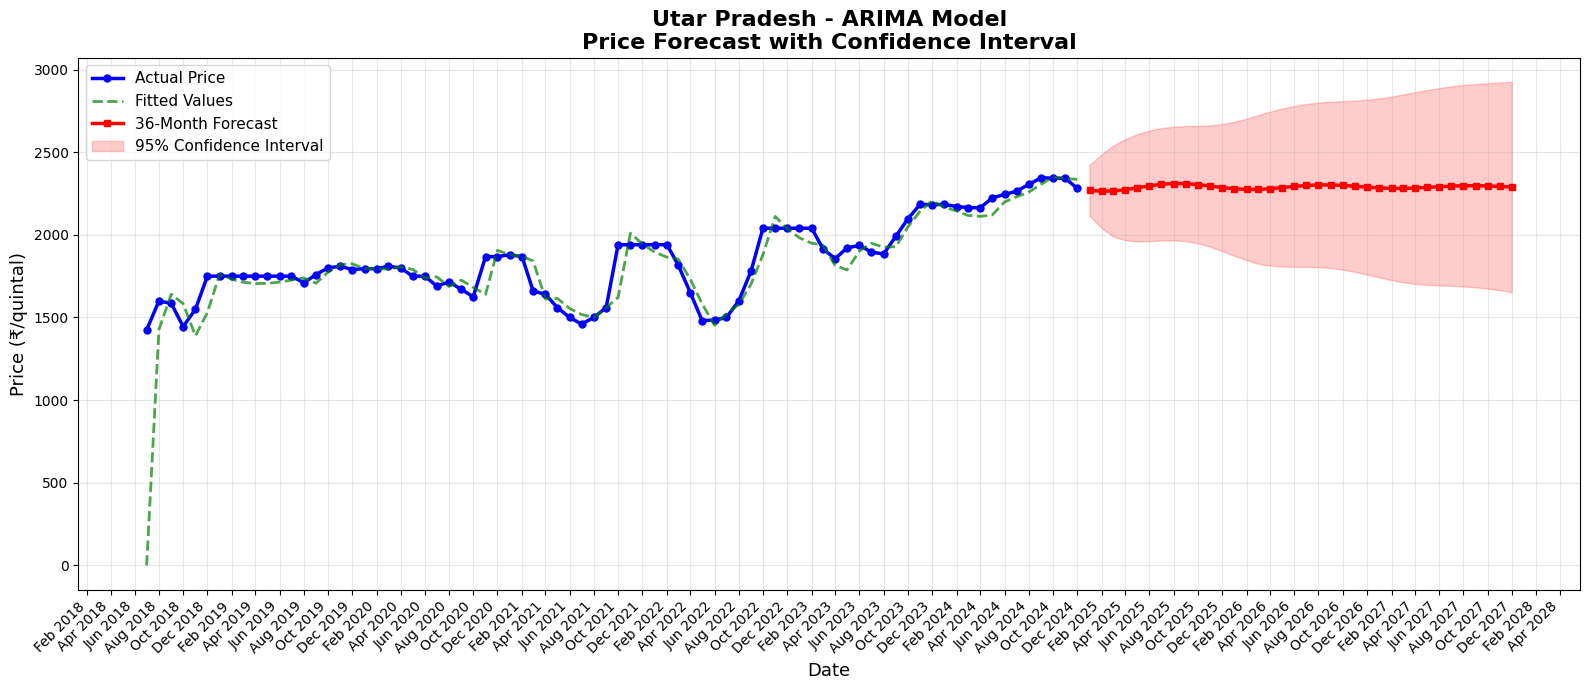


********************************************************************************
* SARIMA MODEL FOR Utar Pradesh
********************************************************************************

Utar Pradesh - SARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jan 2025                      2317.68
            2 Feb 2025                      2341.77
            3 Mar 2025                      2354.44
            4 Apr 2025                      2362.83
            5 May 2025                      2427.56
            6 Jun 2025                      2449.94
            7 Jul 2025                      2471.13
            8 Aug 2025                      2512.73
            9 Sep 2025                      2553.04
           10 Oct 2025                      2551.19
           11 Nov 2025                      2550.27
           12 Dec 2025                      2489.31
           13 Jan 2026                      2526.00
           14 Feb 2026

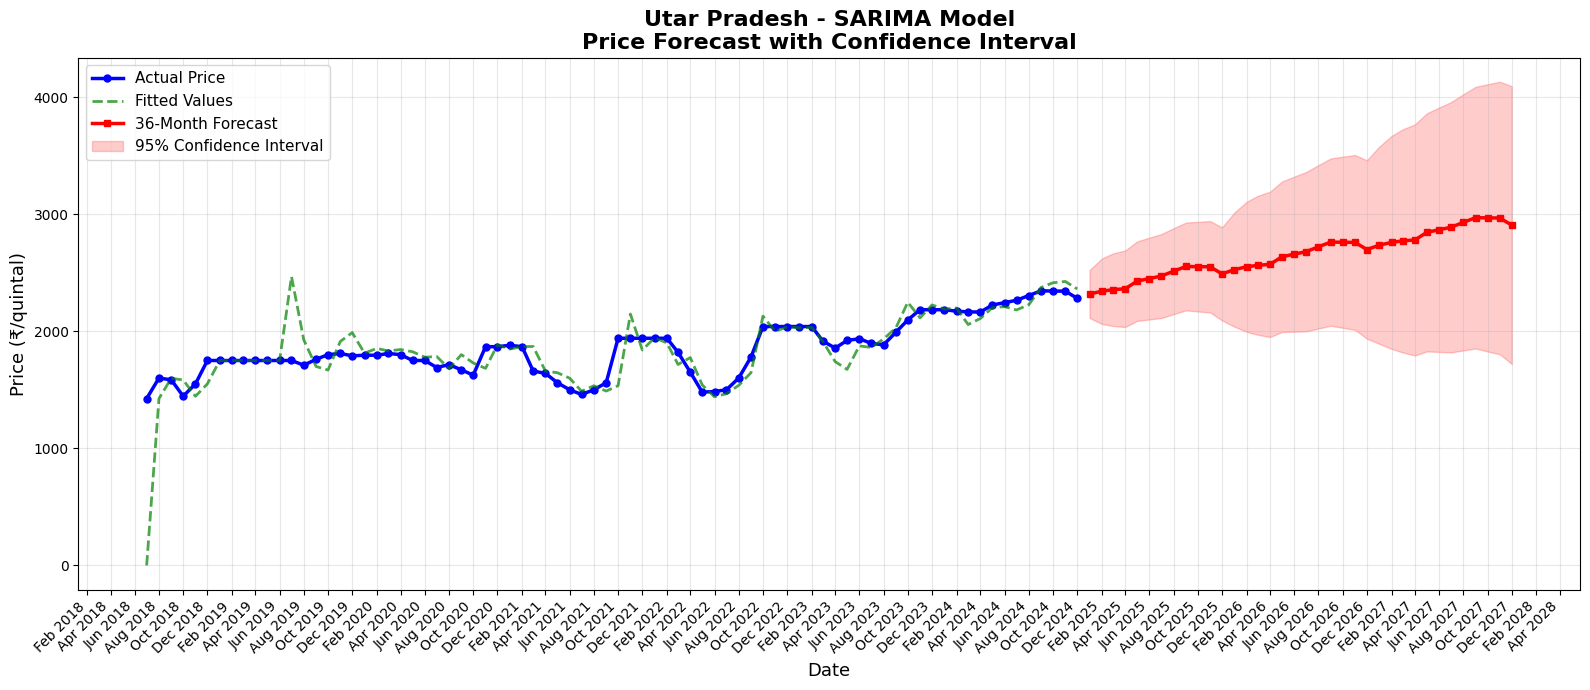


********************************************************************************
* SARIMAX MODEL FOR Utar Pradesh - SKIPPED
* Reason: No production data available for this state
********************************************************************************


################################################################################
# GENERATING FORECASTS FOR DELHI
################################################################################


********************************************************************************
* ARIMA MODEL FOR Delhi
********************************************************************************

Delhi - ARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1683.45
            2 Aug 2025                      1669.70
            3 Sep 2025                      1664.76
            4 Oct 2025                      1655.54
            5 Nov 2025                      1653

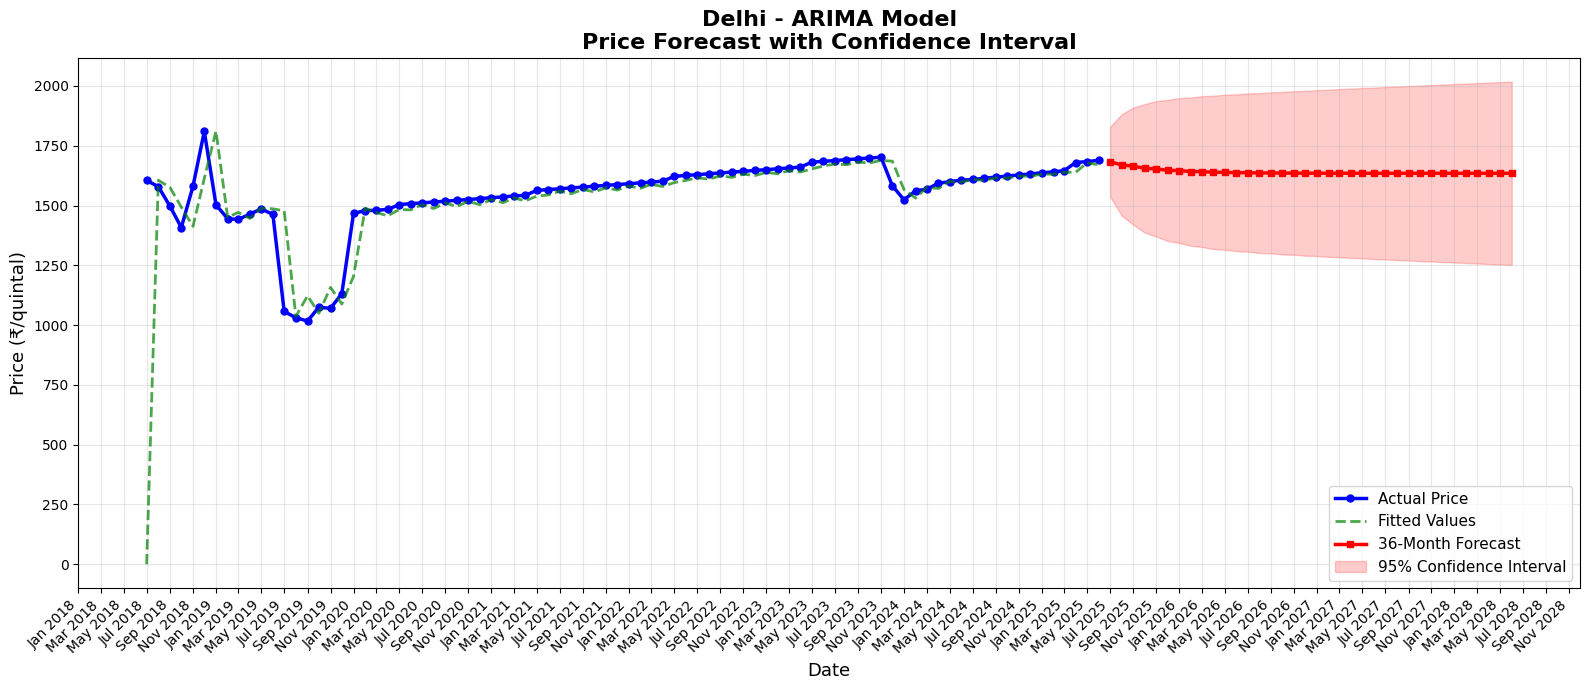


********************************************************************************
* SARIMA MODEL FOR Delhi
********************************************************************************

Delhi - SARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1693.00
            2 Aug 2025                      1686.71
            3 Sep 2025                      1683.91
            4 Oct 2025                      1679.21
            5 Nov 2025                      1672.47
            6 Dec 2025                      1699.47
            7 Jan 2026                      1707.27
            8 Feb 2026                      1692.97
            9 Mar 2026                      1687.55
           10 Apr 2026                      1660.90
           11 May 2026                      1649.05
           12 Jun 2026                      1643.46
           13 Jul 2026                      1645.11
           14 Aug 2026              

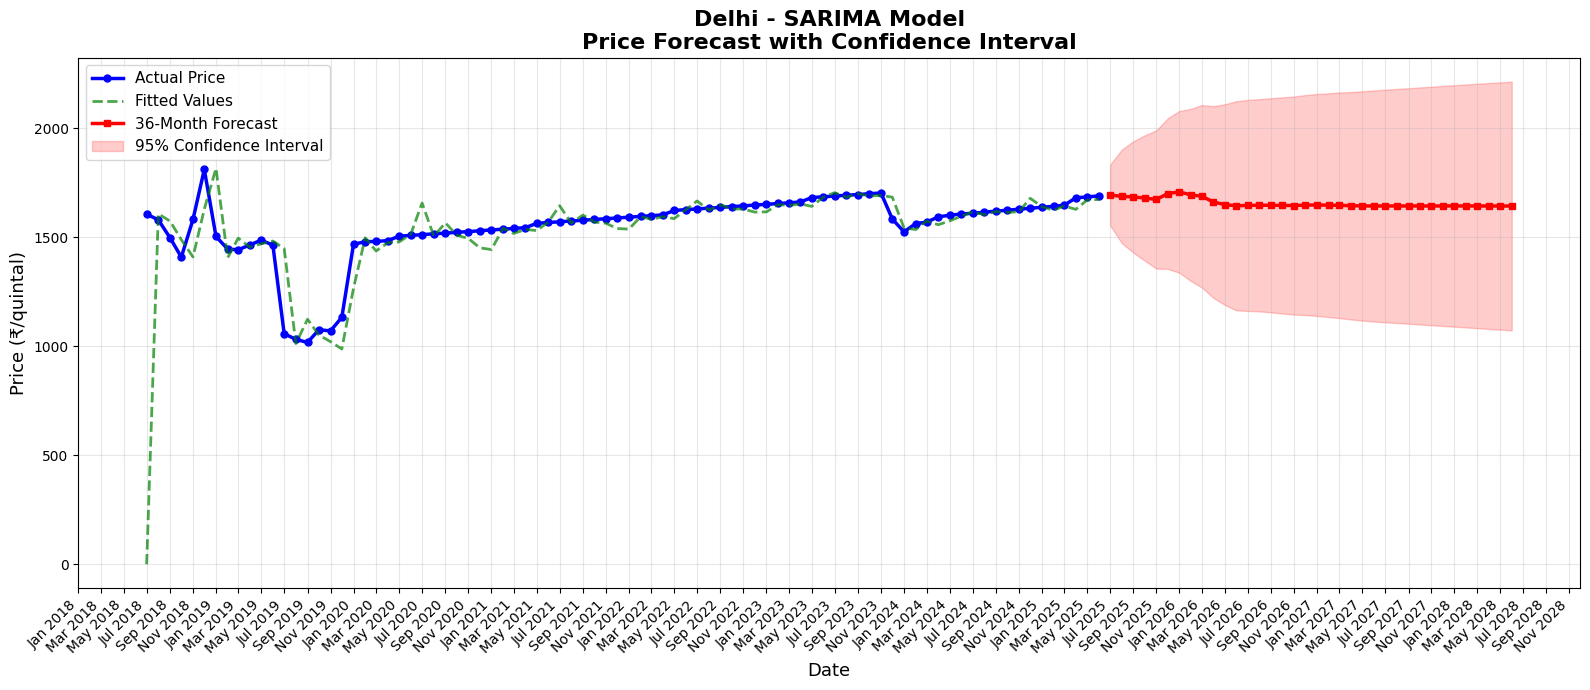


********************************************************************************
* SARIMAX MODEL FOR Delhi
********************************************************************************

Delhi - SARIMAX Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1691.91
            2 Aug 2025                      1688.07
            3 Sep 2025                      1684.66
            4 Oct 2025                      1680.30
            5 Nov 2025                      1675.36
            6 Dec 2025                      1701.12
            7 Jan 2026                      1710.08
            8 Feb 2026                      1697.41
            9 Mar 2026                      1692.52
           10 Apr 2026                      1666.98
           11 May 2026                      1658.29
           12 Jun 2026                      1653.28
           13 Jul 2026                      1652.44
           14 Aug 2026            

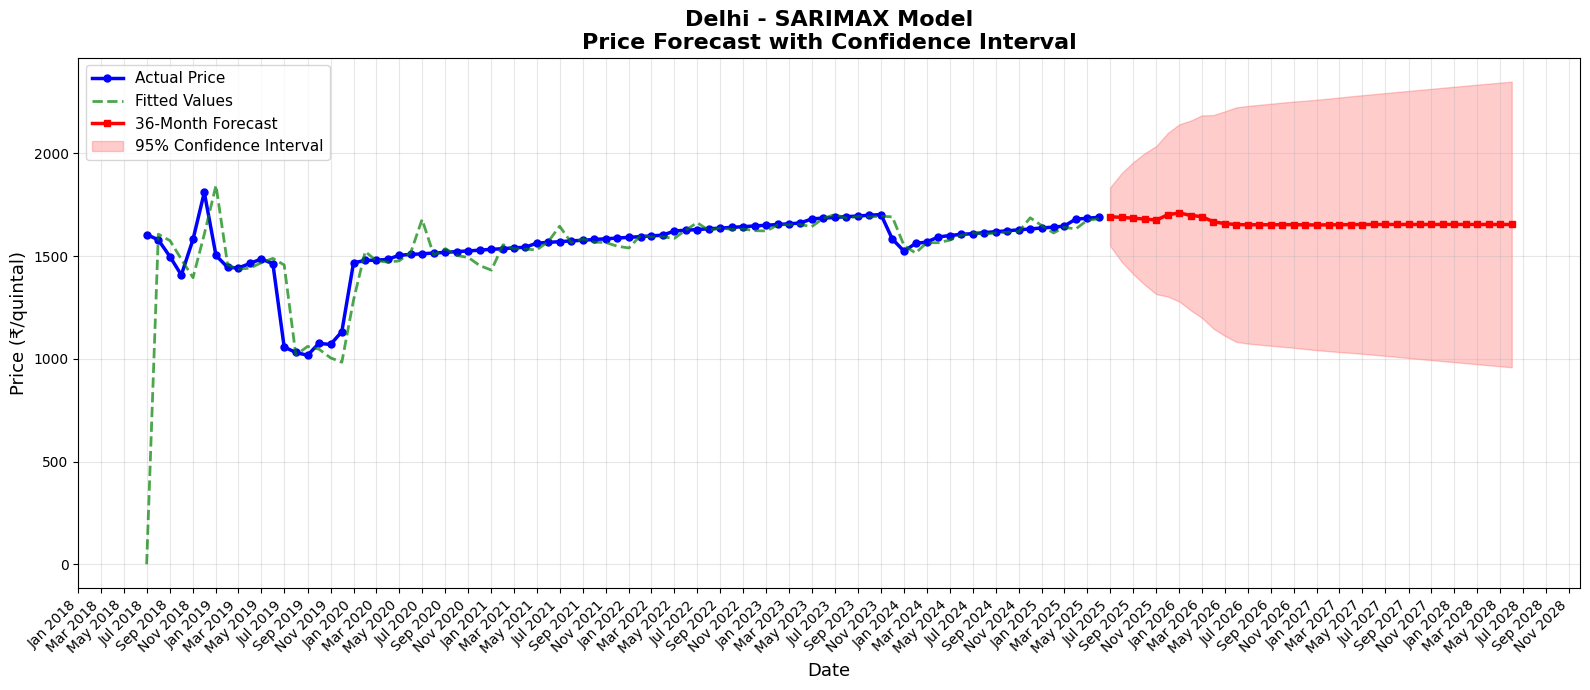



################################################################################
# GENERATING FORECASTS FOR WEST BENGAL
################################################################################


********************************************************************************
* ARIMA MODEL FOR West Bengal
********************************************************************************

West Bengal - ARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1931.46
            2 Aug 2025                      1918.05
            3 Sep 2025                      1944.84
            4 Oct 2025                      1937.18
            5 Nov 2025                      1943.99
            6 Dec 2025                      1943.99
            7 Jan 2026                      1943.99
            8 Feb 2026                      1943.99
            9 Mar 2026                      1943.99
           10 Apr 2026        

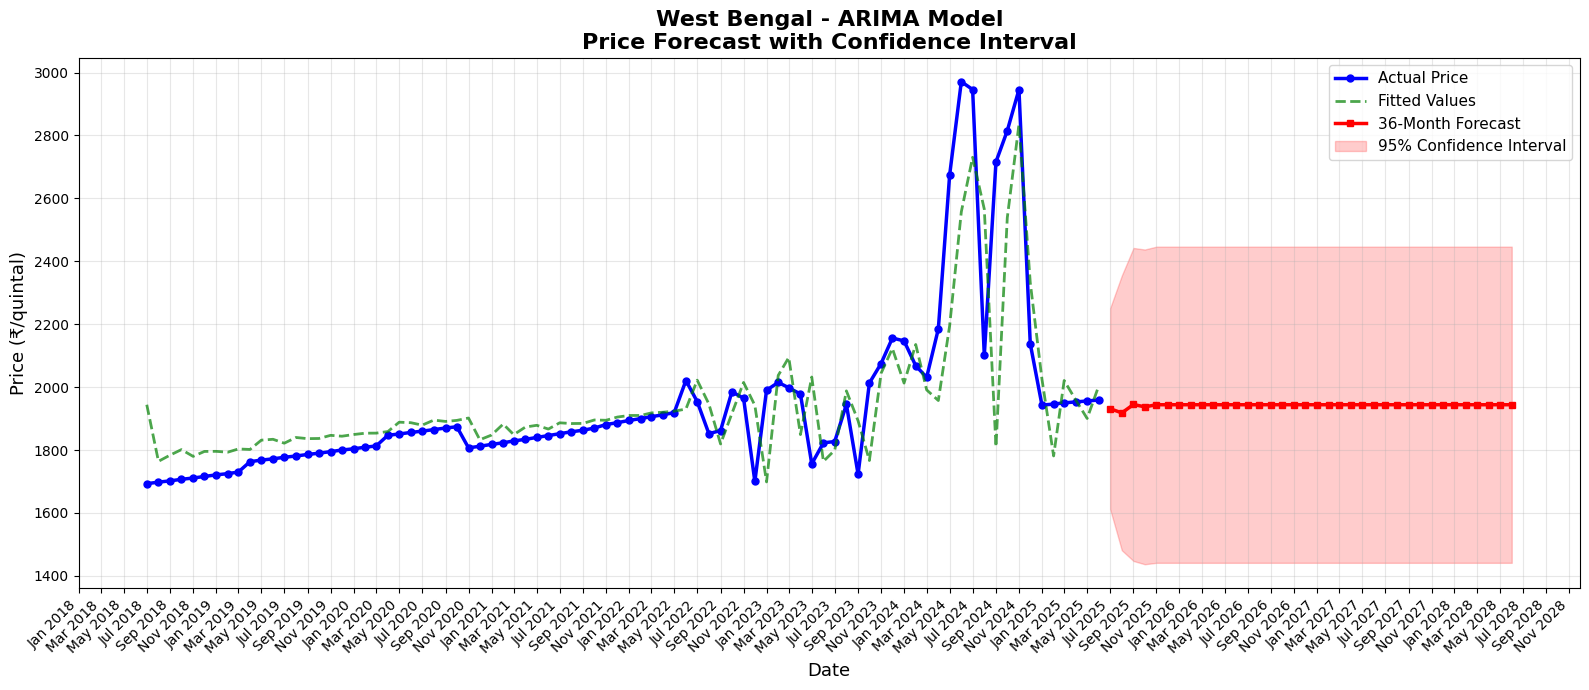


********************************************************************************
* SARIMA MODEL FOR West Bengal
********************************************************************************

West Bengal - SARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      2036.01
            2 Aug 2025                      1787.46
            3 Sep 2025                      2028.67
            4 Oct 2025                      2257.98
            5 Nov 2025                      2390.38
            6 Dec 2025                      2119.10
            7 Jan 2026                      2049.35
            8 Feb 2026                      2007.55
            9 Mar 2026                      1992.40
           10 Apr 2026                      2086.77
           11 May 2026                      2380.34
           12 Jun 2026                      2558.68
           13 Jul 2026                      2575.75
           14 Aug 2026  

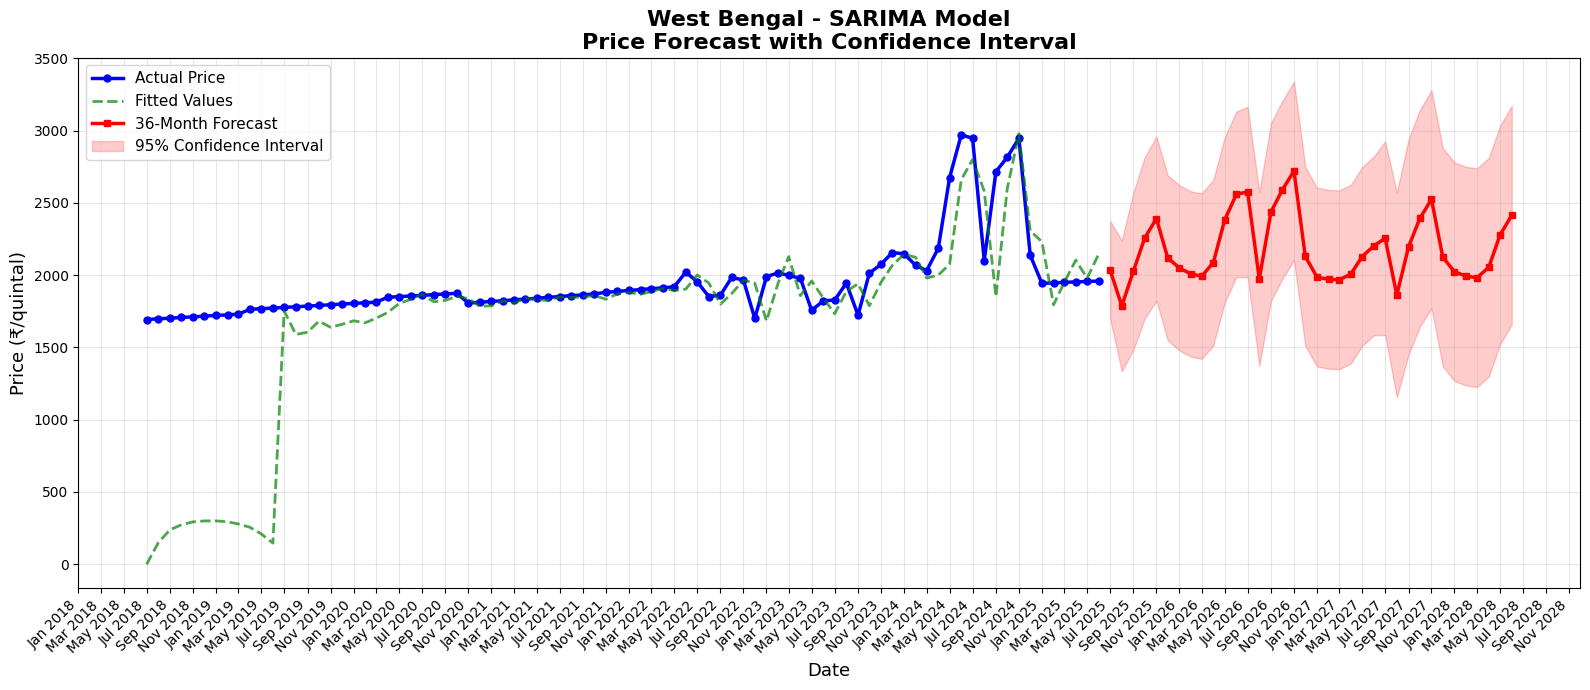


********************************************************************************
* SARIMAX MODEL FOR West Bengal
********************************************************************************

West Bengal - SARIMAX Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      2015.36
            2 Aug 2025                      1850.26
            3 Sep 2025                      1886.60
            4 Oct 2025                      2138.22
            5 Nov 2025                      2217.98
            6 Dec 2025                      2007.16
            7 Jan 2026                      1951.12
            8 Feb 2026                      1972.75
            9 Mar 2026                      1955.65
           10 Apr 2026                      2067.94
           11 May 2026                      2408.60
           12 Jun 2026                      2616.77
           13 Jul 2026                      2620.92
           14 Aug 2026

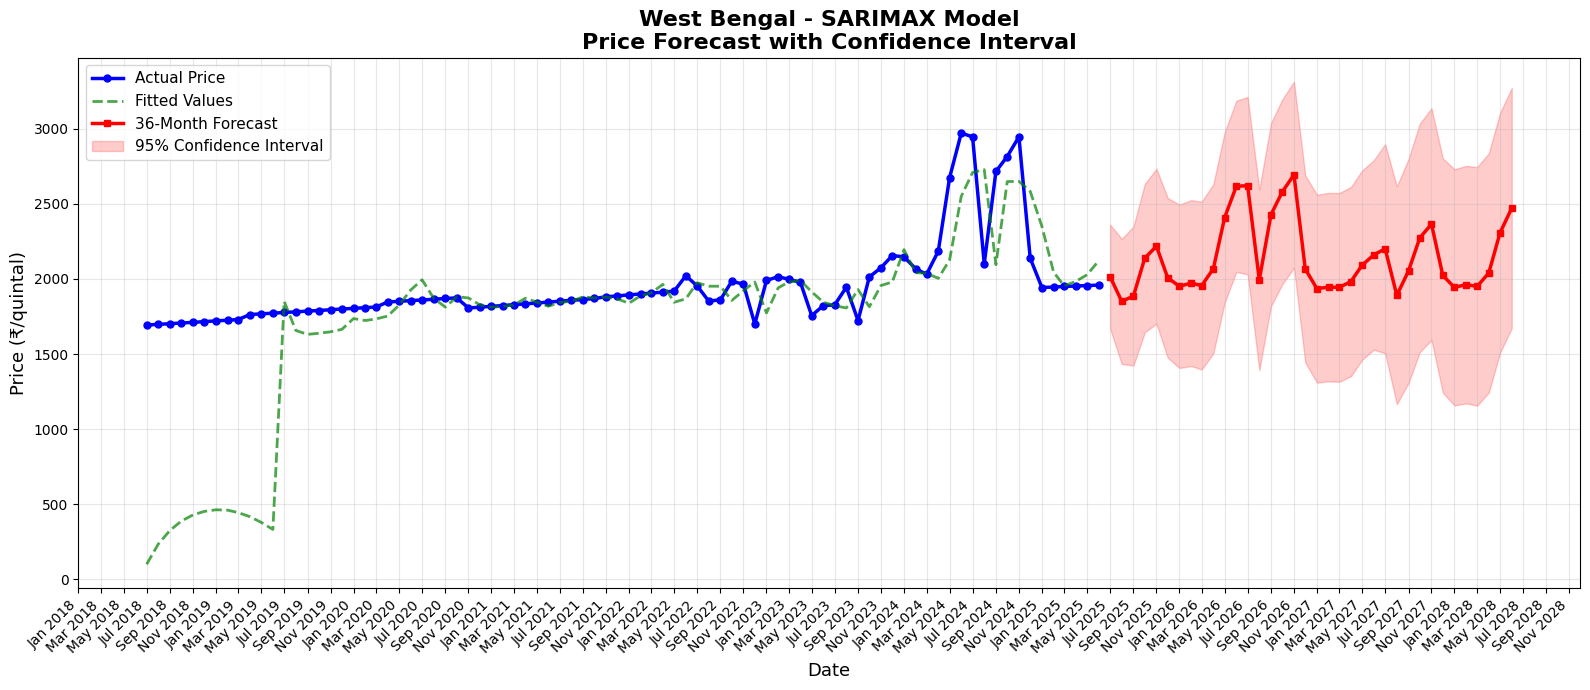



################################################################################
# GENERATING FORECASTS FOR TAMIL NADU
################################################################################


********************************************************************************
* ARIMA MODEL FOR Tamil Nadu
********************************************************************************

Tamil Nadu - ARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1773.29
            2 Aug 2025                      1732.32
            3 Sep 2025                      1705.91
            4 Oct 2025                      1712.64
            5 Nov 2025                      1655.07
            6 Dec 2025                      1631.15
            7 Jan 2026                      1634.86
            8 Feb 2026                      1599.98
            9 Mar 2026                      1605.95
           10 Apr 2026           

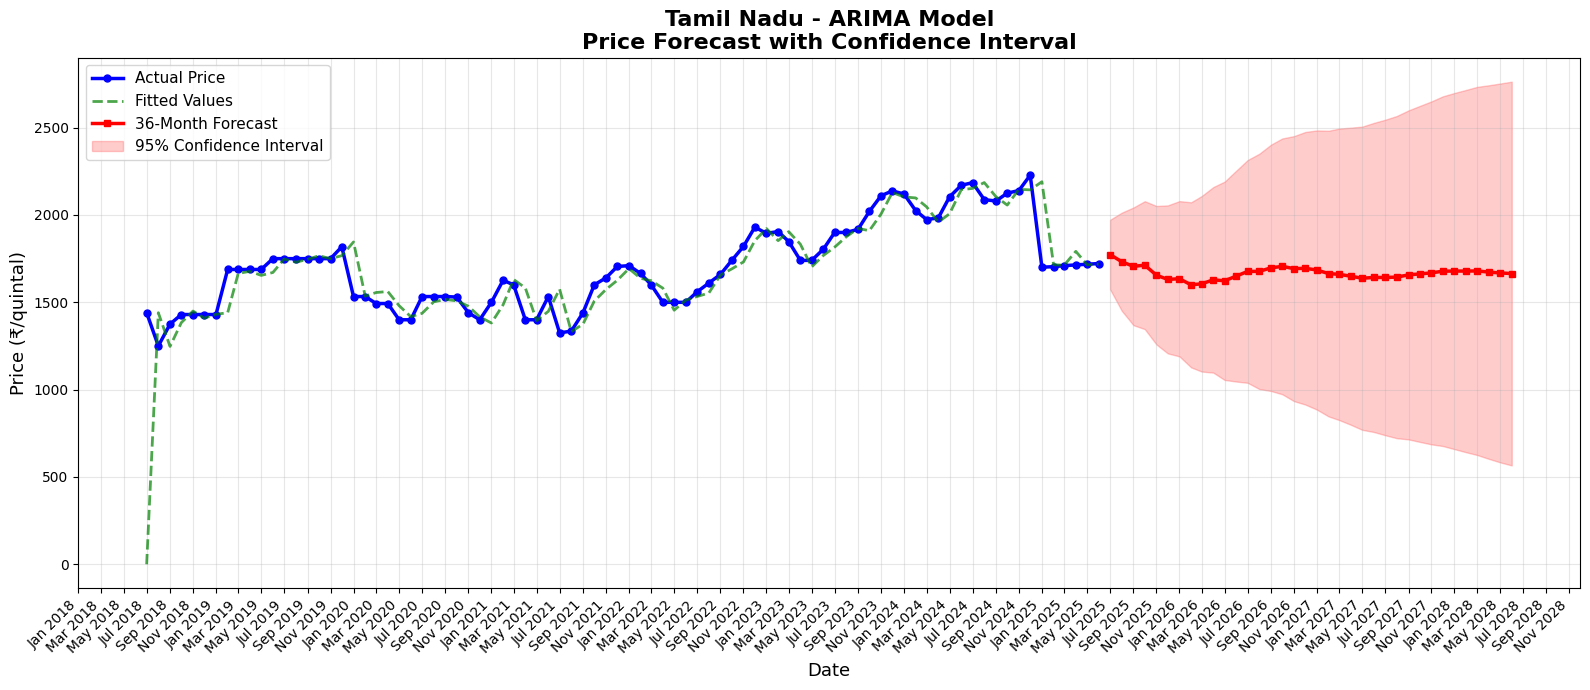


********************************************************************************
* SARIMA MODEL FOR Tamil Nadu
********************************************************************************

Tamil Nadu - SARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1806.78
            2 Aug 2025                      1772.71
            3 Sep 2025                      1815.49
            4 Oct 2025                      1903.80
            5 Nov 2025                      1954.72
            6 Dec 2025                      2072.93
            7 Jan 2026                      1571.17
            8 Feb 2026                      1595.32
            9 Mar 2026                      1619.01
           10 Apr 2026                      1637.83
           11 May 2026                      1654.23
           12 Jun 2026                      1668.62
           13 Jul 2026                      1762.09
           14 Aug 2026    

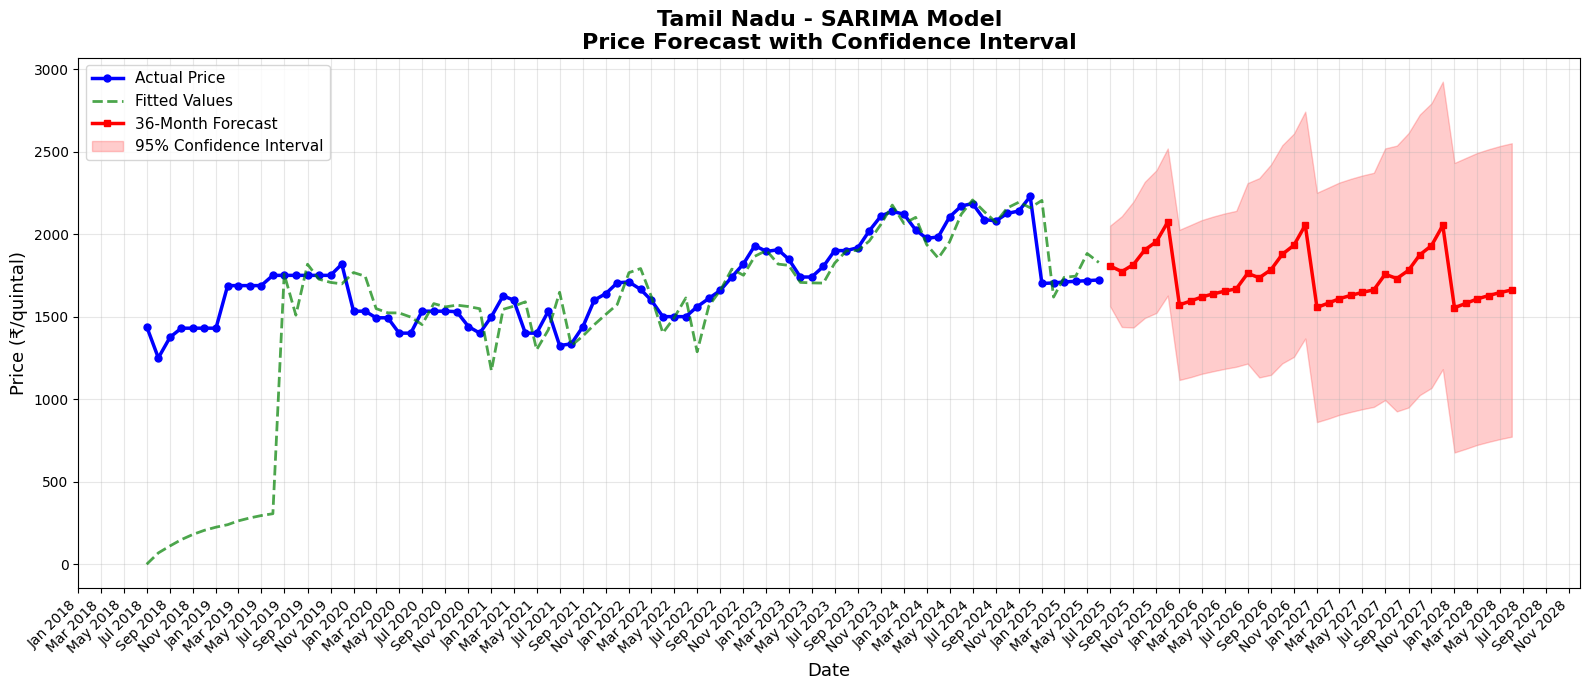


********************************************************************************
* SARIMAX MODEL FOR Tamil Nadu
********************************************************************************

Tamil Nadu - SARIMAX Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1721.62
            2 Aug 2025                      1721.41
            3 Sep 2025                      1720.92
            4 Oct 2025                      1720.35
            5 Nov 2025                      1719.96
            6 Dec 2025                      1719.46
            7 Jan 2026                      1719.55
            8 Feb 2026                      1719.07
            9 Mar 2026                      1718.86
           10 Apr 2026                      1718.74
           11 May 2026                      1718.37
           12 Jun 2026                      1717.87
           13 Jul 2026                      1717.49
           14 Aug 2026  

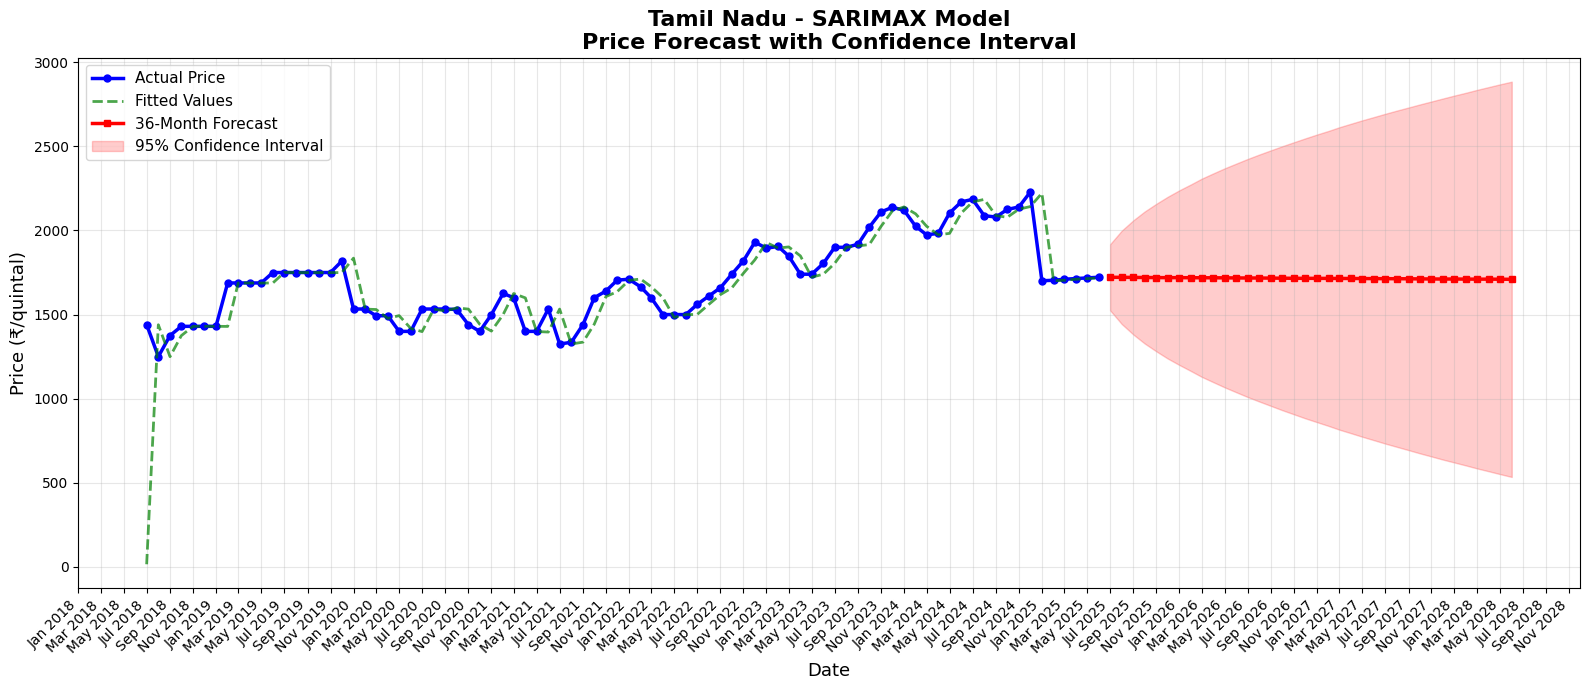



################################################################################
# ALL VISUALIZATIONS AND FORECASTS GENERATED SUCCESSFULLY!
################################################################################



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator, DateFormatter
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('/content/paddy_price_production.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%Y')
df = df.sort_values('Date').reset_index(drop=True)

# Store the best model parameters from previous grid search
best_params = {
    'Punjab': {'ARIMA': (1,1,4), 'SARIMA': (2, 1, 1, 1, 0, 1), 'SARIMAX': (0, 0, 1, 1, 0, 0)},
    'Utar Pradesh': {'ARIMA': (2, 1, 2), 'SARIMA': (1, 1, 2, 0, 1, 0), 'SARIMAX': None},
    'Delhi': {'ARIMA': (2, 1, 3), 'SARIMA': (2, 1, 0, 1, 0, 1), 'SARIMAX': (1, 1, 0, 1, 0, 1)},
    'West Bengal': {'ARIMA': (0, 0, 4), 'SARIMA': (2, 0, 2, 1, 1, 0), 'SARIMAX': (1, 0, 1, 1, 1, 0)},
    'Tamil Nadu': {'ARIMA': (4, 1, 4), 'SARIMA': (2, 0, 1, 0, 1, 0), 'SARIMAX': (1, 0, 0, 1, 0, 1)}
}

states = df['State'].unique()

def plot_forecast_with_confidence(state, model_type, best_param, price_series, production_series=None, exog_forecast=None):
    """
    Create a comprehensive forecast plot with actual, fitted, forecast, and confidence intervals
    """

    # Train model on full data
    if model_type == 'ARIMA':
        model = ARIMA(price_series, order=best_param)
        model_fit = model.fit()

        # Get fitted values
        fitted_values = model_fit.fittedvalues

        # Forecast 36 months with confidence interval
        forecast_result = model_fit.get_forecast(steps=36)
        forecast_mean = forecast_result.predicted_mean
        forecast_ci = forecast_result.conf_int()

    elif model_type == 'SARIMA':
        model = SARIMAX(price_series, order=best_param[:3], seasonal_order=best_param[3:] + (12,))
        model_fit = model.fit(disp=False)

        fitted_values = model_fit.fittedvalues

        forecast_result = model_fit.get_forecast(steps=36)
        forecast_mean = forecast_result.predicted_mean
        forecast_ci = forecast_result.conf_int()

    elif model_type == 'SARIMAX' and best_param is not None:
        if production_series is None or exog_forecast is None:
            return None, None, None, None  # Skip if no exog data

        model = SARIMAX(price_series, order=best_param[:3], seasonal_order=best_param[3:] + (12,), exog=production_series)
        model_fit = model.fit(disp=False)

        fitted_values = model_fit.fittedvalues

        forecast_result = model_fit.get_forecast(steps=36, exog=exog_forecast)
        forecast_mean = forecast_result.predicted_mean
        forecast_ci = forecast_result.conf_int()
    else:
        return None, None, None, None

    # figure
    fig, ax = plt.subplots(figsize=(16, 7))
    ax.plot(price_series.index, price_series.values, 'b-', linewidth=2.5, label='Actual Price', marker='o', markersize=5)
    ax.plot(fitted_values.index, fitted_values.values, 'g--', linewidth=2, alpha=0.7, label='Fitted Values')
    last_date = price_series.index[-1]
    future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=36, freq='MS')
    ax.plot(future_dates, forecast_mean.values, 'r-', linewidth=2.5, label='36-Month Forecast', marker='s', markersize=5)
    ax.fill_between(future_dates,
                     forecast_ci.iloc[:, 0].values,
                     forecast_ci.iloc[:, 1].values,
                     color='red', alpha=0.2, label='95% Confidence Interval')
    ax.xaxis.set_major_locator(MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))

    # Formatting
    ax.set_title(f'{state} - {model_type} Model\nPrice Forecast with Confidence Interval', fontsize=16, fontweight='bold')
    ax.set_xlabel('Date', fontsize=13)
    ax.set_ylabel('Price (₹/quintal)', fontsize=13)
    ax.legend(loc='best', fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    return fig, model_fit, forecast_mean, forecast_ci, future_dates

def display_predictions_table(forecast_mean, future_dates, state, model_type):
    """
    Display predictions in a formatted table
    """
    print(f"\n{'='*80}")
    print(f"{state} - {model_type} Model: 36-Month Price Forecasts")
    print(f"{'='*80}")


    forecast_df = pd.DataFrame({
        'Month': future_dates.strftime('%b %Y'),
        'Predicted Price (₹/quintal)': forecast_mean.values.round(2)
    })
    forecast_df['Month_Number'] = range(1, 37)
    forecast_df = forecast_df[['Month_Number', 'Month', 'Predicted Price (₹/quintal)']]
    print(forecast_df.to_string(index=False))
    print(f"{'='*80}\n")
    return forecast_df

# Generate plots and predictions for all states and models
plot_results = {}

for state in states:
    print(f"\n\n{'#'*80}")
    print(f"# GENERATING FORECASTS FOR {state.upper()}")
    print(f"{'#'*80}\n")

    state_df = df[df['State'] == state].sort_values('Date').copy()
    state_df.set_index('Date', inplace=True)
    price_series = state_df['Prices'].dropna()
    price_series.index.freq = 'MS'
    production_series = state_df['Production'].dropna()
    production_series.index.freq = 'MS'

    state_plots = {}
    state_forecasts = {}

    #  ARIMA
    print(f"\n{'*'*80}")
    print(f"* ARIMA MODEL FOR {state}")
    print(f"{'*'*80}")

    arima_param = best_params[state]['ARIMA']
    result = plot_forecast_with_confidence(
        state, 'ARIMA', arima_param, price_series
    )
    if result[0] is not None:
        fig_arima, model_arima, forecast_arima, ci_arima, future_dates_arima = result

        # Display predictions table
        forecast_df_arima = display_predictions_table(forecast_arima, future_dates_arima, state, 'ARIMA')

        # Display graph
        plt.show()

        state_plots['ARIMA'] = {
            'figure': fig_arima,
            'model': model_arima,
            'forecast': forecast_arima,
            'ci': ci_arima
        }
        state_forecasts['ARIMA'] = forecast_df_arima

    # SARIMA
    print(f"\n{'*'*80}")
    print(f"* SARIMA MODEL FOR {state}")
    print(f"{'*'*80}")

    sarima_param = best_params[state]['SARIMA']
    result = plot_forecast_with_confidence(
        state, 'SARIMA', sarima_param, price_series
    )
    if result[0] is not None:
        fig_sarima, model_sarima, forecast_sarima, ci_sarima, future_dates_sarima = result

        # Display predictions table
        forecast_df_sarima = display_predictions_table(forecast_sarima, future_dates_sarima, state, 'SARIMA')

        # Display graph
        plt.show()

        state_plots['SARIMA'] = {
            'figure': fig_sarima,
            'model': model_sarima,
            'forecast': forecast_sarima,
            'ci': ci_sarima
        }
        state_forecasts['SARIMA'] = forecast_df_sarima

    #  SARIMAX
    sarimax_param = best_params[state]['SARIMAX']
    if sarimax_param is not None:
        print(f"\n{'*'*80}")
        print(f"* SARIMAX MODEL FOR {state}")
        print(f"{'*'*80}")

        if len(production_series) == len(price_series):
            exog_forecast = np.array([[production_series.values[-1]]] * 36)
            result = plot_forecast_with_confidence(
                state, 'SARIMAX', sarimax_param, price_series,
                production_series=production_series,
                exog_forecast=exog_forecast
            )
            if result[0] is not None:
                fig_sarimax, model_sarimax, forecast_sarimax, ci_sarimax, future_dates_sarimax = result

                # Display predictions table
                forecast_df_sarimax = display_predictions_table(forecast_sarimax, future_dates_sarimax, state, 'SARIMAX')

                # Display graph
                plt.show()

                state_plots['SARIMAX'] = {
                    'figure': fig_sarimax,
                    'model': model_sarimax,
                    'forecast': forecast_sarimax,
                    'ci': ci_sarimax
                }
                state_forecasts['SARIMAX'] = forecast_df_sarimax
    else:
        print(f"\n{'*'*80}")
        print(f"* SARIMAX MODEL FOR {state} - SKIPPED")
        print(f"* Reason: No production data available for this state")
        print(f"{'*'*80}")

    plot_results[state] = {
        'plots': state_plots,
        'forecasts': state_forecasts
    }

print(f"\n\n{'#'*80}")
print(f"# ALL VISUALIZATIONS AND FORECASTS GENERATED SUCCESSFULLY!")
print(f"{'#'*80}\n")


2nd Iteration




################################################################################
# GENERATING FORECASTS FOR PUNJAB
################################################################################


********************************************************************************
* ARIMA MODEL FOR Punjab
********************************************************************************

Punjab - ARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      2848.82
            2 Aug 2025                      2900.94
            3 Sep 2025                      2869.67
            4 Oct 2025                      2897.14
            5 Nov 2025                      2876.62
            6 Dec 2025                      2891.95
            7 Jan 2026                      2880.50
            8 Feb 2026                      2889.06
            9 Mar 2026                      2882.66
           10 Apr 2026                      2

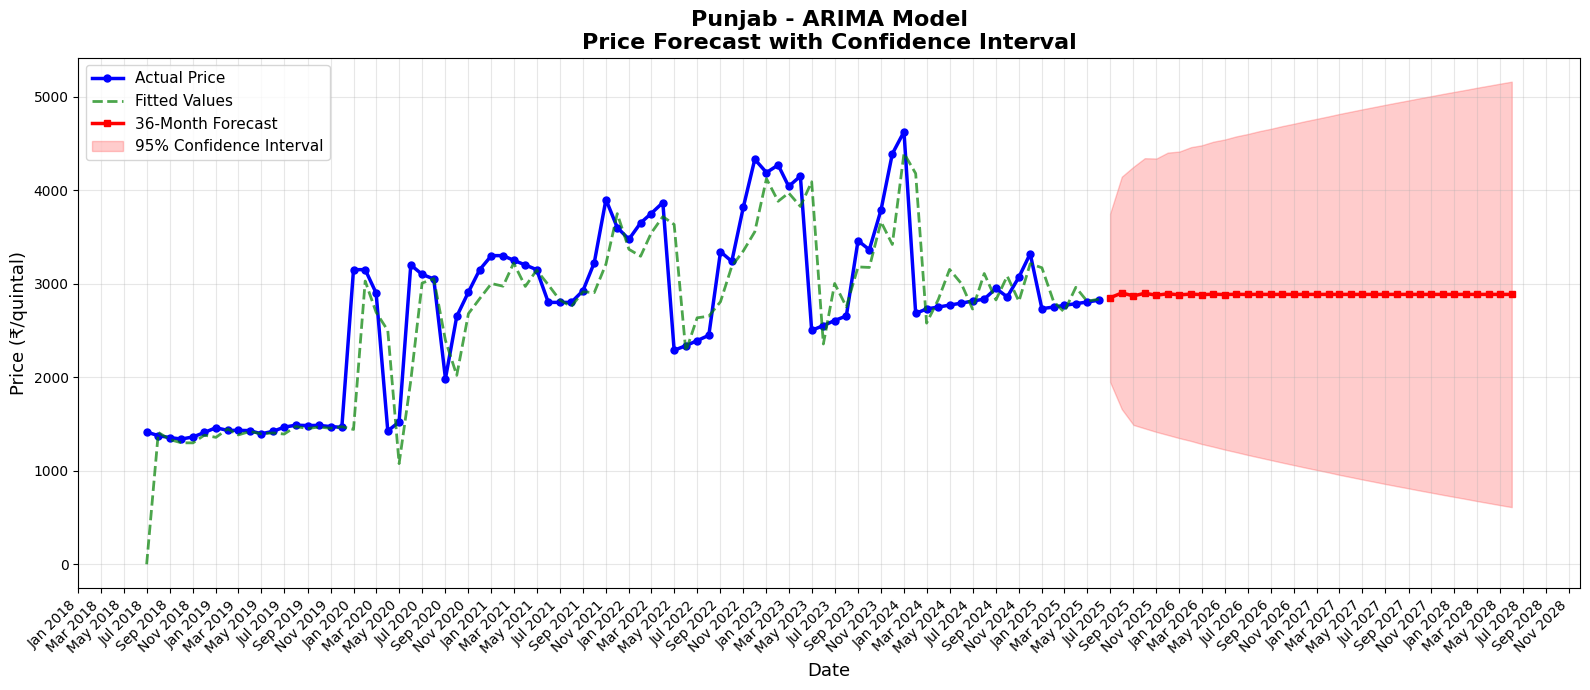


********************************************************************************
* SARIMA MODEL FOR Punjab
********************************************************************************

Punjab - SARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      2867.82
            2 Aug 2025                      2728.52
            3 Sep 2025                      2879.00
            4 Oct 2025                      2914.37
            5 Nov 2025                      3161.01
            6 Dec 2025                      3418.51
            7 Jan 2026                      3253.61
            8 Feb 2026                      2985.85
            9 Mar 2026                      2952.90
           10 Apr 2026                      2891.45
           11 May 2026                      2616.00
           12 Jun 2026                      2756.98
           13 Jul 2026                      2807.51
           14 Aug 2026            

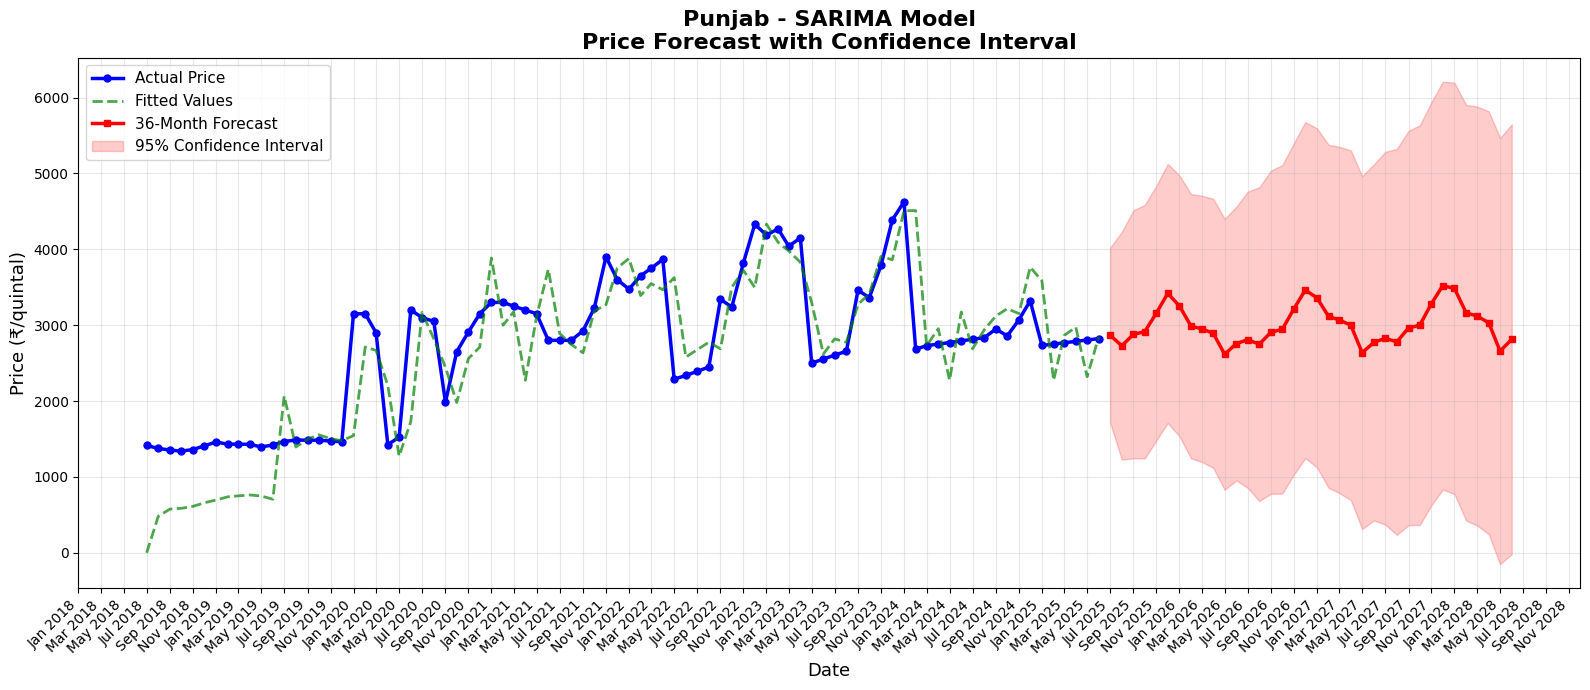


********************************************************************************
* SARIMAX MODEL FOR Punjab
********************************************************************************

Punjab - SARIMAX Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      2828.97
            2 Aug 2025                      2819.03
            3 Sep 2025                      2804.39
            4 Oct 2025                      2799.38
            5 Nov 2025                      2799.38
            6 Dec 2025                      2799.38
            7 Jan 2026                      2799.38
            8 Feb 2026                      2799.38
            9 Mar 2026                      2799.38
           10 Apr 2026                      2799.38
           11 May 2026                      2799.38
           12 Jun 2026                      2799.38
           13 Jul 2026                      2799.38
           14 Aug 2026          

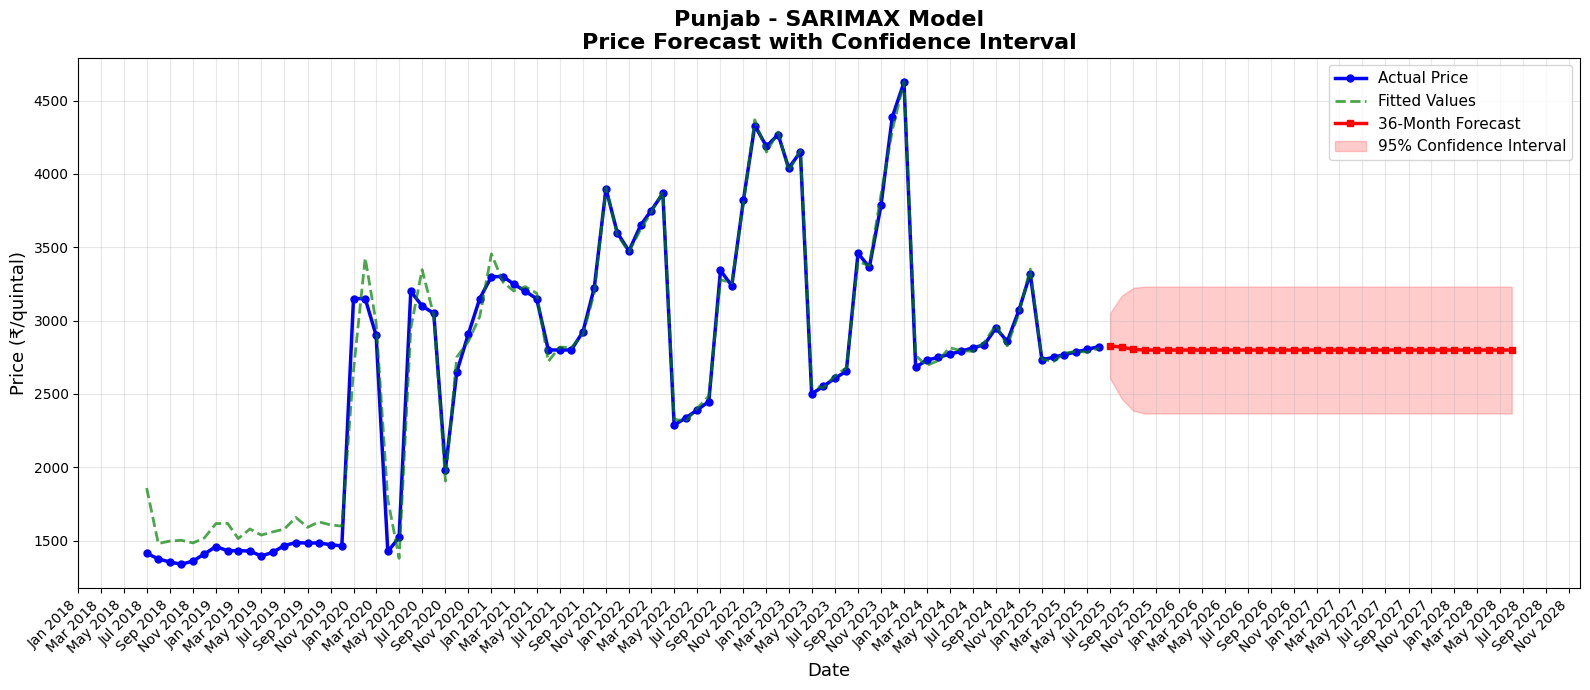



################################################################################
# GENERATING FORECASTS FOR UTAR PRADESH
################################################################################


********************************************************************************
* ARIMA MODEL FOR Utar Pradesh
********************************************************************************

Utar Pradesh - ARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jan 2025                      2269.13
            2 Feb 2025                      2263.54
            3 Mar 2025                      2265.12
            4 Apr 2025                      2272.88
            5 May 2025                      2284.35
            6 Jun 2025                      2296.33
            7 Jul 2025                      2305.76
            8 Aug 2025                      2310.47
            9 Sep 2025                      2309.67
           10 Oct 2025     

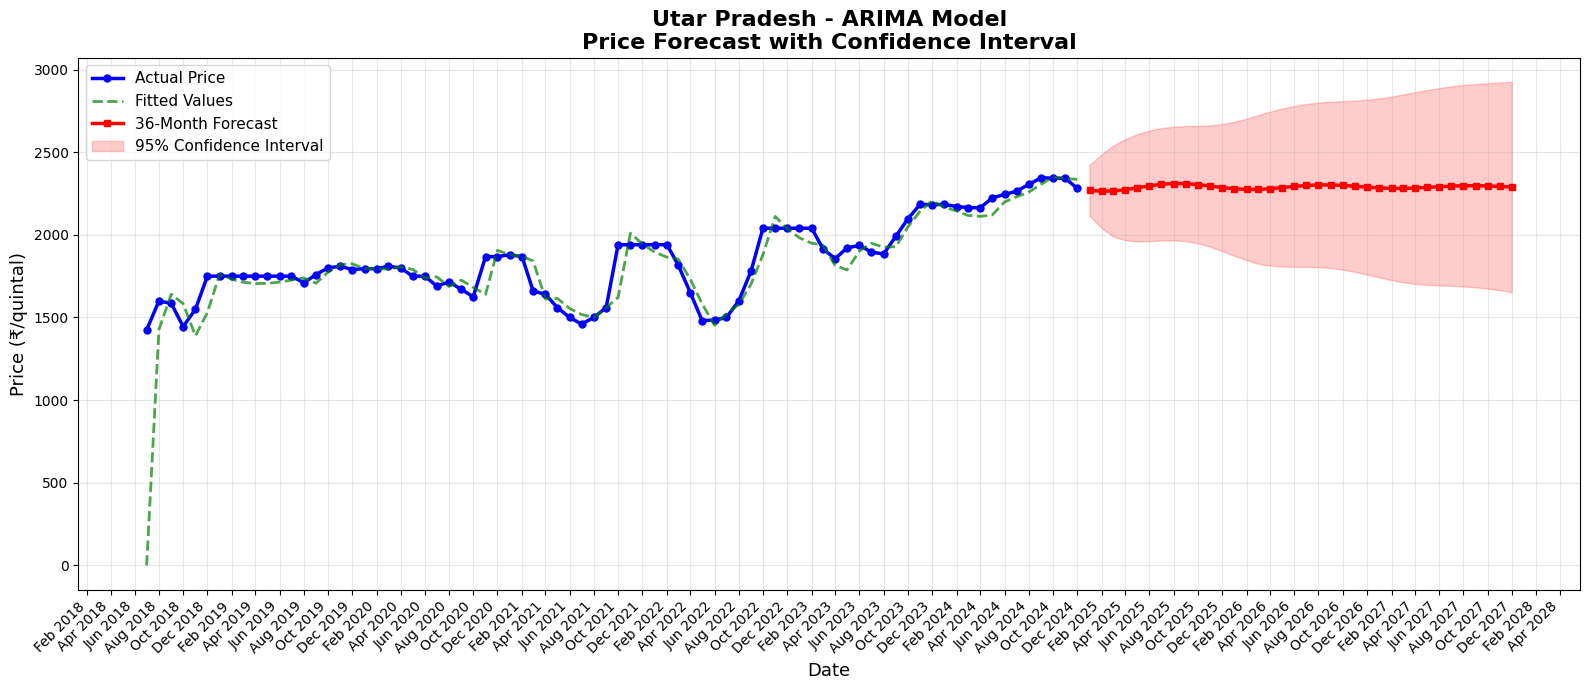


********************************************************************************
* SARIMA MODEL FOR Utar Pradesh
********************************************************************************

Utar Pradesh - SARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jan 2025                      2316.20
            2 Feb 2025                      2338.40
            3 Mar 2025                      2348.48
            4 Apr 2025                      2356.89
            5 May 2025                      2422.39
            6 Jun 2025                      2445.60
            7 Jul 2025                      2467.48
            8 Aug 2025                      2509.58
            9 Sep 2025                      2550.23
           10 Oct 2025                      2548.60
           11 Nov 2025                      2547.82
           12 Dec 2025                      2486.95
           13 Jan 2026                      2522.23
           14 Feb 2026

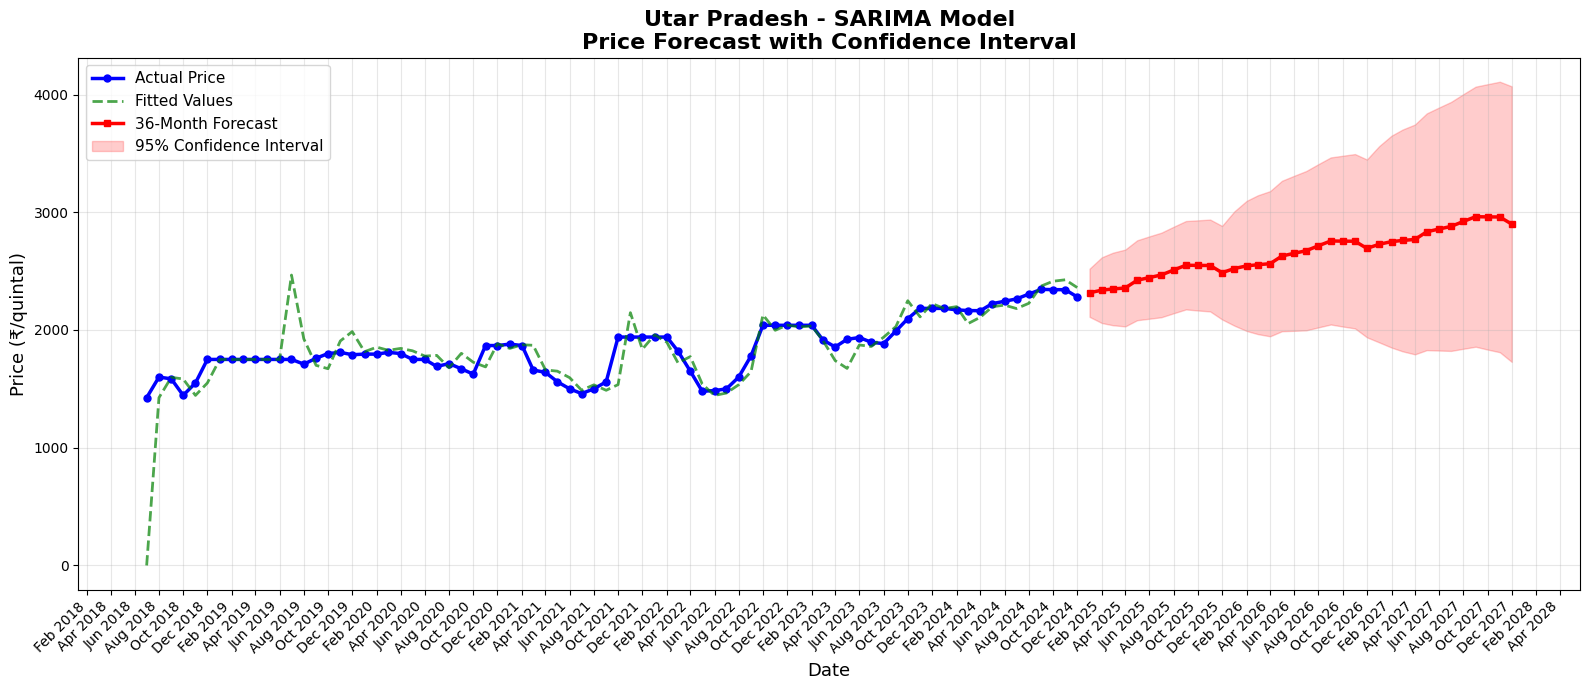


********************************************************************************
* SARIMAX MODEL FOR Utar Pradesh - SKIPPED
* Reason: No production data available for this state
********************************************************************************


################################################################################
# GENERATING FORECASTS FOR DELHI
################################################################################


********************************************************************************
* ARIMA MODEL FOR Delhi
********************************************************************************
  Skipping Delhi - ARIMA with params (6, 1, 6) due to LinAlgError during fitting.

********************************************************************************
* SARIMA MODEL FOR Delhi
********************************************************************************

Delhi - SARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Pri

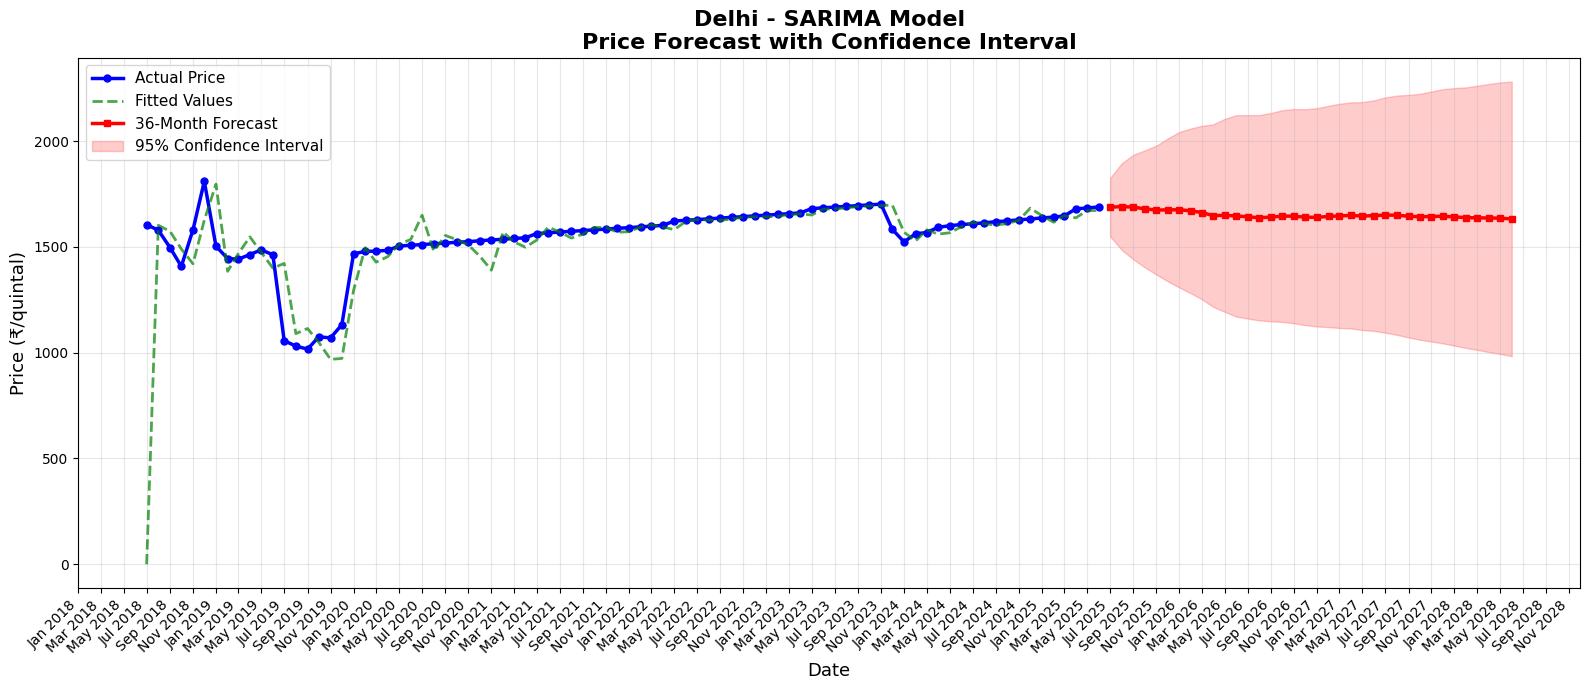


********************************************************************************
* SARIMAX MODEL FOR Delhi
********************************************************************************

Delhi - SARIMAX Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1691.91
            2 Aug 2025                      1688.07
            3 Sep 2025                      1684.66
            4 Oct 2025                      1680.30
            5 Nov 2025                      1675.36
            6 Dec 2025                      1701.12
            7 Jan 2026                      1710.08
            8 Feb 2026                      1697.41
            9 Mar 2026                      1692.52
           10 Apr 2026                      1666.98
           11 May 2026                      1658.29
           12 Jun 2026                      1653.28
           13 Jul 2026                      1652.44
           14 Aug 2026            

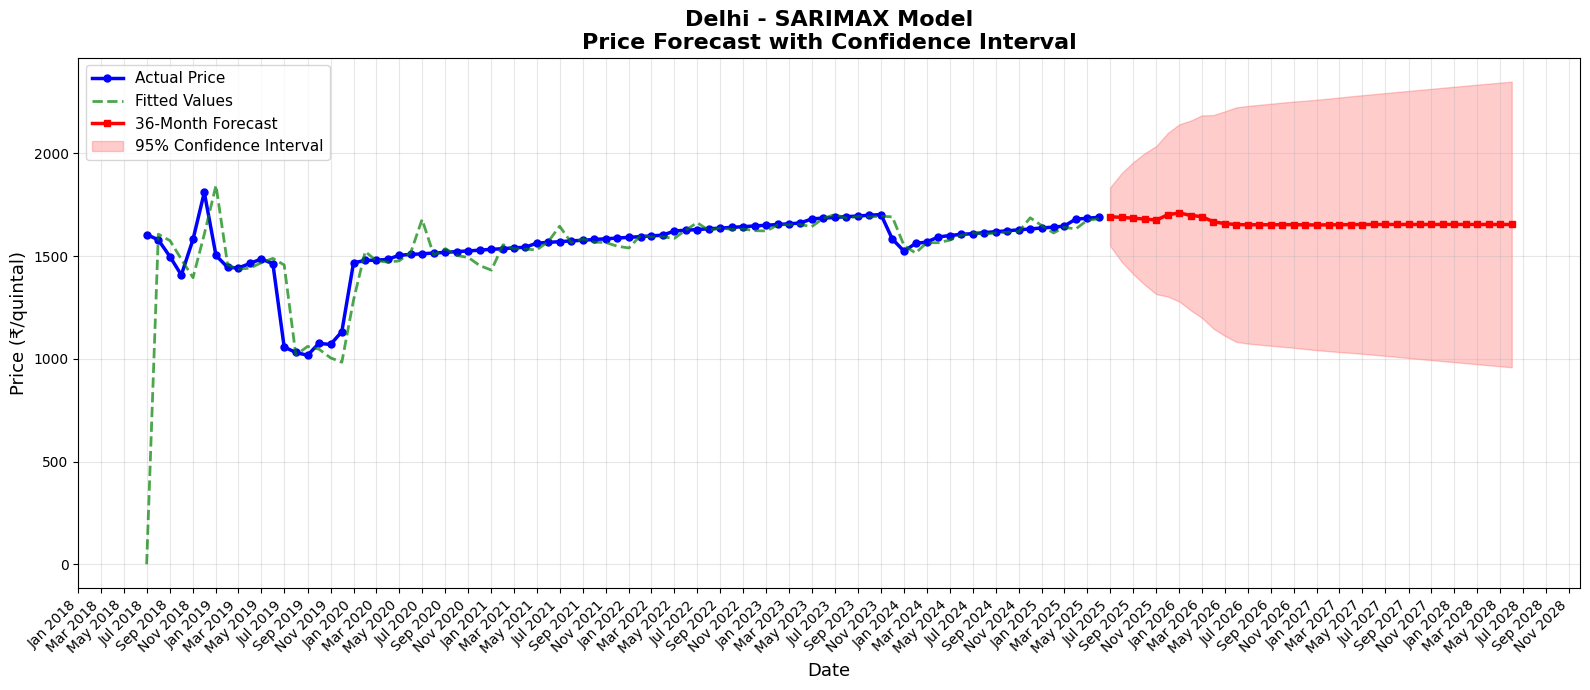



################################################################################
# GENERATING FORECASTS FOR WEST BENGAL
################################################################################


********************************************************************************
* ARIMA MODEL FOR West Bengal
********************************************************************************

West Bengal - ARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1931.46
            2 Aug 2025                      1918.05
            3 Sep 2025                      1944.84
            4 Oct 2025                      1937.18
            5 Nov 2025                      1943.99
            6 Dec 2025                      1943.99
            7 Jan 2026                      1943.99
            8 Feb 2026                      1943.99
            9 Mar 2026                      1943.99
           10 Apr 2026        

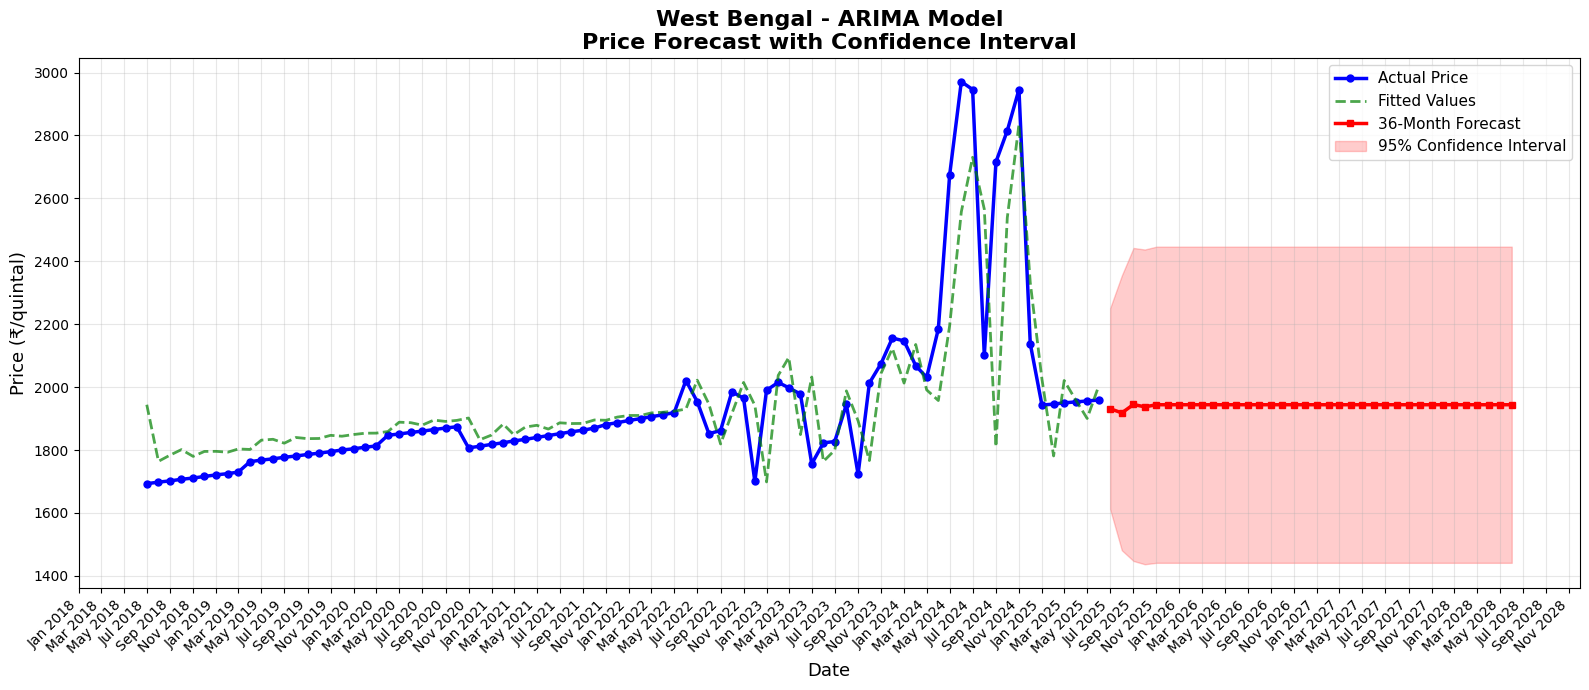


********************************************************************************
* SARIMA MODEL FOR West Bengal
********************************************************************************

West Bengal - SARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1823.67
            2 Aug 2025                      1677.88
            3 Sep 2025                      1645.02
            4 Oct 2025                      1850.58
            5 Nov 2025                      1863.28
            6 Dec 2025                      1710.03
            7 Jan 2026                      1727.24
            8 Feb 2026                      1693.20
            9 Mar 2026                      1672.20
           10 Apr 2026                      1733.35
           11 May 2026                      1957.46
           12 Jun 2026                      2180.27
           13 Jul 2026                      2187.50
           14 Aug 2026  

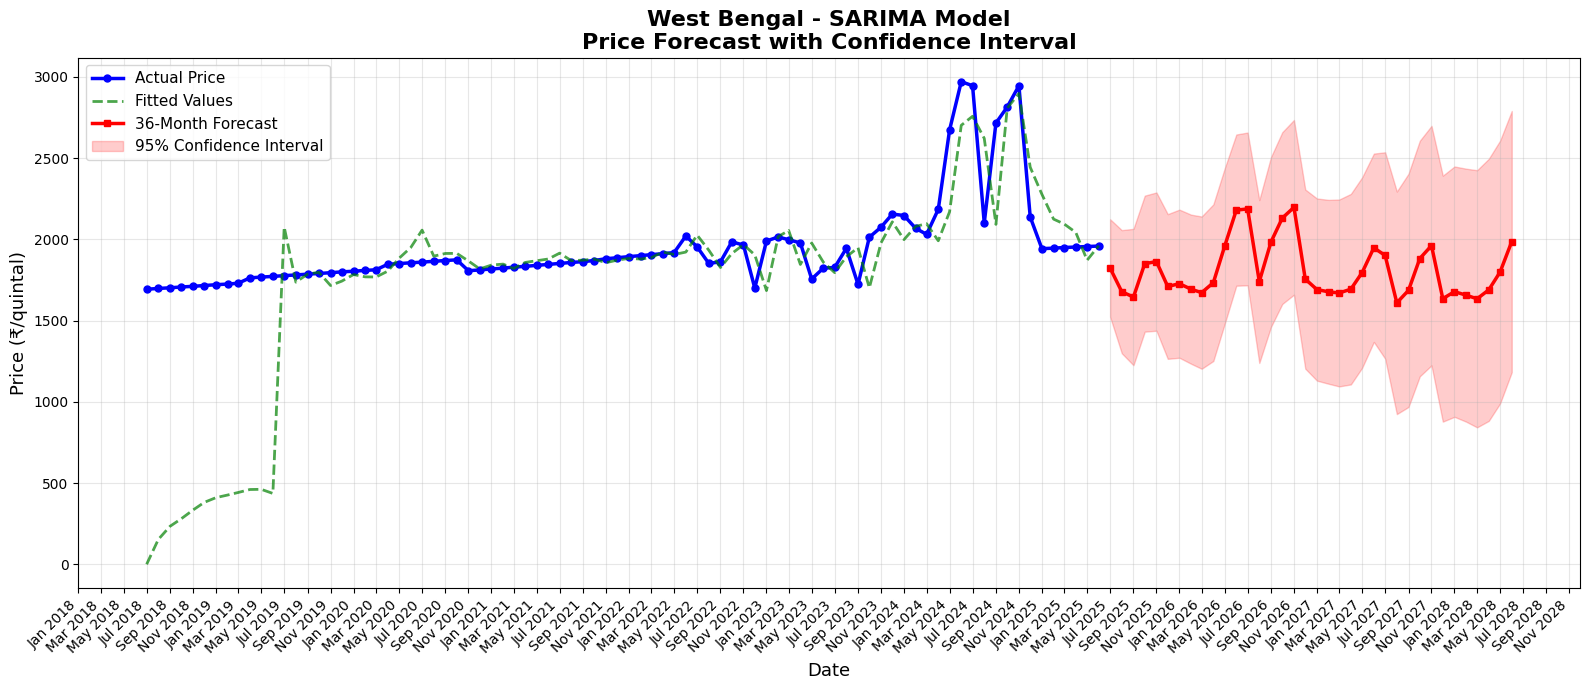


********************************************************************************
* SARIMAX MODEL FOR West Bengal
********************************************************************************

West Bengal - SARIMAX Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      2055.72
            2 Aug 2025                      1807.89
            3 Sep 2025                      2106.69
            4 Oct 2025                      2319.69
            5 Nov 2025                      2443.36
            6 Dec 2025                      2126.45
            7 Jan 2026                      2027.93
            8 Feb 2026                      1989.31
            9 Mar 2026                      1984.48
           10 Apr 2026                      2064.58
           11 May 2026                      2316.33
           12 Jun 2026                      2473.51
           13 Jul 2026                      2508.07
           14 Aug 2026

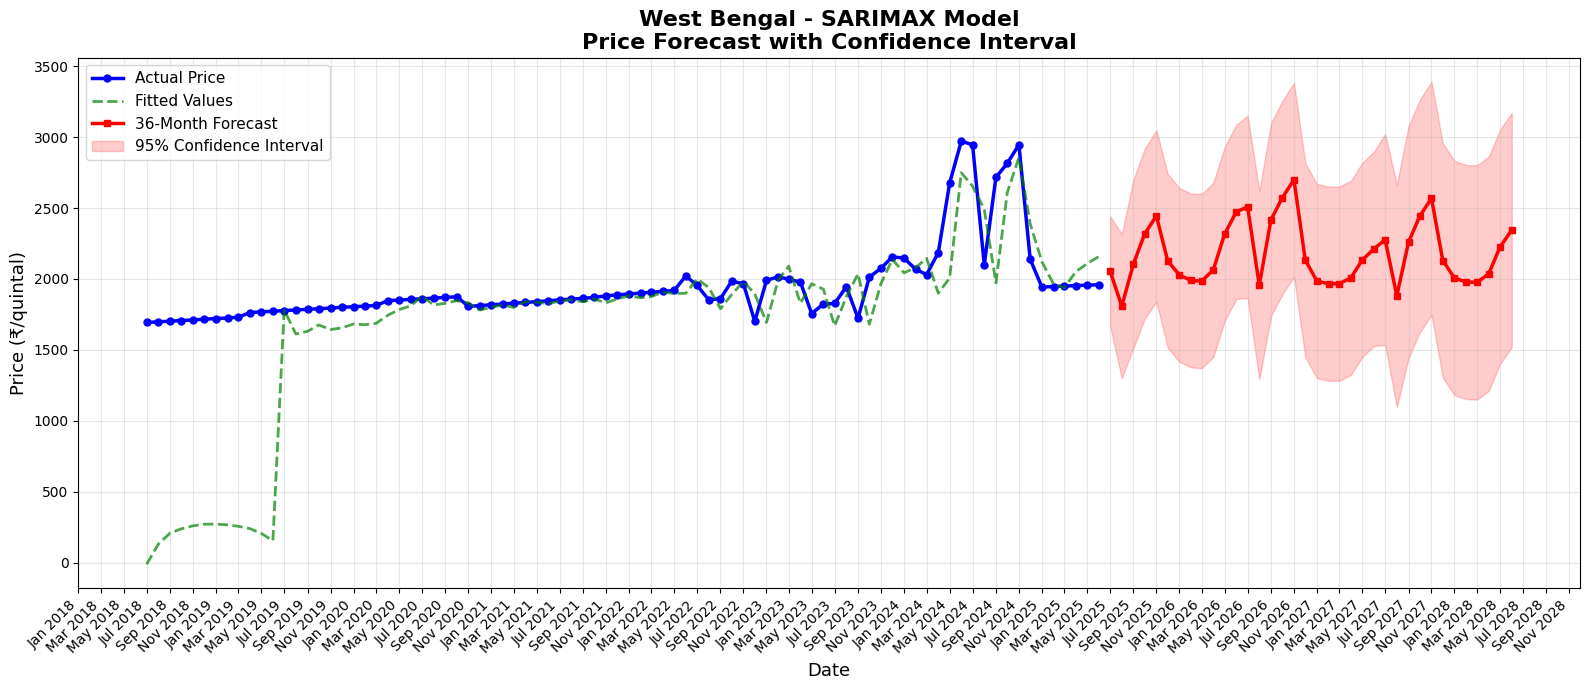



################################################################################
# GENERATING FORECASTS FOR TAMIL NADU
################################################################################


********************************************************************************
* ARIMA MODEL FOR Tamil Nadu
********************************************************************************

Tamil Nadu - ARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1783.62
            2 Aug 2025                      1797.52
            3 Sep 2025                      1892.88
            4 Oct 2025                      1967.73
            5 Nov 2025                      1948.17
            6 Dec 2025                      1847.80
            7 Jan 2026                      1756.29
            8 Feb 2026                      1760.90
            9 Mar 2026                      1809.84
           10 Apr 2026           

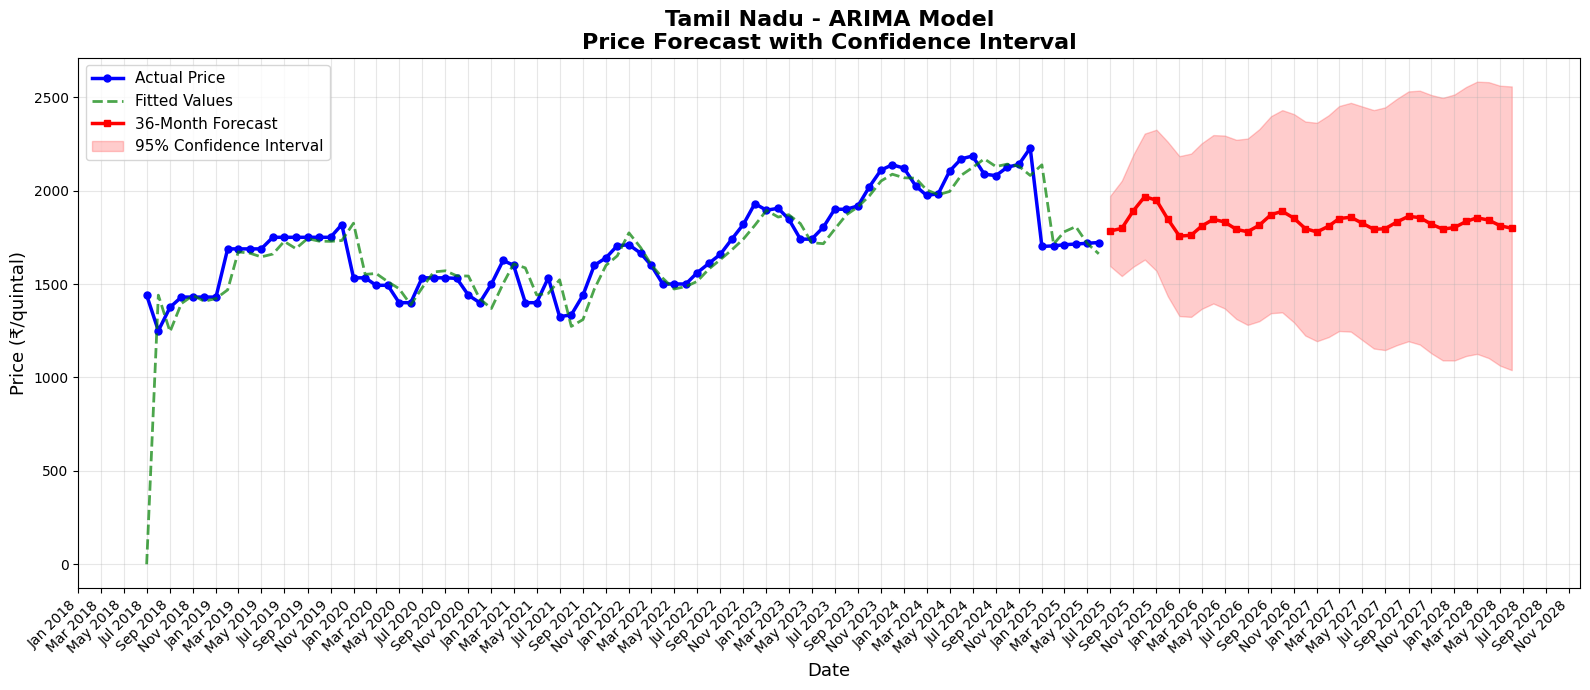


********************************************************************************
* SARIMA MODEL FOR Tamil Nadu
********************************************************************************

Tamil Nadu - SARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1844.48
            2 Aug 2025                      1744.12
            3 Sep 2025                      1753.68
            4 Oct 2025                      1910.41
            5 Nov 2025                      1965.33
            6 Dec 2025                      2016.81
            7 Jan 2026                      1543.82
            8 Feb 2026                      1627.26
            9 Mar 2026                      1602.62
           10 Apr 2026                      1587.32
           11 May 2026                      1669.91
           12 Jun 2026                      1693.92
           13 Jul 2026                      1758.33
           14 Aug 2026    

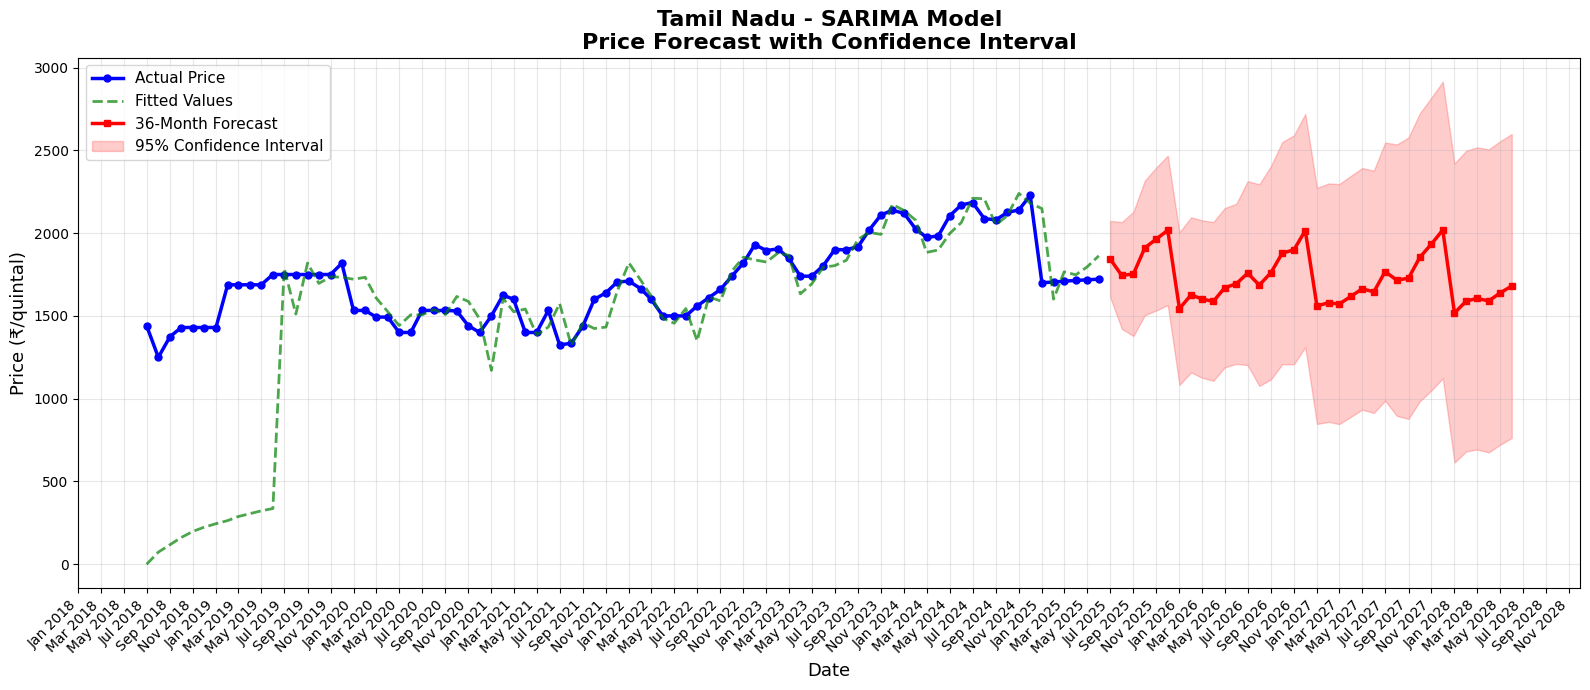


********************************************************************************
* SARIMAX MODEL FOR Tamil Nadu
********************************************************************************

Tamil Nadu - SARIMAX Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1847.35
            2 Aug 2025                      1750.93
            3 Sep 2025                      1756.96
            4 Oct 2025                      1900.21
            5 Nov 2025                      1955.74
            6 Dec 2025                      2012.81
            7 Jan 2026                      1523.57
            8 Feb 2026                      1601.31
            9 Mar 2026                      1582.72
           10 Apr 2026                      1568.99
           11 May 2026                      1644.37
           12 Jun 2026                      1670.68
           13 Jul 2026                      1746.25
           14 Aug 2026  

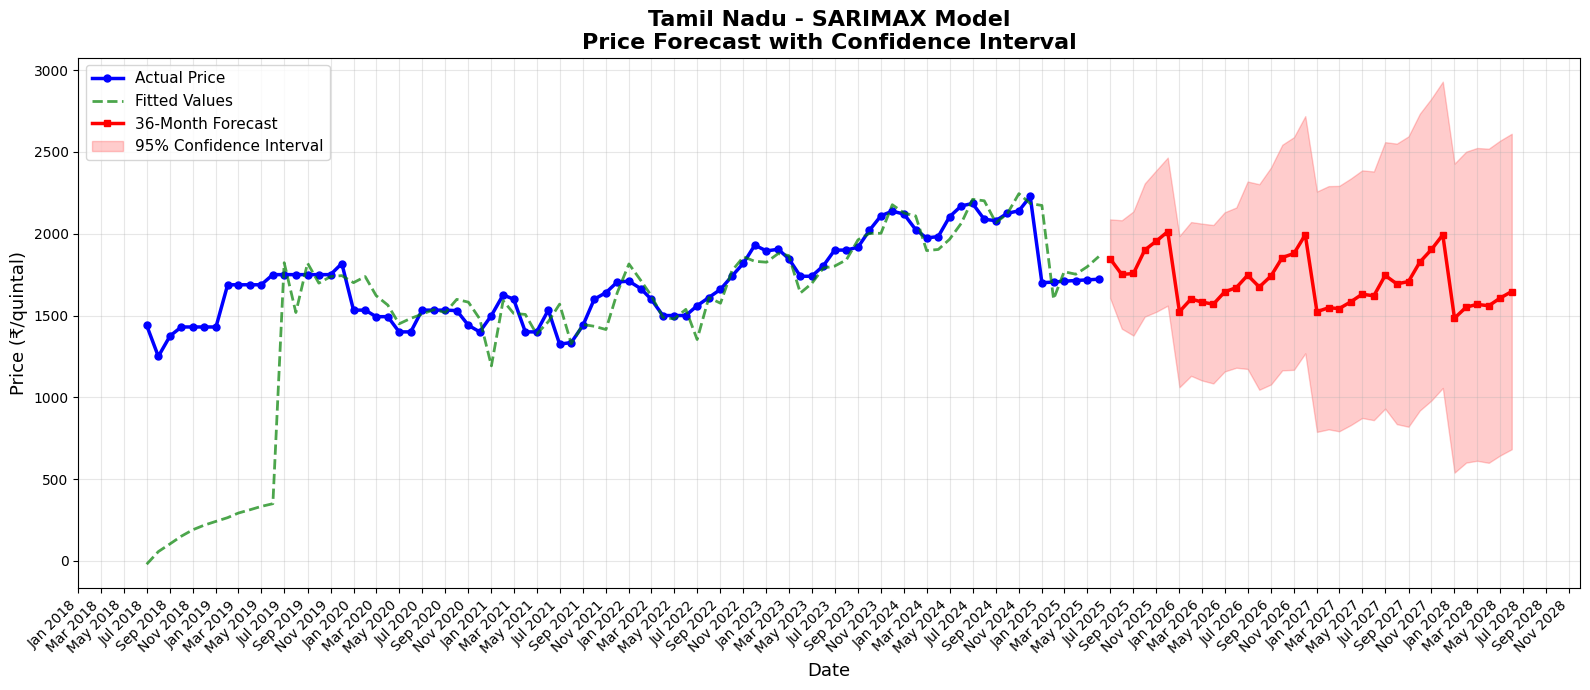



################################################################################
# ALL VISUALIZATIONS AND FORECASTS GENERATED SUCCESSFULLY!
################################################################################



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator, DateFormatter
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('/content/paddy_price_production.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%Y')
df = df.sort_values('Date').reset_index(drop=True)

# Store the best model parameters from previous grid search
best_params = {
    'Punjab': {'ARIMA': (1,1,4), 'SARIMA': (2, 0, 4, 2, 1, 2), 'SARIMAX': (0, 0, 3, 0, 0, 0)},
    'Utar Pradesh': {'ARIMA': (2, 1, 2), 'SARIMA': (1, 1, 3, 0, 1, 0), 'SARIMAX': None},
    'Delhi': {'ARIMA': (6, 1, 6), 'SARIMA': (3, 0, 2, 1, 0, 0), 'SARIMAX': (1, 1, 0, 1, 0, 1)},
    'West Bengal': {'ARIMA': (0, 0, 4), 'SARIMA': (3, 0, 3, 10, 1, 2), 'SARIMAX': (3, 0, 3, 1, 1, 0)},
    'Tamil Nadu': {'ARIMA': (8, 1, 2), 'SARIMA': (4, 0, 3, 0, 1, 0), 'SARIMAX': (3, 0, 2, 0, 1, 0)}
}

states = df['State'].unique()

def plot_forecast_with_confidence(state, model_type, best_param, price_series, production_series=None, exog_forecast=None):
    """
    Create a comprehensive forecast plot with actual, fitted, forecast, and confidence intervals
    """

    # Train model on full data
    model_fit = None  # Initialize model_fit to None
    try:
        if model_type == 'ARIMA':
            model = ARIMA(price_series, order=best_param)
            model_fit = model.fit()

        elif model_type == 'SARIMA':
            model = SARIMAX(price_series, order=best_param[:3], seasonal_order=best_param[3:] + (12,))
            model_fit = model.fit(disp=False)

        elif model_type == 'SARIMAX' and best_param is not None:
            if production_series is None or exog_forecast is None:
                return None, None, None, None  # Skip if no exog data

            model = SARIMAX(price_series, order=best_param[:3], seasonal_order=best_param[3:] + (12,), exog=production_series)
            model_fit = model.fit(disp=False)
        else:
            return None, None, None, None # Invalid model type

    except np.linalg.LinAlgError:
        print(f"  Skipping {state} - {model_type} with params {best_param} due to LinAlgError during fitting.")
        return None, None, None, None # Return None if fitting fails

    if model_fit is not None:
        # Get fitted values
        fitted_values = model_fit.fittedvalues

        # Forecast 36 months with confidence interval
        forecast_result = model_fit.get_forecast(steps=36, exog=exog_forecast if model_type == 'SARIMAX' else None)
        forecast_mean = forecast_result.predicted_mean
        forecast_ci = forecast_result.conf_int()

        # figure
        fig, ax = plt.subplots(figsize=(16, 7))
        ax.plot(price_series.index, price_series.values, 'b-', linewidth=2.5, label='Actual Price', marker='o', markersize=5)
        ax.plot(fitted_values.index, fitted_values.values, 'g--', linewidth=2, alpha=0.7, label='Fitted Values')
        last_date = price_series.index[-1]
        future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=36, freq='MS')
        ax.plot(future_dates, forecast_mean.values, 'r-', linewidth=2.5, label='36-Month Forecast', marker='s', markersize=5)
        ax.fill_between(future_dates,
                         forecast_ci.iloc[:, 0].values,
                         forecast_ci.iloc[:, 1].values,
                         color='red', alpha=0.2, label='95% Confidence Interval')
        ax.xaxis.set_major_locator(MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))

        # Formatting
        ax.set_title(f'{state} - {model_type} Model\nPrice Forecast with Confidence Interval', fontsize=16, fontweight='bold')
        ax.set_xlabel('Date', fontsize=13)
        ax.set_ylabel('Price (₹/quintal)', fontsize=13)
        ax.legend(loc='best', fontsize=11)
        ax.grid(True, alpha=0.3)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()

        return fig, model_fit, forecast_mean, forecast_ci, future_dates

    return None, None, None, None


def display_predictions_table(forecast_mean, future_dates, state, model_type):
    """
    Display predictions in a formatted table
    """
    print(f"\n{'='*80}")
    print(f"{state} - {model_type} Model: 36-Month Price Forecasts")
    print(f"{'='*80}")


    forecast_df = pd.DataFrame({
        'Month': future_dates.strftime('%b %Y'),
        'Predicted Price (₹/quintal)': forecast_mean.values.round(2)
    })
    forecast_df['Month_Number'] = range(1, 37)
    forecast_df = forecast_df[['Month_Number', 'Month', 'Predicted Price (₹/quintal)']]
    print(forecast_df.to_string(index=False))
    print(f"{'='*80}\n")
    return forecast_df

# Generate plots and predictions for all states and models
plot_results = {}

for state in states:
    print(f"\n\n{'#'*80}")
    print(f"# GENERATING FORECASTS FOR {state.upper()}")
    print(f"{'#'*80}\n")

    state_df = df[df['State'] == state].sort_values('Date').copy()
    state_df.set_index('Date', inplace=True)
    price_series = state_df['Prices'].dropna()
    price_series.index.freq = 'MS'
    production_series = state_df['Production'].dropna()
    production_series.index.freq = 'MS'

    state_plots = {}
    state_forecasts = {}

    #  ARIMA
    print(f"\n{'*'*80}")
    print(f"* ARIMA MODEL FOR {state}")
    print(f"{'*'*80}")

    arima_param = best_params[state]['ARIMA']
    result = plot_forecast_with_confidence(
        state, 'ARIMA', arima_param, price_series
    )
    if result[0] is not None:
        fig_arima, model_arima, forecast_arima, ci_arima, future_dates_arima = result

        # Display predictions table
        forecast_df_arima = display_predictions_table(forecast_arima, future_dates_arima, state, 'ARIMA')

        # Display graph
        plt.show()

        state_plots['ARIMA'] = {
            'figure': fig_arima,
            'model': model_arima,
            'forecast': forecast_arima,
            'ci': ci_arima
        }
        state_forecasts['ARIMA'] = forecast_df_arima

    # SARIMA
    print(f"\n{'*'*80}")
    print(f"* SARIMA MODEL FOR {state}")
    print(f"{'*'*80}")

    sarima_param = best_params[state]['SARIMA']
    result = plot_forecast_with_confidence(
        state, 'SARIMA', sarima_param, price_series
    )
    if result[0] is not None:
        fig_sarima, model_sarima, forecast_sarima, ci_sarima, future_dates_sarima = result

        # Display predictions table
        forecast_df_sarima = display_predictions_table(forecast_sarima, future_dates_sarima, state, 'SARIMA')

        # Display graph
        plt.show()

        state_plots['SARIMA'] = {
            'figure': fig_sarima,
            'model': model_sarima,
            'forecast': forecast_sarima,
            'ci': ci_sarima
        }
        state_forecasts['SARIMA'] = forecast_df_sarima

    #  SARIMAX
    sarimax_param = best_params[state]['SARIMAX']
    if sarimax_param is not None:
        print(f"\n{'*'*80}")
        print(f"* SARIMAX MODEL FOR {state}")
        print(f"{'*'*80}")

        if len(production_series) == len(price_series):
            exog_forecast = np.array([[production_series.values[-1]]] * 36)
            result = plot_forecast_with_confidence(
                state, 'SARIMAX', sarimax_param, price_series,
                production_series=production_series,
                exog_forecast=exog_forecast
            )
            if result[0] is not None:
                fig_sarimax, model_sarimax, forecast_sarimax, ci_sarimax, future_dates_sarimax = result

                # Display predictions table
                forecast_df_sarimax = display_predictions_table(forecast_sarimax, future_dates_sarimax, state, 'SARIMAX')

                # Display graph
                plt.show()

                state_plots['SARIMAX'] = {
                    'figure': fig_sarimax,
                    'model': model_sarimax,
                    'forecast': forecast_sarimax,
                    'ci': ci_sarimax
                }
                state_forecasts['SARIMAX'] = forecast_df_sarimax
    else:
        print(f"\n{'*'*80}")
        print(f"* SARIMAX MODEL FOR {state} - SKIPPED")
        print(f"* Reason: No production data available for this state")
        print(f"{'*'*80}")


    plot_results[state] = {
        'plots': state_plots,
        'forecasts': state_forecasts
    }

print(f"\n\n{'#'*80}")
print(f"# ALL VISUALIZATIONS AND FORECASTS GENERATED SUCCESSFULLY!")
print(f"{'#'*80}\n")

3rd iteration




################################################################################
# GENERATING FORECASTS FOR PUNJAB
################################################################################


********************************************************************************
* ARIMA MODEL FOR Punjab
********************************************************************************

Punjab - ARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      2848.82
            2 Aug 2025                      2900.94
            3 Sep 2025                      2869.67
            4 Oct 2025                      2897.14
            5 Nov 2025                      2876.62
            6 Dec 2025                      2891.95
            7 Jan 2026                      2880.50
            8 Feb 2026                      2889.06
            9 Mar 2026                      2882.66
           10 Apr 2026                      2

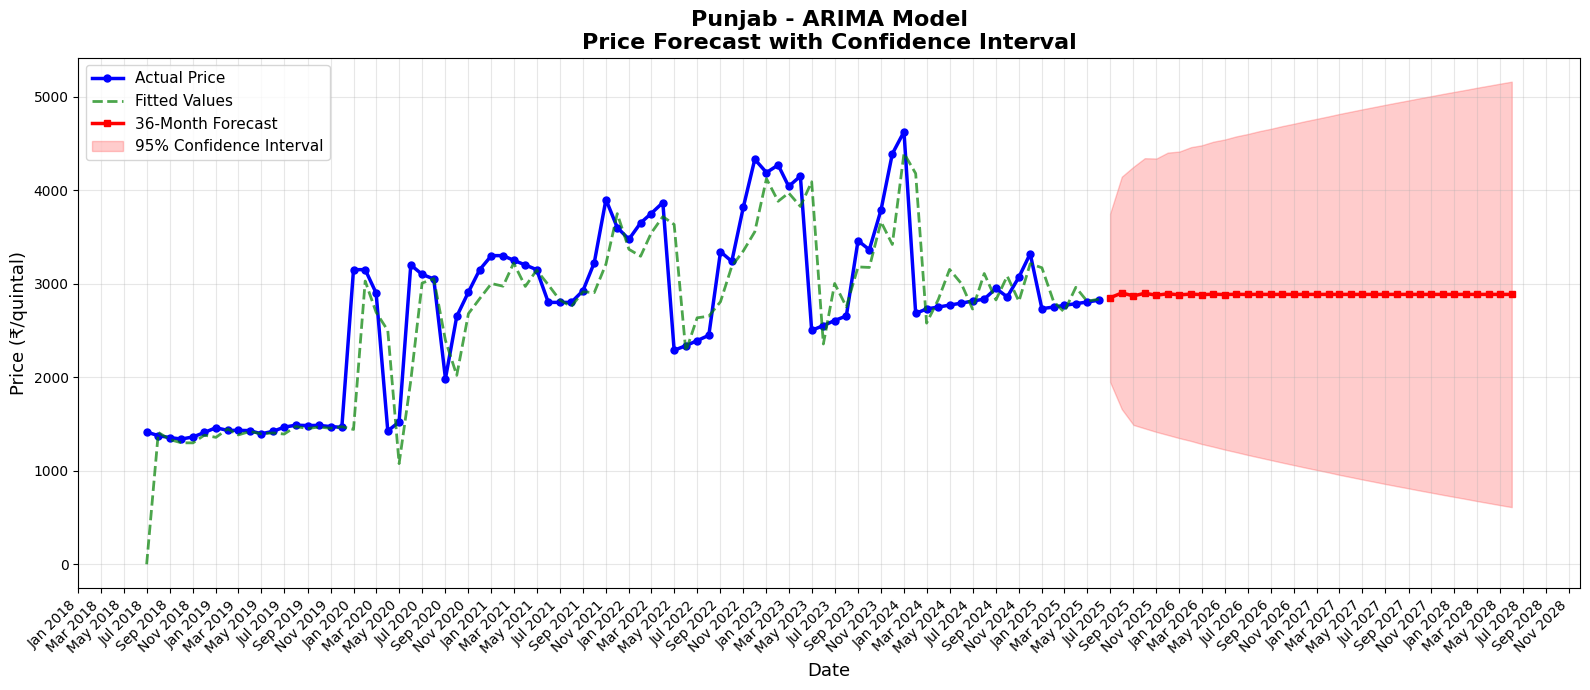


********************************************************************************
* SARIMA MODEL FOR Punjab
********************************************************************************

Punjab - SARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      2507.17
            2 Aug 2025                      2354.33
            3 Sep 2025                      2404.33
            4 Oct 2025                      2416.93
            5 Nov 2025                      2649.17
            6 Dec 2025                      2795.35
            7 Jan 2026                      2795.33
            8 Feb 2026                      2514.68
            9 Mar 2026                      2384.88
           10 Apr 2026                      2193.54
           11 May 2026                      1684.54
           12 Jun 2026                      1740.83
           13 Jul 2026                      1682.65
           14 Aug 2026            

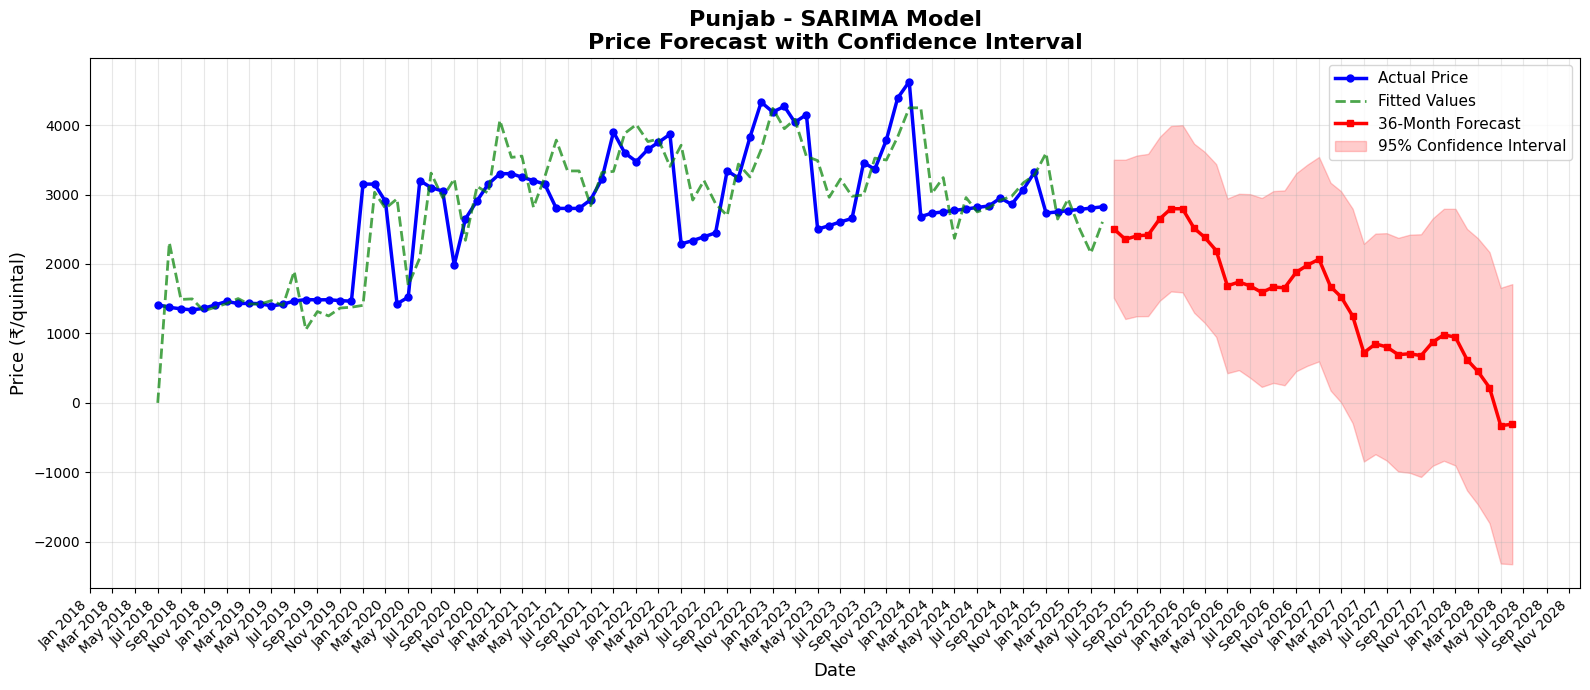


********************************************************************************
* SARIMAX MODEL FOR Punjab
********************************************************************************

Punjab - SARIMAX Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      2831.17
            2 Aug 2025                      2822.46
            3 Sep 2025                      2808.25
            4 Oct 2025                      2805.78
            5 Nov 2025                      2808.24
            6 Dec 2025                      2807.06
            7 Jan 2026                      2805.32
            8 Feb 2026                      2806.03
            9 Mar 2026                      2806.48
           10 Apr 2026                      2806.84
           11 May 2026                      2807.29
           12 Jun 2026                      2807.92
           13 Jul 2026                      2808.62
           14 Aug 2026          

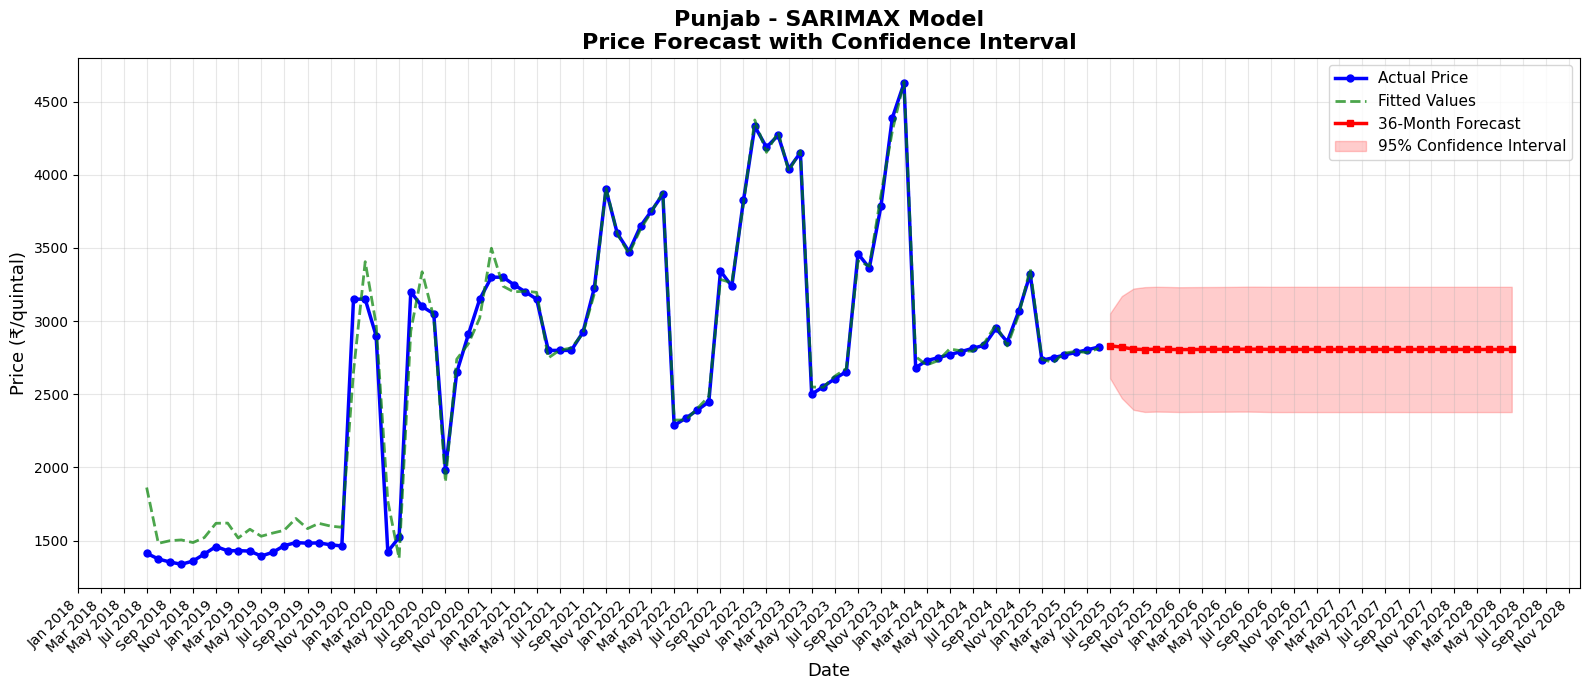



################################################################################
# GENERATING FORECASTS FOR UTAR PRADESH
################################################################################


********************************************************************************
* ARIMA MODEL FOR Utar Pradesh
********************************************************************************

Utar Pradesh - ARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jan 2025                      2269.13
            2 Feb 2025                      2263.54
            3 Mar 2025                      2265.12
            4 Apr 2025                      2272.88
            5 May 2025                      2284.35
            6 Jun 2025                      2296.33
            7 Jul 2025                      2305.76
            8 Aug 2025                      2310.47
            9 Sep 2025                      2309.67
           10 Oct 2025     

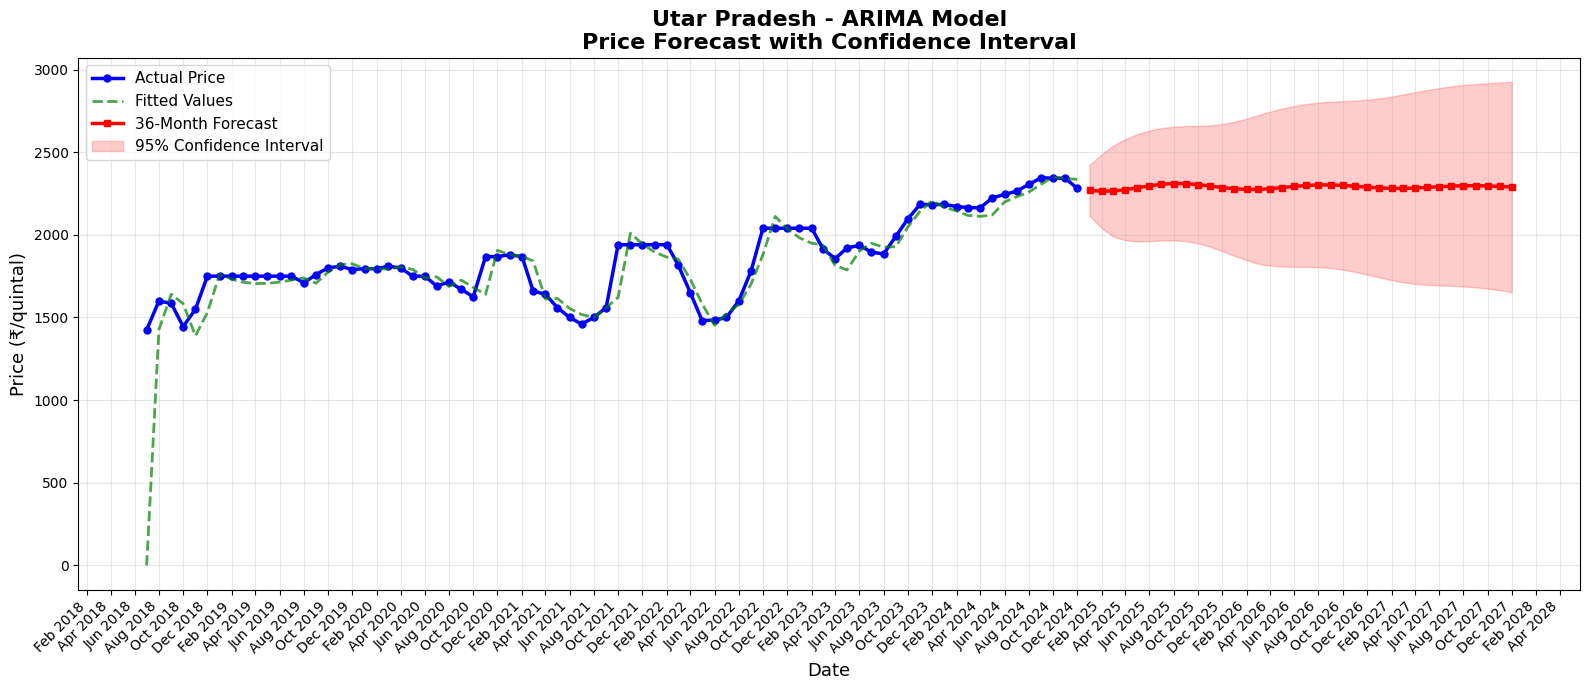


********************************************************************************
* SARIMA MODEL FOR Utar Pradesh
********************************************************************************

Utar Pradesh - SARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jan 2025                      2325.75
            2 Feb 2025                      2358.18
            3 Mar 2025                      2375.91
            4 Apr 2025                      2383.77
            5 May 2025                      2435.08
            6 Jun 2025                      2446.40
            7 Jul 2025                      2457.72
            8 Aug 2025                      2490.04
            9 Sep 2025                      2521.36
           10 Oct 2025                      2510.68
           11 Nov 2025                      2501.00
           12 Dec 2025                      2431.31
           13 Jan 2026                      2467.39
           14 Feb 2026

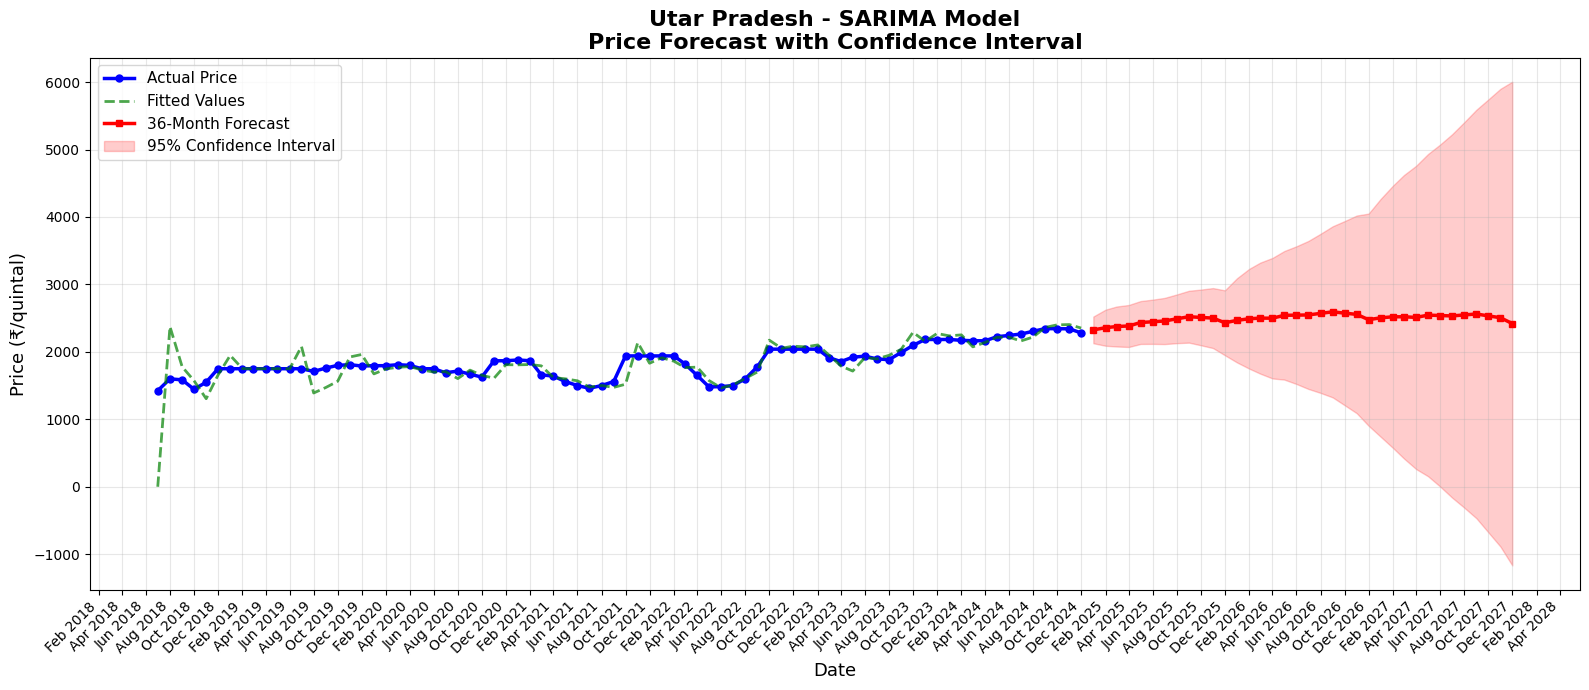


********************************************************************************
* SARIMAX MODEL FOR Utar Pradesh - SKIPPED
* Reason: No production data available for this state
********************************************************************************


################################################################################
# GENERATING FORECASTS FOR DELHI
################################################################################


********************************************************************************
* ARIMA MODEL FOR Delhi
********************************************************************************

Delhi - ARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1705.77
            2 Aug 2025                      1721.60
            3 Sep 2025                      1708.04
            4 Oct 2025                      1686.44
            5 Nov 2025                      1697

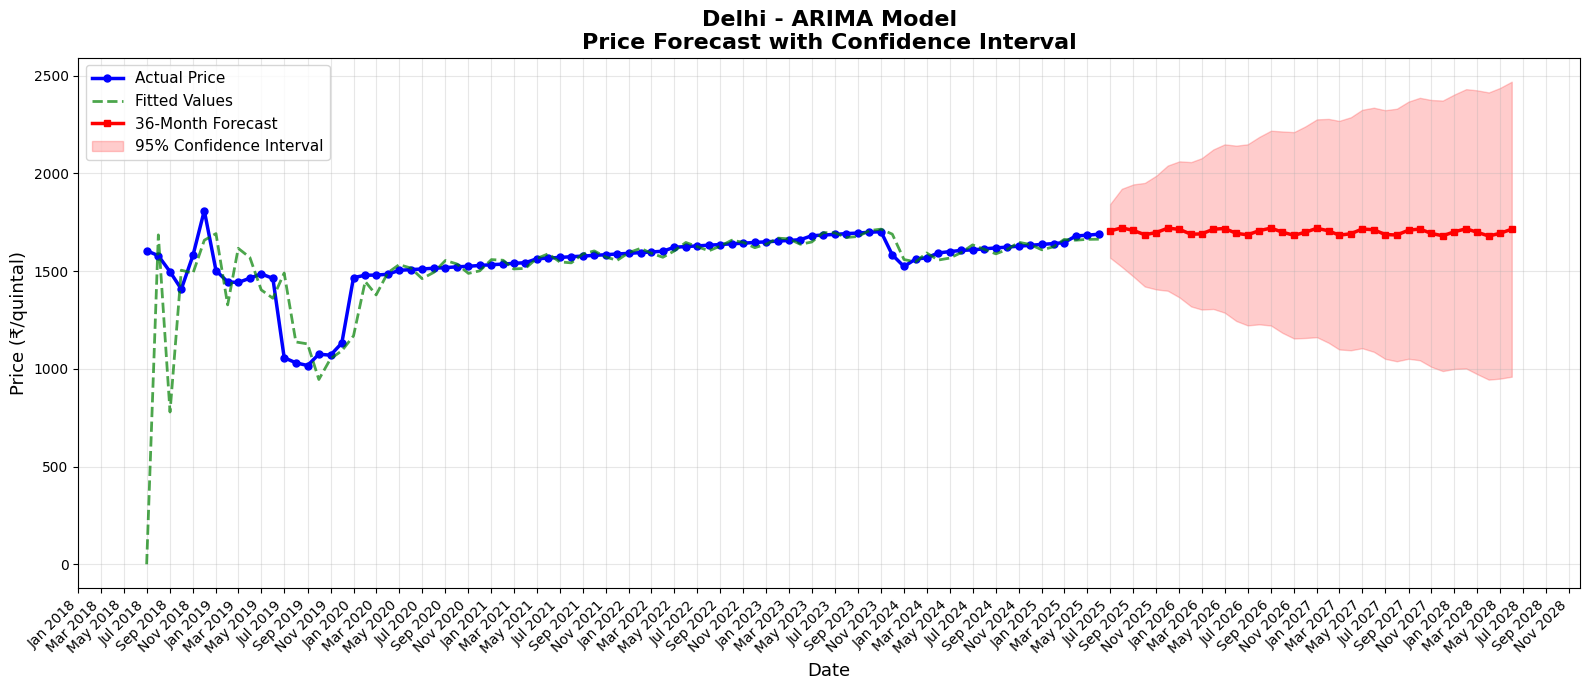


********************************************************************************
* SARIMA MODEL FOR Delhi
********************************************************************************

Delhi - SARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1686.33
            2 Aug 2025                      1681.23
            3 Sep 2025                      1677.61
            4 Oct 2025                      1674.96
            5 Nov 2025                      1671.67
            6 Dec 2025                      1668.70
            7 Jan 2026                      1665.30
            8 Feb 2026                      1662.37
            9 Mar 2026                      1658.99
           10 Apr 2026                      1642.75
           11 May 2026                      1639.81
           12 Jun 2026                      1636.44
           13 Jul 2026                      1636.47
           14 Aug 2026              

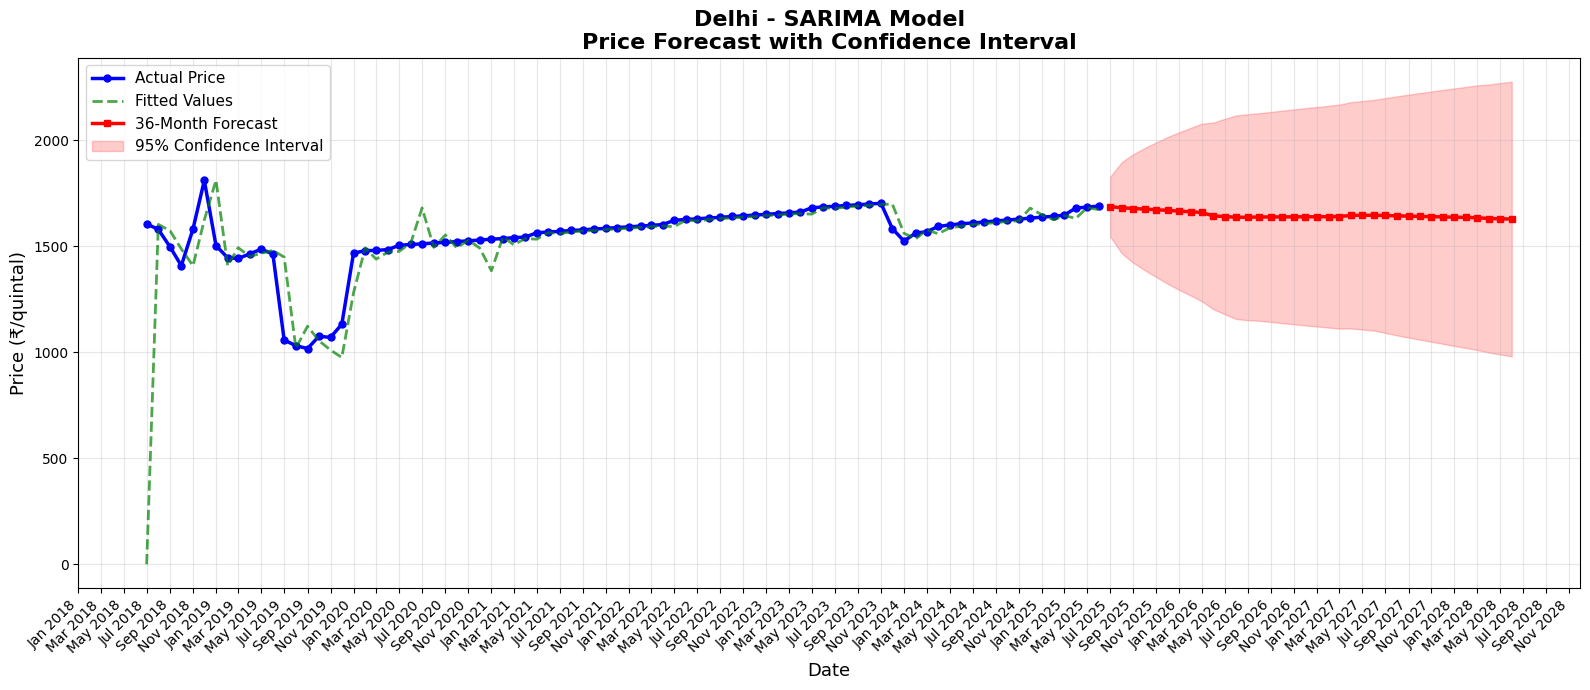


********************************************************************************
* SARIMAX MODEL FOR Delhi
********************************************************************************

Delhi - SARIMAX Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1691.91
            2 Aug 2025                      1688.07
            3 Sep 2025                      1684.66
            4 Oct 2025                      1680.30
            5 Nov 2025                      1675.36
            6 Dec 2025                      1701.12
            7 Jan 2026                      1710.08
            8 Feb 2026                      1697.41
            9 Mar 2026                      1692.52
           10 Apr 2026                      1666.98
           11 May 2026                      1658.29
           12 Jun 2026                      1653.28
           13 Jul 2026                      1652.44
           14 Aug 2026            

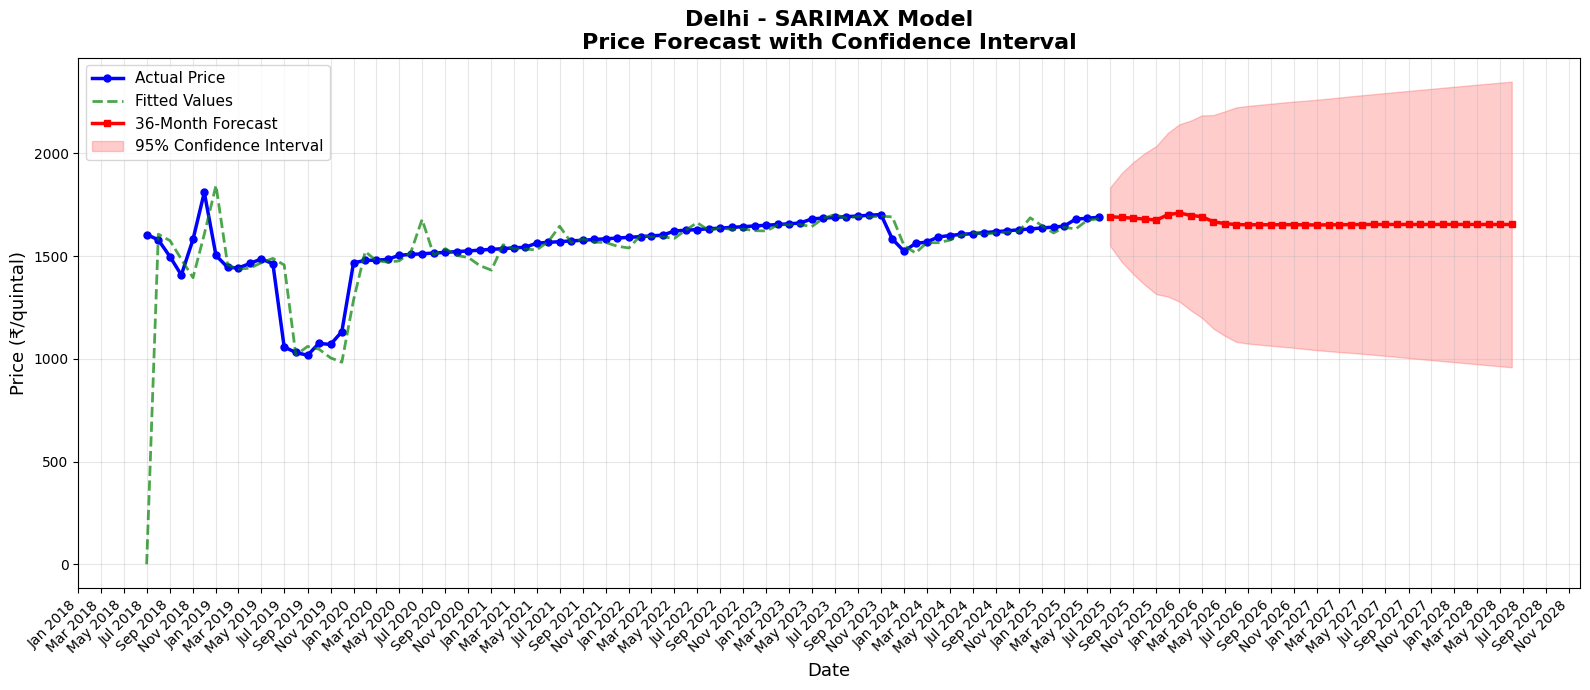



################################################################################
# GENERATING FORECASTS FOR WEST BENGAL
################################################################################


********************************************************************************
* ARIMA MODEL FOR West Bengal
********************************************************************************

West Bengal - ARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1588.63
            2 Aug 2025                      1931.40
            3 Sep 2025                      2257.80
            4 Oct 2025                      2525.09
            5 Nov 2025                      1872.11
            6 Dec 2025                      2249.70
            7 Jan 2026                      2496.76
            8 Feb 2026                      2997.98
            9 Mar 2026                      2559.07
           10 Apr 2026        

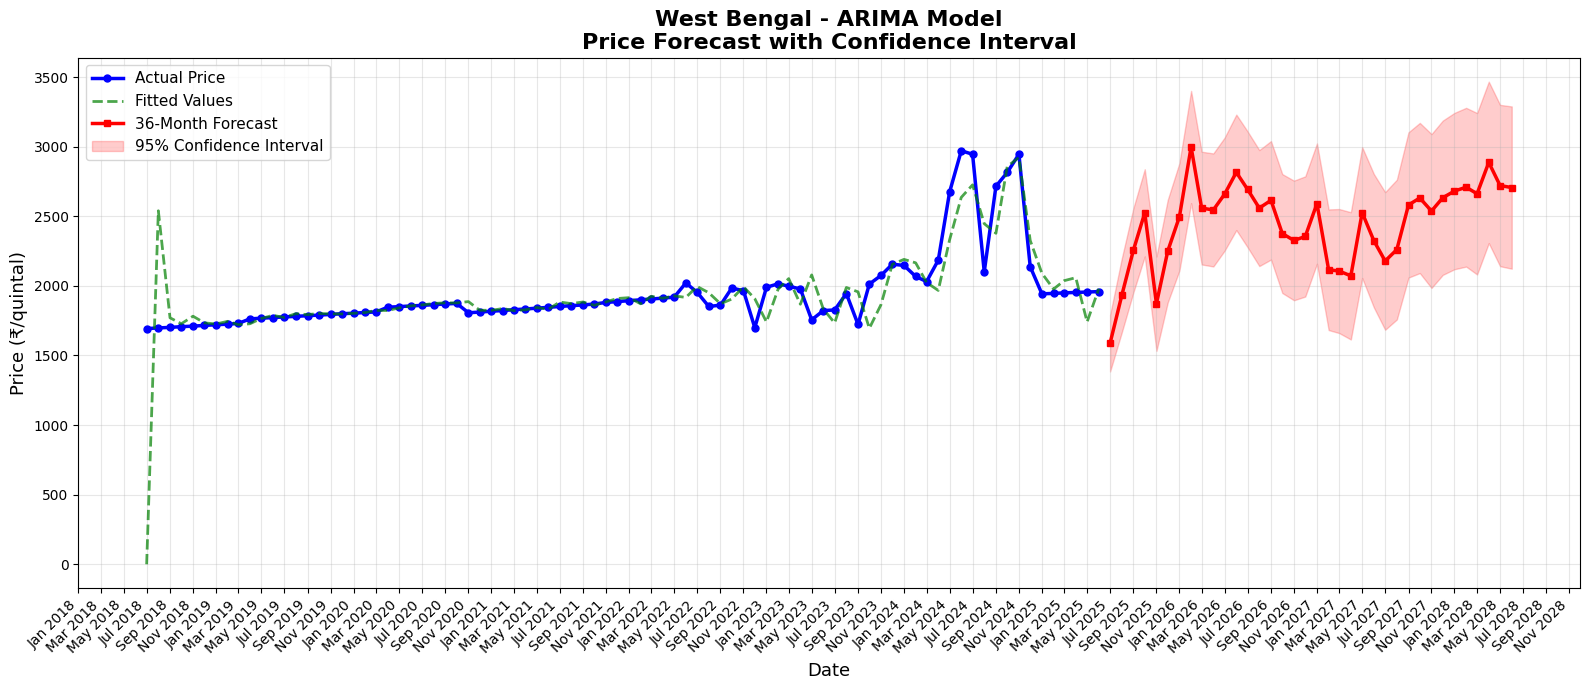


********************************************************************************
* SARIMA MODEL FOR West Bengal
********************************************************************************

West Bengal - SARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      2155.79
            2 Aug 2025                      2070.22
            3 Sep 2025                      2125.14
            4 Oct 2025                      2323.92
            5 Nov 2025                      2380.95
            6 Dec 2025                      2266.30
            7 Jan 2026                      2240.52
            8 Feb 2026                      2205.97
            9 Mar 2026                      2193.44
           10 Apr 2026                      2313.97
           11 May 2026                      2681.33
           12 Jun 2026                      2898.08
           13 Jul 2026                      2914.07
           14 Aug 2026  

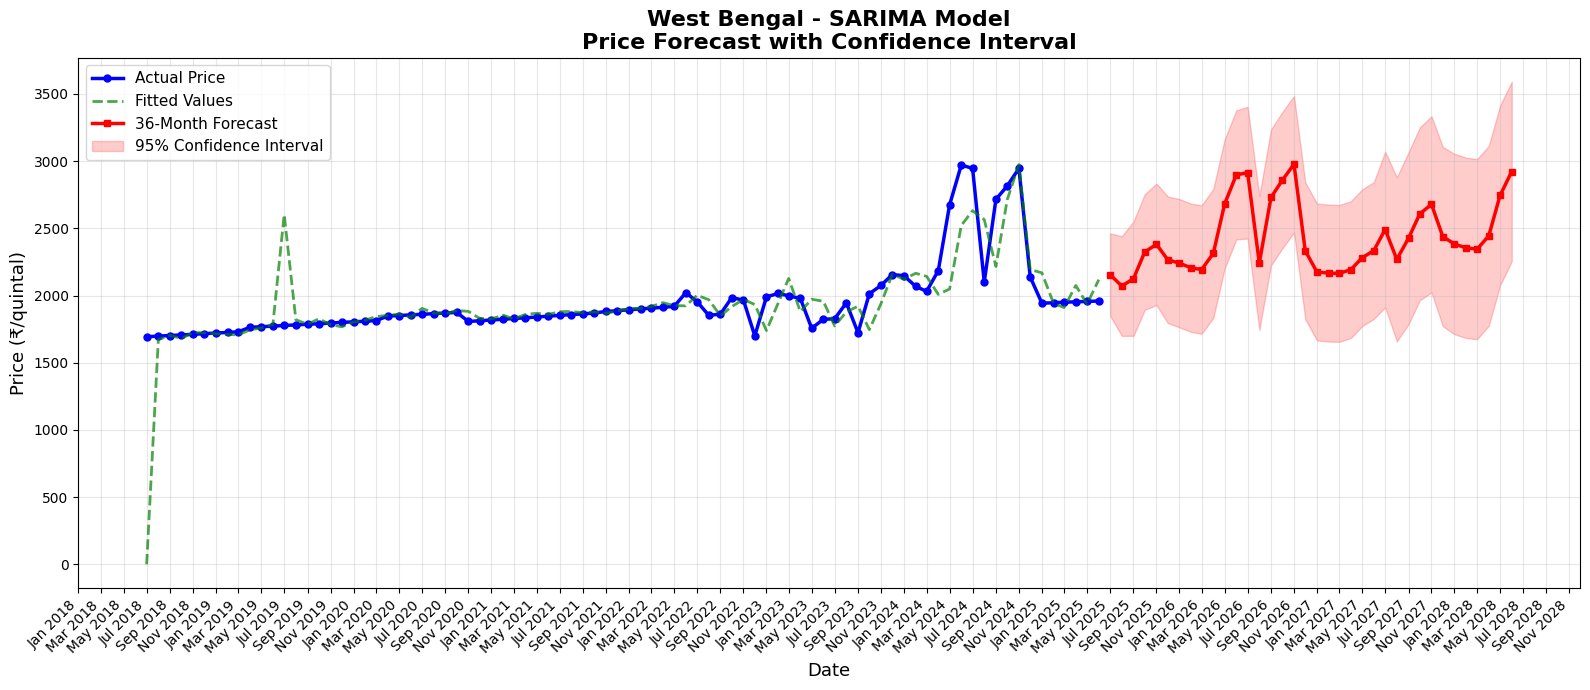


********************************************************************************
* SARIMAX MODEL FOR West Bengal
********************************************************************************

West Bengal - SARIMAX Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      2033.38
            2 Aug 2025                      1787.89
            3 Sep 2025                      2024.40
            4 Oct 2025                      2254.71
            5 Nov 2025                      2385.66
            6 Dec 2025                      2113.78
            7 Jan 2026                      2044.85
            8 Feb 2026                      2007.74
            9 Mar 2026                      1992.58
           10 Apr 2026                      2087.10
           11 May 2026                      2381.29
           12 Jun 2026                      2559.93
           13 Jul 2026                      2575.76
           14 Aug 2026

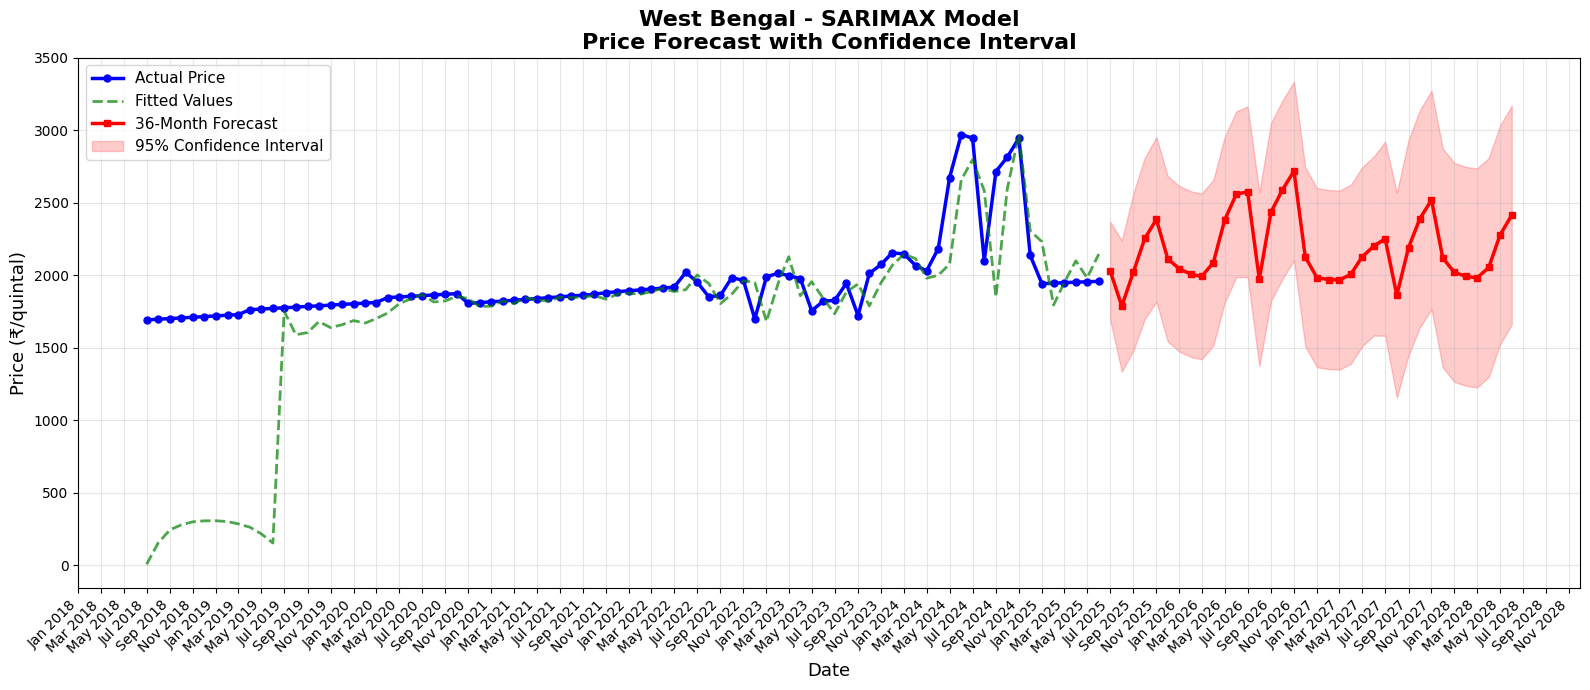



################################################################################
# GENERATING FORECASTS FOR TAMIL NADU
################################################################################


********************************************************************************
* ARIMA MODEL FOR Tamil Nadu
********************************************************************************

Tamil Nadu - ARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1867.66
            2 Aug 2025                      1897.18
            3 Sep 2025                      1962.66
            4 Oct 2025                      2091.50
            5 Nov 2025                      2114.10
            6 Dec 2025                      1951.78
            7 Jan 2026                      1884.06
            8 Feb 2026                      2074.47
            9 Mar 2026                      2024.04
           10 Apr 2026           

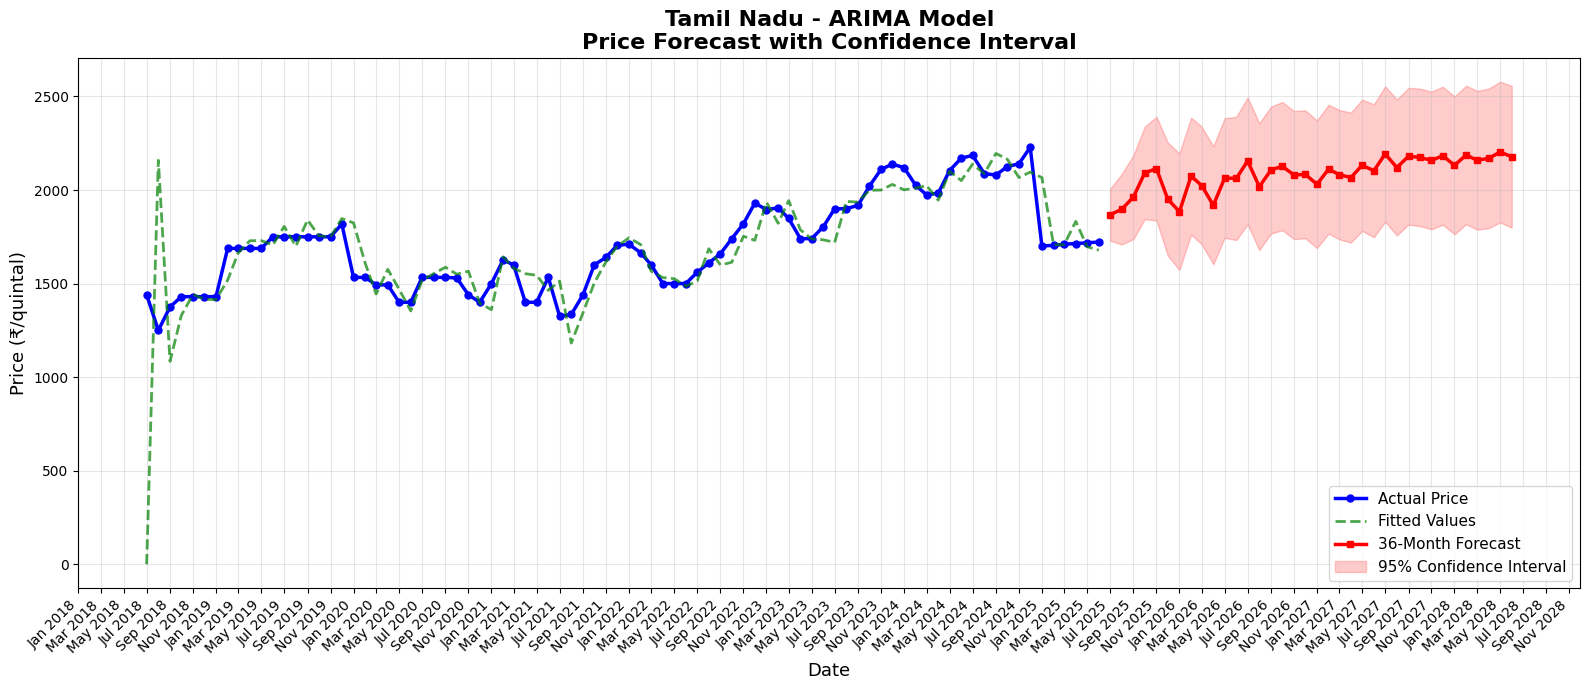


********************************************************************************
* SARIMA MODEL FOR Tamil Nadu
********************************************************************************

Tamil Nadu - SARIMA Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1806.78
            2 Aug 2025                      1772.71
            3 Sep 2025                      1815.49
            4 Oct 2025                      1903.80
            5 Nov 2025                      1954.72
            6 Dec 2025                      2072.93
            7 Jan 2026                      1571.17
            8 Feb 2026                      1595.32
            9 Mar 2026                      1619.01
           10 Apr 2026                      1637.83
           11 May 2026                      1654.23
           12 Jun 2026                      1668.62
           13 Jul 2026                      1762.09
           14 Aug 2026    

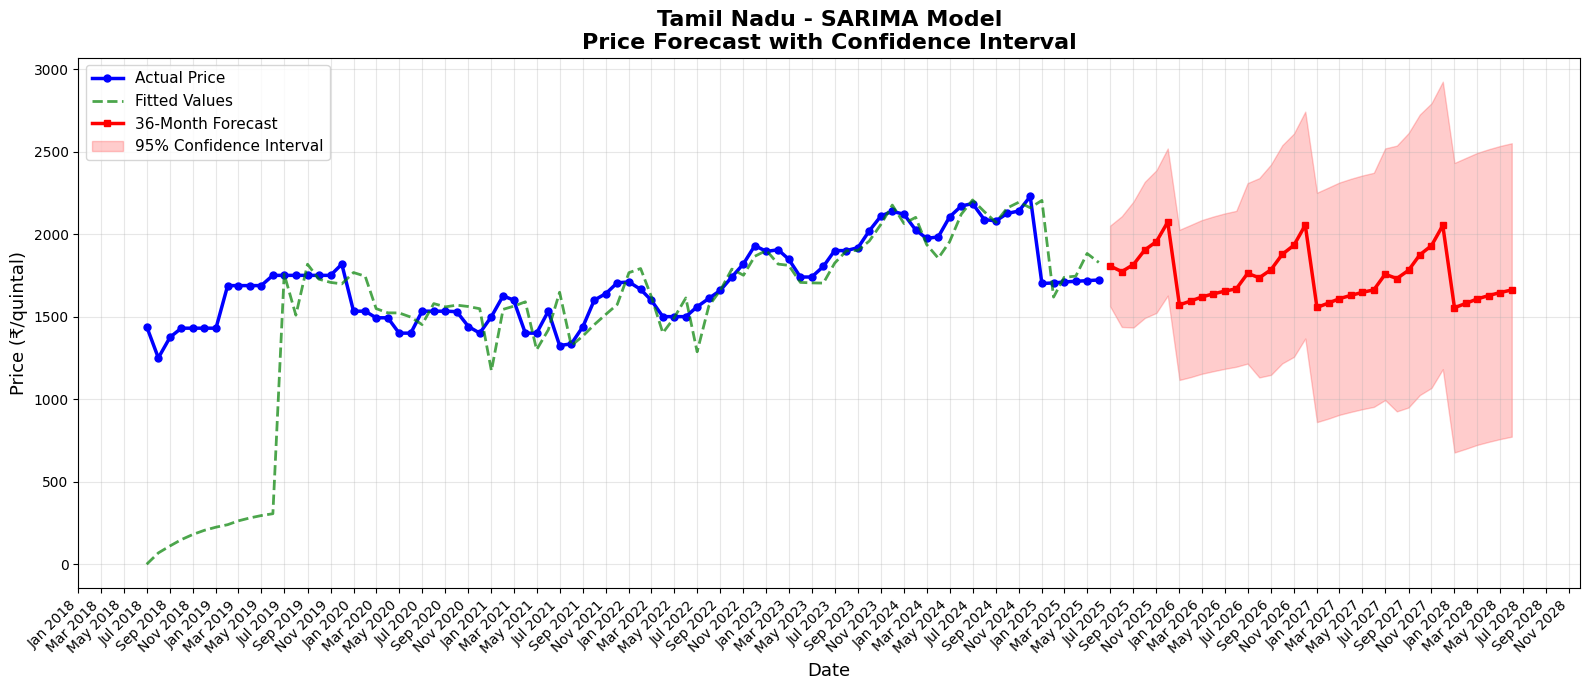


********************************************************************************
* SARIMAX MODEL FOR Tamil Nadu
********************************************************************************

Tamil Nadu - SARIMAX Model: 36-Month Price Forecasts
 Month_Number    Month  Predicted Price (₹/quintal)
            1 Jul 2025                      1875.00
            2 Aug 2025                      1893.41
            3 Sep 2025                      1886.63
            4 Oct 2025                      1882.07
            5 Nov 2025                      1868.36
            6 Dec 2025                      1912.52
            7 Jan 2026                      1656.59
            8 Feb 2026                      1678.91
            9 Mar 2026                      1694.02
           10 Apr 2026                      1676.11
           11 May 2026                      1649.75
           12 Jun 2026                      1649.68
           13 Jul 2026                      1725.44
           14 Aug 2026  

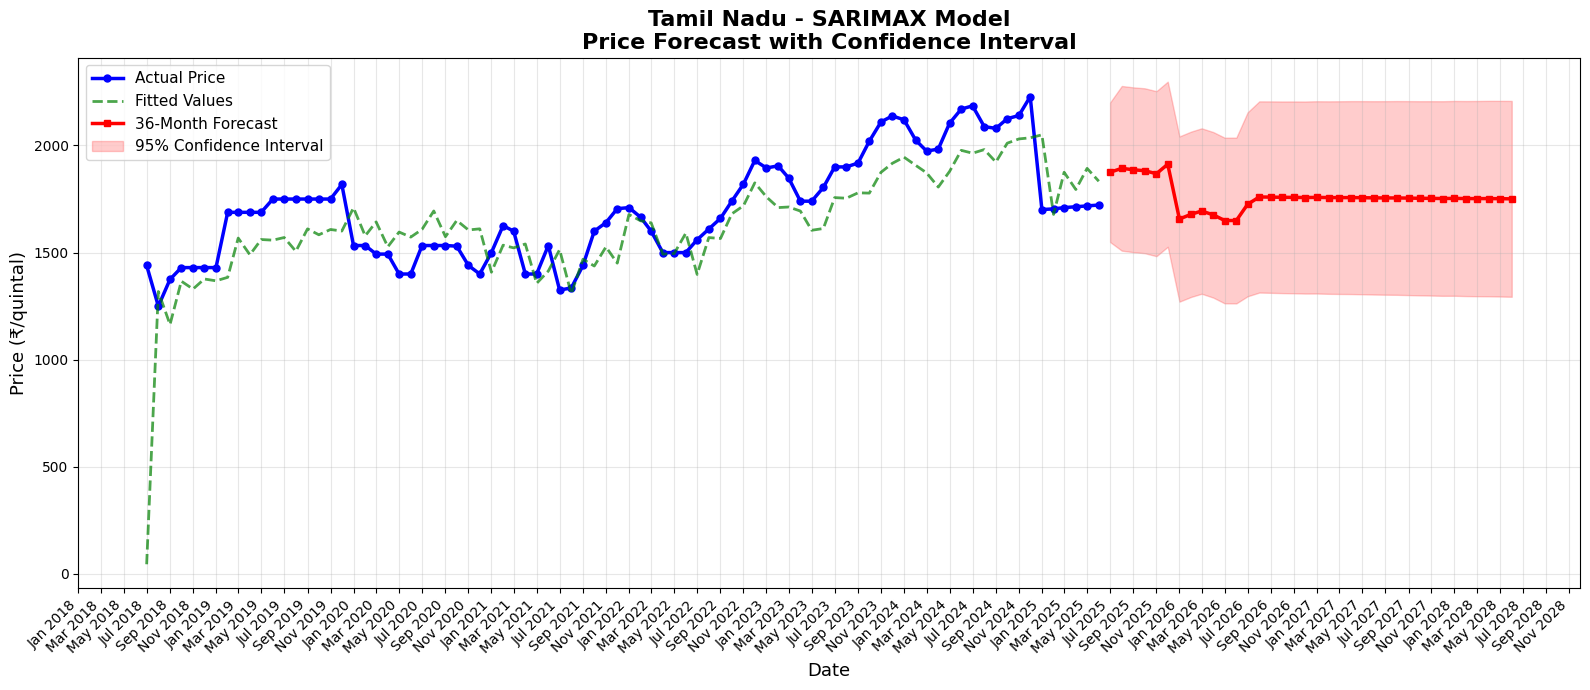



################################################################################
# ALL VISUALIZATIONS AND FORECASTS GENERATED SUCCESSFULLY!
################################################################################



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator, DateFormatter
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('/content/paddy_price_production.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%Y')
df = df.sort_values('Date').reset_index(drop=True)

# Store the best model parameters from previous grid search
best_params = {
    'Punjab': {'ARIMA': (1,1,4), 'SARIMA': (1, 2, 4, 1, 1, 2), 'SARIMAX': (0, 0, 3, 1, 0, 0)},
    'Utar Pradesh': {'ARIMA': (2, 1, 2), 'SARIMA': (0, 2, 5, 0, 1, 0), 'SARIMAX': None},
    'Delhi': {'ARIMA': (8, 1, 4), 'SARIMA': (3, 0, 0, 1, 0, 0), 'SARIMAX': (1, 1, 0, 1, 0, 1)},
    'West Bengal': {'ARIMA': (14, 2, 13), 'SARIMA': (2, 1, 5, 2, 1, 1), 'SARIMAX': (2, 0, 2, 1, 1, 0)}, # Updated SARIMAX params
    'Tamil Nadu': {'ARIMA': (9, 2, 15), 'SARIMA': (2, 0, 1, 0, 1, 0), 'SARIMAX': (1, 0, 2, 1, 0, 2)}
}

states = df['State'].unique()

def plot_forecast_with_confidence(state, model_type, best_param, price_series, production_series=None, exog_forecast=None):
    """
    Create a comprehensive forecast plot with actual, fitted, forecast, and confidence intervals
    """

    # Train model on full data
    model_fit = None  # Initialize model_fit to None
    try:
        if model_type == 'ARIMA':
            model = ARIMA(price_series, order=best_param)
            model_fit = model.fit()

        elif model_type == 'SARIMA':
            model = SARIMAX(price_series, order=best_param[:3], seasonal_order=best_param[3:] + (12,))
            model_fit = model.fit(disp=False)

        elif model_type == 'SARIMAX' and best_param is not None:
            if production_series is None or exog_forecast is None:
                return None, None, None, None  # Skip if no exog data

            model = SARIMAX(price_series, order=best_param[:3], seasonal_order=best_param[3:] + (12,), exog=production_series)
            model_fit = model.fit(disp=False)
        else:
            return None, None, None, None # Invalid model type

    except np.linalg.LinAlgError:
        print(f"  Skipping {state} - {model_type} with params {best_param} due to LinAlgError during fitting.")
        return None, None, None, None # Return None if fitting fails

    if model_fit is not None:
        # Get fitted values
        fitted_values = model_fit.fittedvalues

        # Forecast 36 months with confidence interval
        forecast_result = model_fit.get_forecast(steps=36, exog=exog_forecast if model_type == 'SARIMAX' else None)
        forecast_mean = forecast_result.predicted_mean
        forecast_ci = forecast_result.conf_int()

        # figure
        fig, ax = plt.subplots(figsize=(16, 7))
        ax.plot(price_series.index, price_series.values, 'b-', linewidth=2.5, label='Actual Price', marker='o', markersize=5)
        ax.plot(fitted_values.index, fitted_values.values, 'g--', linewidth=2, alpha=0.7, label='Fitted Values')
        last_date = price_series.index[-1]
        future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=36, freq='MS')
        ax.plot(future_dates, forecast_mean.values, 'r-', linewidth=2.5, label='36-Month Forecast', marker='s', markersize=5)
        ax.fill_between(future_dates,
                     forecast_ci.iloc[:, 0].values,
                     forecast_ci.iloc[:, 1].values,
                     color='red', alpha=0.2, label='95% Confidence Interval')
        ax.xaxis.set_major_locator(MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))

        # Formatting
        ax.set_title(f'{state} - {model_type} Model\nPrice Forecast with Confidence Interval', fontsize=16, fontweight='bold')
        ax.set_xlabel('Date', fontsize=13)
        ax.set_ylabel('Price (₹/quintal)', fontsize=13)
        ax.legend(loc='best', fontsize=11)
        ax.grid(True, alpha=0.3)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()

        return fig, model_fit, forecast_mean, forecast_ci, future_dates

    return None, None, None, None


def display_predictions_table(forecast_mean, future_dates, state, model_type):
    """
    Display predictions in a formatted table
    """
    print(f"\n{'='*80}")
    print(f"{state} - {model_type} Model: 36-Month Price Forecasts")
    print(f"{'='*80}")


    forecast_df = pd.DataFrame({
        'Month': future_dates.strftime('%b %Y'),
        'Predicted Price (₹/quintal)': forecast_mean.values.round(2)
    })
    forecast_df['Month_Number'] = range(1, 37)
    forecast_df = forecast_df[['Month_Number', 'Month', 'Predicted Price (₹/quintal)']]
    print(forecast_df.to_string(index=False))
    print(f"{'='*80}\n")
    return forecast_df

# Generate plots and predictions for all states and models
plot_results = {}

for state in states:
    print(f"\n\n{'#'*80}")
    print(f"# GENERATING FORECASTS FOR {state.upper()}")
    print(f"{'#'*80}\n")

    state_df = df[df['State'] == state].sort_values('Date').copy()
    state_df.set_index('Date', inplace=True)
    price_series = state_df['Prices'].dropna()
    price_series.index.freq = 'MS'
    production_series = state_df['Production'].dropna()
    production_series.index.freq = 'MS'

    state_plots = {}
    state_forecasts = {}

    #  ARIMA
    print(f"\n{'*'*80}")
    print(f"* ARIMA MODEL FOR {state}")
    print(f"{'*'*80}")

    arima_param = best_params[state]['ARIMA']
    result = plot_forecast_with_confidence(
        state, 'ARIMA', arima_param, price_series
    )
    if result[0] is not None:
        fig_arima, model_arima, forecast_arima, ci_arima, future_dates_arima = result

        # Display predictions table
        forecast_df_arima = display_predictions_table(forecast_arima, future_dates_arima, state, 'ARIMA')

        # Display graph
        plt.show()

        state_plots['ARIMA'] = {
            'figure': fig_arima,
            'model': model_arima,
            'forecast': forecast_arima,
            'ci': ci_arima
        }
        state_forecasts['ARIMA'] = forecast_df_arima

    # SARIMA
    print(f"\n{'*'*80}")
    print(f"* SARIMA MODEL FOR {state}")
    print(f"{'*'*80}")

    sarima_param = best_params[state]['SARIMA']
    result = plot_forecast_with_confidence(
        state, 'SARIMA', sarima_param, price_series
    )
    if result[0] is not None:
        fig_sarima, model_sarima, forecast_sarima, ci_sarima, future_dates_sarima = result

        # Display predictions table
        forecast_df_sarima = display_predictions_table(forecast_sarima, future_dates_sarima, state, 'SARIMA')

        # Display graph
        plt.show()

        state_plots['SARIMA'] = {
            'figure': fig_sarima,
            'model': model_sarima,
            'forecast': forecast_sarima,
            'ci': ci_sarima
        }
        state_forecasts['SARIMA'] = forecast_df_sarima

    #  SARIMAX
    sarimax_param = best_params[state]['SARIMAX']
    if sarimax_param is not None:
        print(f"\n{'*'*80}")
        print(f"* SARIMAX MODEL FOR {state}")
        print(f"{'*'*80}")

        if len(production_series) == len(price_series):
            exog_forecast = np.array([[production_series.values[-1]]] * 36)
            result = plot_forecast_with_confidence(
                state, 'SARIMAX', sarimax_param, price_series,
                production_series=production_series,
                exog_forecast=exog_forecast
            )
            if result[0] is not None:
                fig_sarimax, model_sarimax, forecast_sarimax, ci_sarimax, future_dates_sarimax = result

                # Display predictions table
                forecast_df_sarimax = display_predictions_table(forecast_sarimax, future_dates_sarimax, state, 'SARIMAX')

                # Display graph
                plt.show()

                state_plots['SARIMAX'] = {
                    'figure': fig_sarimax,
                    'model': model_sarimax,
                    'forecast': forecast_sarimax,
                    'ci': ci_sarimax
                }
                state_forecasts['SARIMAX'] = forecast_df_sarimax
            else:
                print(f"  Skipping {state} - SARIMAX with params {sarimax_param} due to error during fitting or missing data.")
    else:
        print(f"\n{'*'*80}")
        print(f"* SARIMAX MODEL FOR {state} - SKIPPED")
        print(f"* Reason: No production data available for this state")
        print(f"{'*'*80}")

    plot_results[state] = {
        'plots': state_plots,
        'forecasts': state_forecasts
    }

print(f"\n\n{'#'*80}")
print(f"# ALL VISUALIZATIONS AND FORECASTS GENERATED SUCCESSFULLY!")
print(f"{'#'*80}\n")